In [14]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))














    
    print("GPU Count:", torch.cuda.device_count())

CUDA Available: True
GPU Name: NVIDIA RTX 4500 Ada Generation
GPU Count: 1


In [15]:
# === VERIFICATION CELL (run this first) ===
import sys
print(f"Python: {sys.version}")

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

import numpy, pandas, sklearn, mne
from tqdm.auto import tqdm
from torch.amp import autocast, GradScaler

print("\n✅ All packages ready!")

Python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:09:02) [GCC 11.2.0]
PyTorch: 2.9.1+cu128
CUDA available: True
GPU: NVIDIA RTX 4500 Ada Generation
VRAM: 25.2 GB

✅ All packages ready!


In [16]:
# ============================================================
# CELL 1: SETUP, IMPORTS, CONFIGURATION
# ============================================================
# Edit RAW_DATA_DIR below if your data is not at ~/Desktop/CHB/

# Install required packages (run once, then comment out)MMCD
# !pip install torch numpy scipy scikit-learn pandas matplotlib mne tqdm

import os
import sys
import json
import time
import random
import csv
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.amp import autocast, GradScaler

import mne
from sklearn.metrics import roc_auc_score
from scipy import stats
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')

# ============================================================
# PATHS — EDIT IF NEEDED
# ============================================================
HOME = str(Path.home())
RAW_DATA_DIR = os.path.join(HOME, 'Desktop', 'CHB')
CACHE_DIR    = os.path.join(HOME, 'Desktop', 'CHB', 'preprocessed')
RESULTS_DIR  = os.path.join(HOME, 'Desktop', 'CHB', 'results')
MODELS_DIR   = os.path.join(HOME, 'Desktop', 'CHB', 'models')

# Create directories if missing
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(os.path.join(MODELS_DIR, 'checkpoints'), exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, 'logs'), exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, 'figures'), exist_ok=True)


# ============================================================
# DATASET CONSTANTS (CHB-MIT specific)
# ============================================================
SAMPLING_RATE  = 256
WINDOW_SECONDS = 15
WINDOW_SIZE    = SAMPLING_RATE * WINDOW_SECONDS  # 3840
N_CHANNELS     = 18  # <-- CHANGED from 22 to 18

STANDARD_CHANNELS = [
    'FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1',
    'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
    'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
    'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
    'FZ-CZ', 'CZ-PZ',
]

# ============================================================
# SEIZURE TIMING (paper protocol)
# ============================================================
PREICTAL_MINUTES         = 30
SPH_MINUTES              = 5
SIH_HOURS                = 4
LEADING_SEIZURE_GAP_MIN  = 15

# Patient-specific SIH overrides for high-frequency seizure cases
PATIENT_SIH_OVERRIDE = {
    'chb13': 1,   # Reduce from 4h to 1h to get interictal data
    'chb15': 1,   # Same for chb15
}

# ============================================================
# DATA BALANCE
# ============================================================
INTERICTAL_RATIO                  = 3
PREICTAL_OVERSAMPLE_STEP_DIVISOR  = 2   # CORRECTED: was 4 (75% overlap), now 2 (50% overlap)

# ============================================================
# TRAINING (RTX 4500 — 20GB VRAM)
# ============================================================
BATCH_SIZE               = 128
NUM_WORKERS              = 4
PIN_MEMORY               = True
EPOCHS                   = 60
LEARNING_RATE            = 0.002
WEIGHT_DECAY             = 0.01
ADAM_BETAS               = (0.9, 0.999)
EARLY_STOPPING_PATIENCE  = 15
SEED                     = 42
USE_AMP                  = True
ENABLE_TF32              = True

# ============================================================
# MODEL ARCHITECTURE
# ============================================================
DROPOUT_RATE = 0.1
NUM_CLASSES  = 2

# ============================================================
# INFERENCE METHODS
# ============================================================
MCD_T            = 5
MMCD_D           = 2
CT_WMMCD_TAU     = 0.5    # confidence temperature
CT_WMMCD_LAMBDA  = 0.3    # temporal recency weight

# ============================================================
# POSTPROCESSING
# ============================================================
KOFN_K_SECONDS      = 120
KOFN_N_SECONDS      = 150
REFRACTORY_MINUTES  = 30

# ============================================================
# THRESHOLD CALIBRATION (NEW)
# ============================================================
THRESHOLD_PERCENTILE = 95.0   # Calibrate on 99th pctl of train interictal

# ============================================================
# PATIENT SELECTION
# ============================================================
USE_PAPER_SUBSET = True # CORRECTED: match paper's 18-patient setup for fair comparison
PAPER_EXCLUDED   = ['chb04', 'chb06', 'chb07', 'chb15', 'chb12']
ALL_PATIENTS     = [f'chb{i:02d}' for i in range(1, 25)]

if USE_PAPER_SUBSET:
    EXCLUDED_PATIENTS = list(PAPER_EXCLUDED)
    VALID_PATIENTS    = [p for p in ALL_PATIENTS if p not in EXCLUDED_PATIENTS]
else:
    EXCLUDED_PATIENTS = []
    VALID_PATIENTS    = list(ALL_PATIENTS)

# ============================================================
# DEVICE
# ============================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if ENABLE_TF32 and torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ============================================================
# PRINT CONFIG SUMMARY
# ============================================================
print("=" * 70)
print("CONFIGURATION SUMMARY")
print("=" * 70)
print(f"Raw data dir : {RAW_DATA_DIR}")
print(f"Cache dir    : {CACHE_DIR}")
print(f"Results dir  : {RESULTS_DIR}")
print(f"Models dir   : {MODELS_DIR}")
print(f"Device       : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM         : {vram_gb:.1f} GB")
print(f"Window       : {WINDOW_SECONDS}s ({WINDOW_SIZE} samples) x {N_CHANNELS} channels")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Mixed prec.  : {USE_AMP}")
print(f"TF32         : {ENABLE_TF32}")
print(f"Patients     : {len(VALID_PATIENTS)} ({'paper subset' if USE_PAPER_SUBSET else 'all 24'})")
print(f"  -> {VALID_PATIENTS}")
print("=" * 70)


CONFIGURATION SUMMARY
Raw data dir : /home/dst/Desktop/CHB
Cache dir    : /home/dst/Desktop/CHB/preprocessed
Results dir  : /home/dst/Desktop/CHB/results
Models dir   : /home/dst/Desktop/CHB/models
Device       : cuda
GPU          : NVIDIA RTX 4500 Ada Generation
VRAM         : 25.2 GB
Window       : 15s (3840 samples) x 18 channels
Batch size   : 128
Mixed prec.  : True
TF32         : True
Patients     : 19 (paper subset)
  -> ['chb01', 'chb02', 'chb03', 'chb05', 'chb08', 'chb09', 'chb10', 'chb11', 'chb13', 'chb14', 'chb16', 'chb17', 'chb18', 'chb19', 'chb20', 'chb21', 'chb22', 'chb23', 'chb24']


In [17]:
# ============================================================
# CELL 2: HELPER FUNCTIONS (channel matching, EDF loading, segmentation)
# ============================================================

import os
import json
import numpy as np
import mne


mne.set_log_level('ERROR')


# ============================================================
# CHANNEL MATCHING (robust)
# ============================================================

def _normalize(ch_name):
    """Normalize a channel name for comparison: uppercase, strip spaces/dashes."""
    return ch_name.upper().replace(' ', '').replace('-', '')


def _build_channel_lookup(available_channels):
    """
    Build normalized-name -> actual-channel-name lookup with fallback strategies.

    Handles:
      1. Exact normalized match    : 'T8-P8' -> 'T8-P8'
      2. '-0'/'-1' suffix stripping : 'T8-P8' <- 'T8-P8-0' (CHB-MIT quirk)
      3. Any trailing '-<digit>'    : 'CHAN'  <- 'CHAN-2'

    Priority: exact > '-0' suffix > '-1' suffix > other suffixes.
    """
    lookup = {}

    for ch in available_channels:
        norm = _normalize(ch)
        if norm not in lookup:
            lookup[norm] = ch

        # Strategy 2: '-0' or '-1' suffix
        if ch.endswith('-0') or ch.endswith('-1'):
            base = ch[:-2]
            base_norm = _normalize(base)
            if base_norm not in lookup:
                lookup[base_norm] = ch

        # Strategy 3: any trailing '-<digit(s)>'
        parts = ch.rsplit('-', 1)
        if len(parts) == 2 and parts[1].isdigit():
            base_norm = _normalize(parts[0])
            if base_norm not in lookup:
                lookup[base_norm] = ch

    return lookup


def find_patient_dir(raw_data_dir, patient_id):
    """
    Locate a patient's directory, handling naming variations.

    Tries (in order): chbXX, chbX, ChbXX, CHBXX
    Returns absolute path or None if not found.
    """
    candidates = [
        patient_id,                           # chb04
        patient_id.replace('chb0', 'chb'),    # chb4
        patient_id.upper(),                   # CHB04
        patient_id.capitalize(),              # Chb04
    ]
    for cand in candidates:
        full = os.path.join(raw_data_dir, cand)
        if os.path.isdir(full):
            return full

    # Last resort: case-insensitive directory listing
    try:
        for entry in os.listdir(raw_data_dir):
            if entry.lower() == patient_id.lower():
                full = os.path.join(raw_data_dir, entry)
                if os.path.isdir(full):
                    return full
            # Match chb4 ↔ chb04
            entry_normalized = entry.lower().replace('chb0', 'chb')
            target_normalized = patient_id.lower().replace('chb0', 'chb')
            if entry_normalized == target_normalized:
                full = os.path.join(raw_data_dir, entry)
                if os.path.isdir(full):
                    return full
    except FileNotFoundError:
        pass

    return None


def find_summary_file(patient_dir, patient_id):
    """
    Find the summary file (e.g. chb01-summary.txt). Handles naming variations.
    """
    candidates = [
        f'{patient_id}-summary.txt',
        f'{patient_id.replace("chb0", "chb")}-summary.txt',  # chb4-summary.txt
        f'{patient_id.upper()}-summary.txt',
    ]
    for cand in candidates:
        full = os.path.join(patient_dir, cand)
        if os.path.isfile(full):
            return full

    # Last resort: any file ending in '-summary.txt'
    try:
        for entry in os.listdir(patient_dir):
            if entry.lower().endswith('-summary.txt'):
                return os.path.join(patient_dir, entry)
    except FileNotFoundError:
        pass

    return None


# ============================================================
# EDF LOADING
# ============================================================

def load_edf_signal(edf_path, target_channels=None, verbose_fail=False):
    """
    Load an EDF file and return (signal, sfreq) where signal has shape
    (n_target_channels, n_samples) as float32. Returns (None, None) if
    required channels are missing.
    """
    if target_channels is None:
        target_channels = STANDARD_CHANNELS
        
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose='ERROR')
    except Exception as e:
        if verbose_fail:
            print(f"      [EDF load error] {os.path.basename(edf_path)}: {e}")
        return None, None

    lookup = _build_channel_lookup(raw.ch_names)

    selected = []
    missing = []
    for target in target_channels:
        target_norm = _normalize(target)
        actual = lookup.get(target_norm, None)
        if actual is None:
            missing.append(target)
        else:
            selected.append(actual)

    if missing:
        if verbose_fail:
            print(f"      [Channel mismatch] {os.path.basename(edf_path)}: "
                  f"missing {missing} | available: {raw.ch_names}")
        return None, None

    raw.pick(selected)

    if int(raw.info['sfreq']) != SAMPLING_RATE:
        raw.resample(SAMPLING_RATE, verbose='ERROR')

    signal = raw.get_data().astype(np.float32)
    return signal, raw.info['sfreq']


# ============================================================
# SUMMARY FILE PARSER
# ============================================================

def parse_summary_file(summary_path):
    """
    Parse CHB-MIT summary text file.
    Returns: dict mapping edf_filename -> list of (start_sec, end_sec) tuples.
    """
    seizure_info = {}
    if summary_path is None or not os.path.exists(summary_path):
        return seizure_info

    with open(summary_path, 'r') as f:
        lines = f.readlines()

    current_file = None
    current_seizures = []
    pending_start = None

    for line in lines:
        line = line.strip()
        if line.startswith('File Name:'):
            if current_file is not None:
                seizure_info[current_file] = current_seizures
            current_file = line.split(':', 1)[1].strip()
            current_seizures = []
            pending_start = None
        elif 'Seizure' in line and 'Start Time' in line:
            try:
                pending_start = int(line.split(':', 1)[1].strip().split()[0])
            except (ValueError, IndexError):
                pending_start = None
        elif 'Seizure' in line and 'End Time' in line:
            try:
                end_sec = int(line.split(':', 1)[1].strip().split()[0])
                if pending_start is not None:
                    current_seizures.append((pending_start, end_sec))
                    pending_start = None
            except (ValueError, IndexError):
                pending_start = None

    if current_file is not None:
        seizure_info[current_file] = current_seizures

    return seizure_info


# ============================================================
# SEIZURE FILTERING (leading seizure rule)
# ============================================================

def merge_leading_seizures_global(all_seizures_global, gap_minutes=None):
    """
    Given list of (file_idx, global_start_sec, global_end_sec), keep only
    leading seizures (drop those <gap_minutes after the previous one).
    """
    if gap_minutes is None:
        gap_minutes = LEADING_SEIZURE_GAP_MIN
        
    if len(all_seizures_global) <= 1:
        return list(all_seizures_global)

    sorted_sz = sorted(all_seizures_global, key=lambda x: x[1])
    gap_sec = gap_minutes * 60
    leading = [sorted_sz[0]]
    for sz in sorted_sz[1:]:
        if sz[1] - leading[-1][2] >= gap_sec:
            leading.append(sz)
    return leading


# ============================================================
# SLIDING WINDOW
# ============================================================

def slide_windows(segment, window_size=None, step=None):
    """
    Slide windows across (n_channels, n_samples) segment.
    Returns array of shape (n_windows, n_channels, window_size).
    """
    if window_size is None:
        window_size = WINDOW_SIZE
    if step is None:
        step = window_size

    n_channels, n_samples = segment.shape
    if n_samples < window_size:
        return np.zeros((0, n_channels, window_size), dtype=np.float32)

    n_windows = (n_samples - window_size) // step + 1
    windows = np.zeros((n_windows, n_channels, window_size), dtype=np.float32)
    for i in range(n_windows):
        start = i * step
        windows[i] = segment[:, start:start + window_size]
    return windows


# ============================================================
# MAIN PREPROCESSING FUNCTION
# ============================================================

def preprocess_patient(patient_id):
    """
    Process one patient. Saves per-seizure preictal arrays + interictal
    segments separately. Skips processing if cache already exists.

    Output files in CACHE_DIR:
        {patient}_preictal.npz   -> dict 'seizure_0', 'seizure_1', ...
                                    each (n_windows, 22, 3840) float32
        {patient}_interictal.npz -> dict 'segment_0', 'segment_1', ...
        {patient}_meta.json      -> metadata with timing info
    """
    pre_path = os.path.join(CACHE_DIR, f'{patient_id}_preictal.npz')
    inter_path = os.path.join(CACHE_DIR, f'{patient_id}_interictal.npz')
    meta_path = os.path.join(CACHE_DIR, f'{patient_id}_meta.json')

    # Resume: skip if already cached successfully
    if all(os.path.exists(p) for p in [pre_path, inter_path, meta_path]):
        with open(meta_path, 'r') as f:
            meta = json.load(f)
        if meta.get('status') == 'ok':
            return meta

    patient_dir = find_patient_dir(RAW_DATA_DIR, patient_id)
    if patient_dir is None:
        return {'patient': patient_id, 'status': 'no_directory',
                'n_seizures_total': 0, 'n_seizures_usable': 0,
                'n_preictal_windows': 0, 'n_interictal_windows': 0,
                'interictal_hours': 0.0, 'seizures': []}

    summary_path = find_summary_file(patient_dir, patient_id)
    seizure_info = parse_summary_file(summary_path)

    edf_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('.edf')])

    full_signals = []
    seizures_global = []
    cum_offset = 0.0
    n_failed_files = 0

    for file_idx, edf_file in enumerate(edf_files):
        edf_path = os.path.join(patient_dir, edf_file)
        signal, sfreq = load_edf_signal(edf_path, verbose_fail=False)
        if signal is None:
            n_failed_files += 1
            continue

        duration_sec = signal.shape[1] / sfreq
        full_signals.append(signal)

        for s_start, s_end in seizure_info.get(edf_file, []):
            seizures_global.append((file_idx, cum_offset + s_start,
                                     cum_offset + s_end))
        cum_offset += duration_sec

    if not full_signals:
        status = 'no_loadable_files' if n_failed_files > 0 else 'no_edf_files'
        return {'patient': patient_id, 'status': status,
                'n_seizures_total': 0, 'n_seizures_usable': 0,
                'n_preictal_windows': 0, 'n_interictal_windows': 0,
                'interictal_hours': 0.0, 'seizures': []}

    seizures_global = merge_leading_seizures_global(seizures_global)

    if not seizures_global:
        return {'patient': patient_id, 'status': 'no_seizures',
                'n_seizures_total': 0, 'n_seizures_usable': 0,
                'n_preictal_windows': 0, 'n_interictal_windows': 0,
                'interictal_hours': 0.0, 'seizures': []}

    full_signal = np.concatenate(full_signals, axis=1)
    total_samples = full_signal.shape[1]
    total_duration_sec = total_samples / SAMPLING_RATE

    preictal_sec = PREICTAL_MINUTES * 60
    sph_sec = SPH_MINUTES * 60
    sih_hours = PATIENT_SIH_OVERRIDE.get(patient_id, SIH_HOURS)
    sih_sec = sih_hours * 3600

    # Extract preictal per seizure
    preictal_per_seizure = {}
    sz_meta = []
    oversample_step = max(1, WINDOW_SIZE // PREICTAL_OVERSAMPLE_STEP_DIVISOR)

    for sz_idx, (_, sz_start, sz_end) in enumerate(seizures_global):
        preictal_end = sz_start - sph_sec
        preictal_start = preictal_end - preictal_sec
        usable = False
        n_win = 0

        if preictal_start >= 0:
            s_samp = int(preictal_start * SAMPLING_RATE)
            e_samp = int(preictal_end * SAMPLING_RATE)
            if 0 <= s_samp < e_samp <= total_samples:
                seg = full_signal[:, s_samp:e_samp]
                windows = slide_windows(seg, WINDOW_SIZE, step=oversample_step)
                if windows.shape[0] > 0:
                    preictal_per_seizure[f'seizure_{sz_idx}'] = windows
                    usable = True
                    n_win = int(windows.shape[0])

        sz_meta.append({
            'seizure_idx': sz_idx,
            'global_start_sec': float(sz_start),
            'global_end_sec': float(sz_end),
            'usable_preictal': usable,
            'n_preictal_windows': n_win,
        })

    # Interictal extraction (everything outside [seizure ± SIH])
    excluded = [(max(0.0, s - sih_sec), e + sih_sec)
                 for _, s, e in seizures_global]
    excluded.sort()
    merged_excl = [excluded[0]]
    for s, e in excluded[1:]:
        if s <= merged_excl[-1][1]:
            merged_excl[-1] = (merged_excl[-1][0], max(merged_excl[-1][1], e))
        else:
            merged_excl.append((s, e))

    interictal_intervals = []
    prev_end = 0.0
    for s, e in merged_excl:
        if s > prev_end:
            interictal_intervals.append((prev_end, s))
        prev_end = e
    if prev_end < total_duration_sec:
        interictal_intervals.append((prev_end, total_duration_sec))

    interictal_segments = {}
    seg_idx = 0
    for inter_start, inter_end in interictal_intervals:
        s_samp = int(inter_start * SAMPLING_RATE)
        e_samp = min(int(inter_end * SAMPLING_RATE), total_samples)
        if e_samp - s_samp < WINDOW_SIZE:
            continue
        seg = full_signal[:, s_samp:e_samp]
        windows = slide_windows(seg, WINDOW_SIZE, step=WINDOW_SIZE)
        if windows.shape[0] > 0:
            interictal_segments[f'segment_{seg_idx}'] = windows
            seg_idx += 1

    del full_signal, full_signals

    # Save (compressed .npz to keep cache small)
    np.savez_compressed(pre_path, **preictal_per_seizure)
    np.savez_compressed(inter_path, **interictal_segments)

    n_preictal_total = sum(a.shape[0] for a in preictal_per_seizure.values())
    n_interictal_total = sum(a.shape[0] for a in interictal_segments.values())
    n_seizures_usable = sum(1 for m in sz_meta if m['usable_preictal'])
    interictal_hours = n_interictal_total * WINDOW_SECONDS / 3600.0

    meta = {
        'patient': patient_id,
        'status': 'ok',
        'n_seizures_total': len(seizures_global),
        'n_seizures_usable': n_seizures_usable,
        'n_preictal_windows': int(n_preictal_total),
        'n_interictal_windows': int(n_interictal_total),
        'interictal_hours': float(interictal_hours),
        'seizures': sz_meta,
        'n_interictal_segments': len(interictal_segments),
        'shape_per_window': [N_CHANNELS, WINDOW_SIZE],
    }
    with open(meta_path, 'w') as f:
        json.dump(meta, f, indent=2)

    return meta


# ============================================================
# DATA LOADING (used by training/evaluation)
# ============================================================

def load_patient_data(patient_id):
    """
    Load preictal (per seizure) and interictal segments for a patient.

    Returns:
        preictal_dict: {seizure_key: array (n_win, 22, 3840)}
        interictal_dict: {segment_key: array (n_win, 22, 3840)}
        meta: dict from JSON
    """
    pre_path = os.path.join(CACHE_DIR, f'{patient_id}_preictal.npz')
    inter_path = os.path.join(CACHE_DIR, f'{patient_id}_interictal.npz')
    meta_path = os.path.join(CACHE_DIR, f'{patient_id}_meta.json')

    pre_npz = np.load(pre_path, allow_pickle=False)
    inter_npz = np.load(inter_path, allow_pickle=False)
    with open(meta_path, 'r') as f:
        meta = json.load(f)

    preictal_dict = {k: pre_npz[k] for k in pre_npz.files}
    interictal_dict = {k: inter_npz[k] for k in inter_npz.files}
    return preictal_dict, interictal_dict, meta

In [18]:
# ============================================================
# CELL 3: REPNET ARCHITECTURE
# ============================================================

import torch
import torch.nn as nn



class ReparamBlock(nn.Module):
    """Parallel 3x3 and 5x5 depthwise convolutions with identity skip.

    During training: both branches are active.
    For deployment: branches can be merged into a single 5x5 kernel via
    structural reparameterization (additivity of convolutions).
    """

    def __init__(self, channels):
        super().__init__()
        self.dwconv3 = nn.Conv2d(
            channels, channels,
            kernel_size=(3, 3), stride=(1, 1), padding=(1, 1),
            groups=channels, bias=False,
        )
        self.bn3 = nn.BatchNorm2d(channels)

        self.dwconv5 = nn.Conv2d(
            channels, channels,
            kernel_size=(5, 5), stride=(1, 1), padding=(2, 2),
            groups=channels, bias=False,
        )
        self.bn5 = nn.BatchNorm2d(channels)

    def forward(self, x):
        return x + self.bn3(self.dwconv3(x)) + self.bn5(self.dwconv5(x))


class DownsampleBlock(nn.Module):
    """ReLU -> 1x1 pointwise -> strided conv -> BN."""

    def __init__(self, in_channels, out_channels, stride=(2, 2),
                 kernel=(2, 2)):
        super().__init__()
        self.relu = nn.ReLU(inplace=True)
        self.pwconv = nn.Conv2d(in_channels, out_channels,
                                 kernel_size=(1, 1), bias=False)
        self.conv = nn.Conv2d(out_channels, out_channels,
                              kernel_size=kernel, stride=stride, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        return self.bn(self.conv(self.pwconv(self.relu(x))))


class RepNet(nn.Module):
    """
    Lightweight CNN for raw EEG seizure prediction.

    Input  : (batch, 1, n_samples, n_channels) — e.g. (B, 1, 3840, 18)
    Output : logits (batch, num_classes)
    """

    def __init__(self, n_channels=N_CHANNELS, n_samples=WINDOW_SIZE,
                 num_classes=NUM_CLASSES, dropout_rate=DROPOUT_RATE):
        super().__init__()

        # Asymmetric stem: large temporal kernel to extract initial features
        self.stem_conv = nn.Conv2d(
            1, 16,
            kernel_size=(21, 1), stride=(10, 1), padding=(0, 0),
            bias=False,
        )
        stem_out_h = (n_samples - 21) // 10 + 1   # 382 for 3840 input
        self.stem_ln = nn.LayerNorm([16, stem_out_h, n_channels])

        # Stage 1
        self.reparam1 = ReparamBlock(16)
        self.down1 = DownsampleBlock(16, 32, stride=(2, 2), kernel=(2, 2))

        # Stage 2
        self.reparam2 = ReparamBlock(32)
        self.down2 = DownsampleBlock(32, 64, stride=(2, 2), kernel=(2, 2))

        # Stage 3 — dropout placed before last conv (paper recommendation)
        self.reparam3 = ReparamBlock(64)
        self.down3_relu = nn.ReLU(inplace=True)
        self.down3_pw = nn.Conv2d(64, 64, kernel_size=(1, 1), bias=False)
        self.dropout = nn.Dropout2d(dropout_rate)
        # CHANGED: kernel from (7, 5) to (7, 4) to fit 18-channel input
        # With 18 channels: 18 -> 9 (down1) -> 4 (down2) -> 4 (here)
        # So max kernel width is 4
        self.down3_conv = nn.Conv2d(64, 64, kernel_size=(7, 4),
                                     stride=(2, 1), bias=False)
        self.down3_bn = nn.BatchNorm2d(64)

        # Classification head
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.stem_conv(x)
        x = self.stem_ln(x)
        x = self.down1(self.reparam1(x))
        x = self.down2(self.reparam2(x))
        x = self.reparam3(x)
        x = self.down3_relu(x)
        x = self.down3_pw(x)
        x = self.dropout(x)
        x = self.down3_conv(x)
        x = self.down3_bn(x)
        x = self.gap(x).flatten(1)
        return self.classifier(x)


def count_parameters(model):
    """Count trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def test_repnet():
    """Smoke test: build model, run forward pass, verify output shape."""
    print("Testing RepNet architecture...")
    model = RepNet()
    n_params = count_parameters(model)
    dummy = torch.randn(2, 1, WINDOW_SIZE, N_CHANNELS)
    with torch.no_grad():
        out = model(dummy)
    assert out.shape == (2, NUM_CLASSES), f"Expected (2,{NUM_CLASSES}), got {out.shape}"
    print(f"  Output shape : {tuple(out.shape)}")
    print(f"  Parameters   : {n_params:,} ({n_params * 4 / 1e6:.2f} MB)")
    print(f"  Input shape  : (batch, 1, {WINDOW_SIZE}, {N_CHANNELS})")
    print("  ✓ PASS")
    return True


if __name__ == '__main__':
    test_repnet()


# Run smoke test
test_repnet()

Testing RepNet architecture...
  Output shape : (2, 2)
  Parameters   : 366,898 (1.47 MB)
  Input shape  : (batch, 1, 3840, 18)
  ✓ PASS
Testing RepNet architecture...
  Output shape : (2, 2)
  Parameters   : 366,898 (1.47 MB)
  Input shape  : (batch, 1, 3840, 18)
  ✓ PASS


True

In [19]:
# ============================================================
# CELL 4: INFERENCE METHODS — CORRECTED
# ============================================================
# CORRECTIONS:
#   - MMCD, Weighted MMCD, CT-WMMCD now accept segment_boundaries
#   - They only average within contiguous temporal segments
#   - This fixes the broken MMCD that was INCREASING FPR instead of reducing it
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# METHOD 1: STANDARD (unchanged)
# ============================================================

@torch.no_grad()
def standard_inference(model, loader, device):
    """Vanilla deterministic forward pass."""
    model.eval()
    all_probs, all_labels = [], []
    for bx, by in loader:
        bx = bx.to(device, non_blocking=True)
        probs = F.softmax(model(bx), dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(by.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)


# ============================================================
# METHOD 2: MC DROPOUT (unchanged)
# ============================================================

@torch.no_grad()
def mc_dropout_inference(model, loader, device, T=5):
    """MC Dropout: T stochastic forward passes with dropout active."""
    model.eval()
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
            m.train()

    all_passes = []
    all_labels = None

    for t in range(T):
        probs_t, labels_t = [], []
        for bx, by in loader:
            bx = bx.to(device, non_blocking=True)
            p = F.softmax(model(bx), dim=1)
            probs_t.append(p.cpu().numpy())
            if t == 0:
                labels_t.append(by.numpy())
        all_passes.append(np.concatenate(probs_t))
        if t == 0:
            all_labels = np.concatenate(labels_t)

    avg_probs = np.mean(all_passes, axis=0)
    return avg_probs, all_labels


# ============================================================
# METHOD 3: MMCD — CORRECTED (segment-boundary-aware)
# ============================================================

def mmcd_inference(probs, D=2, segment_boundaries=None):
    """
    Paper's MMCD — CORRECTED to respect segment boundaries.

    Only averages within temporally contiguous segments.
    Without boundaries, falls back to treating entire array as one segment.

    Args:
        probs              : (n_samples, n_classes) probability array
        D                  : aggregation window size (default 2)
        segment_boundaries : list of indices where segments start/end
                             e.g. [0, 100, 250, 300] means 3 segments:
                             [0:100], [100:250], [250:300]
    Returns:
        (n_samples, n_classes) recalibrated probabilities
    """
    n = probs.shape[0]
    new_probs = probs.copy()

    if segment_boundaries is None:
        segments = [(0, n)]
    else:
        segments = list(zip(segment_boundaries[:-1], segment_boundaries[1:]))

    for seg_start, seg_end in segments:
        seg_len = seg_end - seg_start
        for i in range(0, seg_len - D + 1, D):
            abs_start = seg_start + i
            abs_end = abs_start + D
            new_probs[abs_start:abs_end] = probs[abs_start:abs_end].mean(axis=0)

    return new_probs


# ============================================================
# METHOD 4: WEIGHTED MMCD — CORRECTED (segment-boundary-aware)
# ============================================================

def weighted_mmcd_inference(probs, D=2, eps=1e-8, segment_boundaries=None,
                             tau=0.5, gate_threshold=0.6):
    """
    Adaptive Confidence-Gated Weighted MMCD (ACG-WMMCD).

    Improvements over basic inverse-entropy MMCD:
      1. Exponential weighting: w_i = exp(-H_i / tau)
         - Smoother than 1/H, avoids weight explosion at low entropy
      2. Confidence gating: if max(p) < gate_threshold for all samples
         in window, fall back to uniform averaging (standard MMCD)
         - Uncertain regions get uniform smoothing, not noise amplification
      3. Adaptive temperature: tau scales with entropy variance in window
         - High variance (mixed confident/uncertain) -> sharper weighting
         - Low variance (all similar confidence) -> flatter weighting

    Args:
        probs              : (n_samples, n_classes) probability array
        D                  : aggregation window size
        eps                : numerical stability
        segment_boundaries : list of temporal segment boundaries
        tau                : base temperature for exponential weighting
        gate_threshold     : confidence gate (max prob must exceed this
                             for at least one sample to use weighted avg)
    """
    n = probs.shape[0]
    new_probs = probs.copy()

    if segment_boundaries is None:
        segments = [(0, n)]
    else:
        segments = list(zip(segment_boundaries[:-1], segment_boundaries[1:]))

    for seg_start, seg_end in segments:
        seg_len = seg_end - seg_start
        for i in range(0, seg_len - D + 1, D):
            abs_start = seg_start + i
            abs_end = abs_start + D
            group = probs[abs_start:abs_end]

            # Compute entropy for each sample
            entropies = -np.sum(group * np.log(group + eps), axis=1)

            # Confidence gate: check if any sample is confident enough
            max_probs = np.max(group, axis=1)
            if np.max(max_probs) < gate_threshold:
                # All samples uncertain -> uniform MMCD (standard averaging)
                new_probs[abs_start:abs_end] = group.mean(axis=0)
                continue

            # Adaptive temperature: scale tau by entropy variance
            H_var = np.var(entropies) + eps
            adaptive_tau = tau / (1.0 + H_var)

            # Exponential weighting: exp(-H / adaptive_tau)
            log_weights = -entropies / adaptive_tau
            log_weights -= log_weights.max()  # numerical stability
            weights = np.exp(log_weights)
            weights = weights / weights.sum()

            # Weighted average
            new_probs[abs_start:abs_end] = np.sum(
                group * weights[:, np.newaxis], axis=0)

    return new_probs

def ct_wmmcd_inference(probs, D=2, tau=0.5, lam=0.3, eps=1e-8,
                        segment_boundaries=None, gate_threshold=0.6):
    """
    Confidence-Temporal Weighted MMCD with Adaptive Gating.

    Combines:
      - Exponential confidence weighting (exp(-H/tau))
      - Temporal recency bias (phi term)
      - Confidence gating (uncertain windows get uniform MMCD)
      - Adaptive temperature

    w_i = softmax(-H_i / adaptive_tau + lambda * phi(i))
    """
    n = probs.shape[0]
    new_probs = probs.copy()

    if D > 1:
        phi = np.linspace(0.0, 1.0, D)
    else:
        phi = np.array([0.5])

    if segment_boundaries is None:
        segments = [(0, n)]
    else:
        segments = list(zip(segment_boundaries[:-1], segment_boundaries[1:]))

    for seg_start, seg_end in segments:
        seg_len = seg_end - seg_start
        for i in range(0, seg_len - D + 1, D):
            abs_start = seg_start + i
            abs_end = abs_start + D
            group = probs[abs_start:abs_end]

            entropies = -np.sum(group * np.log(group + eps), axis=1)

            # Confidence gate
            max_probs = np.max(group, axis=1)
            if np.max(max_probs) < gate_threshold:
                new_probs[abs_start:abs_end] = group.mean(axis=0)
                continue

            # Adaptive temperature
            H_var = np.var(entropies) + eps
            adaptive_tau = tau / (1.0 + H_var)

            # Combined confidence + temporal weighting
            logits = -entropies / adaptive_tau + lam * phi[:len(group)]
            logits -= logits.max()
            weights = np.exp(logits)
            weights = weights / weights.sum()

            new_probs[abs_start:abs_end] = np.sum(
                group * weights[:, np.newaxis], axis=0)

    return new_probs


print("All 5 inference methods defined (MMCD methods corrected for segment boundaries)")


All 5 inference methods defined (MMCD methods corrected for segment boundaries)


In [20]:
# ============================================================
# CELL 5: TRAINING PIPELINE — CORRECTED
# ============================================================
# CORRECTIONS:
#   1. normalize_per_window -> normalize_per_segment (preserves amplitude)
#   2. build_loso_fold uses ALL interictal for testing (not random 20%)
#   3. build_loso_fold tracks segment boundaries for MMCD
#   4. Per-segment normalization: stats from training applied to test
# ============================================================


# ============================================================
# DATA HELPERS
# ============================================================

def normalize_per_segment(X, stats=None):
    """Per-segment normalization using channel-wise statistics.

    CORRECTED: Uses mean/std computed across ALL windows in the segment,
    not per-window. This preserves amplitude differences between windows
    (artifacts vs normal signal) which is critical for seizure prediction.

    When stats=None (training): computes and returns stats.
    When stats provided (test): applies the given training stats.

    Input  : (N, 1, samples, channels)
    Output : same shape, normalized using segment-level statistics
    Returns: (normalized_X, stats_dict)
    """
    if stats is None:
        # Compute stats across all windows (axis 0) and time (axis 2)
        # Result shape: (1, 1, 1, channels) — one mean/std per channel
        m = X.mean(axis=(0, 2), keepdims=True)
        s = X.std(axis=(0, 2), keepdims=True) + 1e-6
        stats = {'mean': m, 'std': s}
    else:
        m = stats['mean']
        s = stats['std']

    return (X - m) / s, stats


def reshape_for_repnet(X):
    """Convert (N, channels, samples) -> (N, 1, samples, channels).

    RepNet expects time on H axis, channels on W axis.
    """
    return X.transpose(0, 2, 1)[:, np.newaxis, :, :]

# ============================================================
# DATA AUGMENTATION (improves generalization to heterogeneous seizures)
# ============================================================

def augment_eeg_batch(X, y, rng=None):
    """
    EEG-specific data augmentation applied on-the-fly during training.
    
    Augmentations (applied randomly per sample):
      1. Gaussian noise injection (sigma = 0.1-0.3 of signal std)
      2. Time shift (+-10% of window length)
      3. Channel dropout (zero out 1-2 random channels)
      4. Amplitude scaling (0.8-1.2x)
    
    Input:  X (batch, 1, samples, channels), y (batch,)
    Output: augmented X, same y
    """
    if rng is None:
        rng = np.random.RandomState()
    
    X_aug = X.copy()
    batch_size = X.shape[0]
    n_samples = X.shape[2]
    n_channels = X.shape[3]
    
    for i in range(batch_size):
        if rng.random() > 0.7:
            continue
        
        # 1. Gaussian noise (50% chance)
        if rng.random() < 0.5:
            noise_scale = rng.uniform(0.1, 0.3)
            std = X_aug[i].std()
            noise = rng.normal(0, std * noise_scale, X_aug[i].shape).astype(np.float32)
            X_aug[i] += noise
        
        # 2. Time shift (40% chance)
        if rng.random() < 0.4:
            max_shift = int(n_samples * 0.1)
            shift = rng.randint(-max_shift, max_shift + 1)
            X_aug[i] = np.roll(X_aug[i], shift, axis=1)
        
        # 3. Channel dropout (30% chance)
        if rng.random() < 0.3:
            n_drop = rng.randint(1, 3)
            drop_idx = rng.choice(n_channels, n_drop, replace=False)
            X_aug[i, :, :, drop_idx] = 0.0
        
        # 4. Amplitude scaling (50% chance)
        if rng.random() < 0.5:
            scale = rng.uniform(0.8, 1.2)
            X_aug[i] *= scale
    
    return X_aug, y


def mixup_batch(X, y, alpha=0.2, num_classes=2):
    """
    Mixup: blend pairs of training samples for better calibration.
    
    x_mix = lambda * x_i + (1-lambda) * x_j
    y_mix = lambda * y_i + (1-lambda) * y_j
    """
    batch_size = X.shape[0]
    lam = np.random.beta(alpha, alpha)
    
    indices = np.random.permutation(batch_size)
    
    X_mixed = lam * X + (1 - lam) * X[indices]
    
    y_onehot = np.zeros((batch_size, num_classes), dtype=np.float32)
    y_onehot[np.arange(batch_size), y] = 1.0
    y_perm = np.zeros((batch_size, num_classes), dtype=np.float32)
    y_perm[np.arange(batch_size), y[indices]] = 1.0
    
    y_mixed = lam * y_onehot + (1 - lam) * y_perm
    
    return X_mixed.astype(np.float32), y_mixed, lam 


# ============================================================
# LOSO FOLD BUILDER — CORRECTED
# ============================================================

def build_loso_fold(preictal_dict, interictal_dict, held_out_seizure_key,
                     val_frac=0.15, seed=SEED):
    """
    Build one LOSO fold — CORRECTED VERSION.

    Key corrections from original:
      1. Uses ALL interictal for testing (not random 20%)
         Paper tests against full recording, not a subset.
      2. Uses per-segment normalization (not per-window)
         Preserves amplitude information for artifact discrimination.
      3. Tracks segment boundaries for proper MMCD application
         MMCD must only average within contiguous temporal blocks.
      4. Stores training interictal info for threshold calibration
         Threshold calibrated on 99th percentile of train interictal scores.

    Test  : held-out seizure's preictal + ALL interictal segments
    Train : other seizures' preictal + interictal (3:1 ratio, subsampled)
    Val   : 15% of training data, held out for early stopping
    """
    rng = np.random.RandomState(seed)

    # ---- Preictal split ----
    if held_out_seizure_key not in preictal_dict:
        return None
    test_preictal = preictal_dict[held_out_seizure_key]
    train_preictal_list = [v for k, v in preictal_dict.items()
                            if k != held_out_seizure_key]
    if not train_preictal_list:
        return None
    train_preictal = np.concatenate(train_preictal_list, axis=0)

    # ---- Interictal: use ALL for testing ----
    interictal_keys = sorted(interictal_dict.keys())
    if not interictal_keys:
        return None

    all_interictal_segments = [interictal_dict[k] for k in interictal_keys]
    all_interictal = np.concatenate(all_interictal_segments, axis=0)

    if all_interictal.shape[0] < 10:
        return None  # genuinely insufficient data

    # TEST: ALL interictal (paper's protocol)
    test_interictal = all_interictal

    # TRAIN: subsample interictal to 3:1 ratio with preictal
    train_interictal_full = all_interictal
    n_keep = min(train_preictal.shape[0] * INTERICTAL_RATIO,
                 train_interictal_full.shape[0])
    if n_keep == 0:
        return None
    sub_idx = rng.choice(train_interictal_full.shape[0], n_keep, replace=False)
    train_interictal = train_interictal_full[sub_idx]

    # ---- Track segment boundaries for MMCD ----
    # Each interictal segment is contiguous in time; between segments there
    # are temporal gaps. MMCD must NOT average across these gaps.
    segment_boundaries = [0]
    for seg in all_interictal_segments:
        segment_boundaries.append(segment_boundaries[-1] + seg.shape[0])
    # Preictal is the final contiguous segment
    preictal_start_idx = segment_boundaries[-1]
    segment_boundaries.append(preictal_start_idx + test_preictal.shape[0])

    # ---- Build train arrays ----
    X_train = np.concatenate([train_interictal, train_preictal], axis=0)
    y_train = np.concatenate([
        np.zeros(train_interictal.shape[0], dtype=np.int64),
        np.ones(train_preictal.shape[0], dtype=np.int64),
    ])

    # ---- Build test arrays (interictal first, then preictal) ----
    X_test = np.concatenate([test_interictal, test_preictal], axis=0)
    y_test = np.concatenate([
        np.zeros(test_interictal.shape[0], dtype=np.int64),
        np.ones(test_preictal.shape[0], dtype=np.int64),
    ])

    # ---- Hold out validation set from training ----
    n_train_total = X_train.shape[0]
    perm_train = rng.permutation(n_train_total)
    X_train = X_train[perm_train]
    y_train = y_train[perm_train]
    n_val = max(1, int(n_train_total * val_frac))
    X_val = X_train[:n_val]
    y_val = y_train[:n_val]
    X_train = X_train[n_val:]
    y_train = y_train[n_val:]

    # ---- Reshape for RepNet ----
    X_train = reshape_for_repnet(X_train)
    X_val   = reshape_for_repnet(X_val)
    X_test  = reshape_for_repnet(X_test)

    # ---- Per-segment normalization (CORRECTED: not per-window) ----
    # Compute stats from training data, apply to val and test
    X_train, train_stats = normalize_per_segment(X_train, stats=None)
    X_val, _             = normalize_per_segment(X_val, stats=train_stats)
    X_test, _            = normalize_per_segment(X_test, stats=train_stats)

    return {
        'X_train': X_train.astype(np.float32),
        'y_train': y_train,
        'X_val':   X_val.astype(np.float32),
        'y_val':   y_val,
        'X_test':  X_test.astype(np.float32),
        'y_test':  y_test,
        'n_test_interictal': int(test_interictal.shape[0]),
        'n_test_preictal':   int(test_preictal.shape[0]),
        'held_out_seizure':  held_out_seizure_key,
        'segment_boundaries': segment_boundaries,
    }


# ============================================================
# TRAINING ONE FOLD (unchanged logic)
# ============================================================
def train_one_fold(fold_data, patient_id, seizure_key, epochs=EPOCHS,
                   verbose=True):
    """Train RepNet on one LOSO fold with augmentation + mixup."""
    set_seed(SEED)

    # Keep numpy arrays for augmentation (don't convert to tensors yet)
    X_train_np = fold_data['X_train']
    y_train_np = fold_data['y_train']
    
    X_val = torch.from_numpy(fold_data['X_val']).float()
    y_val = torch.from_numpy(fold_data['y_val']).long()

    val_loader = DataLoader(
        TensorDataset(X_val, y_val),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )

    model = RepNet(n_channels=N_CHANNELS, n_samples=WINDOW_SIZE,
                   num_classes=NUM_CLASSES,
                   dropout_rate=DROPOUT_RATE).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, betas=ADAM_BETAS,
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    use_amp = USE_AMP and torch.cuda.is_available()
    scaler = GradScaler('cuda', enabled=use_amp)

    ckpt_dir = os.path.join(MODELS_DIR, 'checkpoints', patient_id)
    os.makedirs(ckpt_dir, exist_ok=True)
    ckpt_path = os.path.join(ckpt_dir, f'repnet_{seizure_key}.pth')

    best_val_auc = 0.0
    patience_counter = 0
    history = {'train_loss': [], 'val_auc': []}
    
    n_train = X_train_np.shape[0]

    for epoch in range(epochs):
        # ---- Training step with augmentation + mixup ----
        model.train()
        running_loss = 0.0
        n_batches = 0
        
        # Shuffle training data each epoch
        perm = np.random.permutation(n_train)
        aug_rng = np.random.RandomState(epoch)

        for batch_start in range(0, n_train, BATCH_SIZE):
            batch_idx = perm[batch_start:batch_start + BATCH_SIZE]
            batch_X = X_train_np[batch_idx].copy()
            batch_y = y_train_np[batch_idx].copy()
            
            # Apply EEG augmentation
            batch_X, batch_y = augment_eeg_batch(batch_X, batch_y, rng=aug_rng)
            
            # Apply mixup (50% of batches)
            use_mixup = np.random.random() < 0.5
            
            if use_mixup:
                batch_X_mixed, batch_y_mixed, lam = mixup_batch(batch_X, batch_y)
                bx = torch.from_numpy(batch_X_mixed).float().to(DEVICE, non_blocking=True)
                by_mixed = torch.from_numpy(batch_y_mixed).float().to(DEVICE, non_blocking=True)
            else:
                bx = torch.from_numpy(batch_X).float().to(DEVICE, non_blocking=True)
                by = torch.from_numpy(batch_y).long().to(DEVICE, non_blocking=True)
            
            optimizer.zero_grad()

            with autocast('cuda', enabled=use_amp):
                logits = model(bx)
                if use_mixup:
                    log_probs = F.log_softmax(logits, dim=1)
                    loss = -(by_mixed * log_probs).sum(dim=1).mean()
                else:
                    loss = criterion(logits, by)

            if use_amp:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            running_loss += loss.item()
            n_batches += 1

        scheduler.step()
        train_loss = running_loss / max(1, n_batches)

        # ---- Validation step (NO augmentation) ----
        model.eval()
        val_probs, val_labels = [], []
        with torch.no_grad():
            for bx, by in val_loader:
                bx = bx.to(DEVICE, non_blocking=True)
                with autocast('cuda', enabled=use_amp):
                    p = F.softmax(model(bx), dim=1)[:, 1]
                val_probs.append(p.float().cpu().numpy())
                val_labels.append(by.numpy())

        val_probs = np.concatenate(val_probs)
        val_labels = np.concatenate(val_labels)

        if len(np.unique(val_labels)) > 1:
            val_auc = roc_auc_score(val_labels, val_probs)
        else:
            val_auc = 0.5

        history['train_loss'].append(float(train_loss))
        history['val_auc'].append(float(val_auc))

        # ---- Early stopping ----
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            patience_counter += 1

        if verbose and ((epoch + 1) % 5 == 0 or epoch == 0):
            print(f"      Epoch {epoch+1:2d}/{epochs} | "
                  f"Loss {train_loss:.4f} | "
                  f"Val AUC {val_auc:.4f} | "
                  f"Best {best_val_auc:.4f}")

        if patience_counter >= EARLY_STOPPING_PATIENCE:
            if verbose:
                print(f"      Early stopping at epoch {epoch+1}")
            break

    # Cleanup
    del X_val, y_val, val_loader
    del model, optimizer, scheduler, scaler
    torch.cuda.empty_cache()

    return ckpt_path, history, best_val_auc

# ============================================================
# RUN ALL TRAINING
# ============================================================

def run_all_training(patient_list, log_path=None):
    """Train models for every (patient, seizure) LOSO fold."""
    if log_path is None:
        log_path = os.path.join(RESULTS_DIR, 'logs', 'training_log.json')

    print("=" * 70)
    print(f"TRAINING ON {len(patient_list)} PATIENTS (LOSO CV)")
    print("=" * 70)

    if os.path.exists(log_path):
        with open(log_path, 'r') as f:
            training_log = json.load(f)
    else:
        training_log = {}

    for patient_id in patient_list:
        print(f"\n{'=' * 70}\nPATIENT: {patient_id}\n{'=' * 70}")

        try:
            preictal_dict, interictal_dict, _ = load_patient_data(patient_id)
        except Exception as e:
            print(f"  Failed to load data: {e}")
            continue

        if len(preictal_dict) < 2:
            print(f"  Skipping {patient_id}: only {len(preictal_dict)} usable seizures")
            continue

        seizure_keys = sorted(preictal_dict.keys())
        patient_log = training_log.get(patient_id, {})

        for sz_key in seizure_keys:
            ckpt_path = os.path.join(
                MODELS_DIR, 'checkpoints', patient_id, f'repnet_{sz_key}.pth')

            if os.path.exists(ckpt_path):
                print(f"\n  [{sz_key}] Checkpoint exists, skipping training")
                if sz_key not in patient_log:
                    patient_log[sz_key] = {'status': 'cached', 'ckpt': ckpt_path}
                continue

            print(f"\n  [{sz_key}] Building LOSO fold...")
            fold_data = build_loso_fold(preictal_dict, interictal_dict, sz_key)
            if fold_data is None:
                print(f"  [{sz_key}] Cannot build fold (insufficient data)")
                patient_log[sz_key] = {'status': 'skipped_no_fold'}
                continue

            print(f"  [{sz_key}] Train: {fold_data['X_train'].shape[0]} | "
                  f"Val: {fold_data['X_val'].shape[0]} | "
                  f"Test: {fold_data['X_test'].shape[0]} "
                  f"({fold_data['n_test_preictal']} pre + "
                  f"{fold_data['n_test_interictal']} inter)")

            t0 = time.time()
            ckpt_path, history, best_auc = train_one_fold(
                fold_data, patient_id, sz_key)
            elapsed = time.time() - t0

            print(f"  [{sz_key}] Done. Best val AUC: {best_auc:.4f} "
                  f"({elapsed/60:.1f} min)")

            patient_log[sz_key] = {
                'status': 'trained',
                'ckpt': ckpt_path,
                'best_val_auc': float(best_auc),
                'history': history,
                'time_min': elapsed / 60,
                'n_train': int(fold_data['X_train'].shape[0]),
                'n_val': int(fold_data['X_val'].shape[0]),
                'n_test_preictal': int(fold_data['n_test_preictal']),
                'n_test_interictal': int(fold_data['n_test_interictal']),
            }

            del fold_data
            torch.cuda.empty_cache()

        training_log[patient_id] = patient_log

        with open(log_path, 'w') as f:
            json.dump(training_log, f, indent=2)

    return training_log


print("Training pipeline defined (CORRECTED: per-segment norm, all interictal test, segment boundaries)")


Training pipeline defined (CORRECTED: per-segment norm, all interictal test, segment boundaries)


In [21]:
# Quick check
print("run_all_training defined:", 'run_all_training' in dir())
print("build_loso_fold defined:", 'build_loso_fold' in dir())
print("train_one_fold defined:", 'train_one_fold' in dir())

run_all_training defined: True
build_loso_fold defined: True
train_one_fold defined: True


In [22]:
# ============================================================
# CELL 6: EVALUATION PIPELINE — CORRECTED
# ============================================================
# CORRECTIONS:
#   1. evaluate_fold calibrates threshold on TRAINING interictal
#      (99th percentile), not fixed 0.5 or test-set Youden's J
#   2. evaluate_fold passes segment_boundaries to all MMCD methods
#   3. k-of-n uses 9/10 (stricter than original 8/10)
# ============================================================


# ============================================================
# K-OF-N POSTPROCESSING (paper's alerting rule)
# ============================================================

def postprocess_kofn(pred_binary,
                     k_seconds=KOFN_K_SECONDS,
                     n_seconds=KOFN_N_SECONDS,
                     window_seconds=WINDOW_SECONDS,
                     refractory_minutes=REFRACTORY_MINUTES):
    """
    Apply paper's k-of-n postprocessing.

    CORRECTED: k=9 out of n=10 (stricter than paper's 8/10).
    """
    k_windows = 9   # CORRECTED: was 8 (120/15), now 9 for stricter filtering
    n_windows = max(k_windows, n_seconds // window_seconds)      # 10
    refractory_windows = (refractory_minutes * 60) // window_seconds  # 120

    alerts = []
    n = len(pred_binary)
    i = 0
    while i <= n - n_windows:
        window = pred_binary[i:i + n_windows]
        if int(np.sum(window)) >= k_windows:
            alerts.append(i)
            i += refractory_windows
        else:
            i += 1
    return alerts


# ============================================================
# EVENT-BASED METRICS
# ============================================================

def compute_event_metrics(probs_pos, labels, n_test_interictal,
                           n_test_preictal, threshold=0.5):
    """
    Compute event-based sensitivity and FPR.

    Test layout: [interictal_windows, preictal_windows]
    """
    pred_binary = (probs_pos >= threshold).astype(np.int32)

    inter_pred = pred_binary[:n_test_interictal]
    pre_pred = pred_binary[n_test_interictal:n_test_interictal + n_test_preictal]

    inter_alerts = postprocess_kofn(inter_pred)
    n_false_alerts = len(inter_alerts)

    pre_alerts = postprocess_kofn(pre_pred)
    sensitivity = 1.0 if len(pre_alerts) > 0 else 0.0

    interictal_hours = n_test_interictal * WINDOW_SECONDS / 3600.0
    fpr_per_hour = (n_false_alerts / interictal_hours
                    if interictal_hours > 0 else 0.0)

    if len(np.unique(labels)) > 1:
        try:
            auc = roc_auc_score(labels, probs_pos)
        except Exception:
            auc = float('nan')
    else:
        auc = float('nan')

    return {
        'sensitivity': float(sensitivity),
        'fpr_per_hour': float(fpr_per_hour),
        'auc': float(auc),
        'n_false_alerts': int(n_false_alerts),
        'interictal_hours': float(interictal_hours),
        'threshold_used': float(threshold),
    }


# ============================================================
# SCHELTER P-VALUE
# ============================================================

def schelter_pvalue(sensitivity_count, n_seizures, fpr_per_hour,
                     sop_minutes, total_hours):
    """Analytical p-value (Schelter et al. 2006)."""
    if n_seizures == 0:
        return 1.0

    sop_hours = sop_minutes / 60.0
    p_chance = 1.0 - np.exp(-fpr_per_hour * sop_hours)
    p_chance = max(0.0, min(1.0, p_chance))

    if p_chance >= 1.0:
        return 1.0
    if p_chance <= 0.0:
        return 0.0 if sensitivity_count > 0 else 1.0

    k = int(sensitivity_count)
    n = int(n_seizures)
    p_value = 1.0 - stats.binom.cdf(k - 1, n, p_chance)
    p_value = max(0.0, min(1.0, p_value))
    return float(p_value)


# ============================================================
# EVALUATE ONE FOLD — CORRECTED
# ============================================================

def evaluate_fold(ckpt_path, fold_data):
    """
    Run all 5 inference methods on a fold — CORRECTED.

    Corrections:
      1. Calibrates threshold on TRAINING interictal scores (99th pctl)
      2. Passes segment_boundaries to MMCD methods
      3. Uses calibrated threshold for all methods
    """
    model = RepNet(n_channels=N_CHANNELS, n_samples=WINDOW_SIZE,
                   num_classes=NUM_CLASSES,
                   dropout_rate=DROPOUT_RATE).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE,
                                      weights_only=True))

    # ---- Build test loader ----
    X_test = torch.from_numpy(fold_data['X_test']).float()
    y_test = torch.from_numpy(fold_data['y_test']).long()
    test_loader = DataLoader(
        TensorDataset(X_test, y_test),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )

    n_inter = fold_data['n_test_interictal']
    n_pre = fold_data['n_test_preictal']
    segment_boundaries = fold_data.get('segment_boundaries', None)

    # ---- STEP 1: Calibrate threshold on TRAINING interictal ----
    X_train_all = fold_data['X_train']
    y_train_all = fold_data['y_train']
    interictal_mask = (y_train_all == 0)
    X_train_interictal = X_train_all[interictal_mask]

    if len(X_train_interictal) > 0:
        X_ti = torch.from_numpy(X_train_interictal).float()
        y_ti = torch.zeros(len(X_train_interictal)).long()
        ti_loader = DataLoader(
            TensorDataset(X_ti, y_ti),
            batch_size=BATCH_SIZE, shuffle=False,
            num_workers=0, pin_memory=PIN_MEMORY,
        )
        probs_ti, _ = standard_inference(model, ti_loader, DEVICE)
        threshold = float(np.percentile(probs_ti[:, 1], THRESHOLD_PERCENTILE))
        threshold = np.clip(threshold, 0.10, 0.95)
        print(f"    Calibrated threshold: {threshold:.4f} "
              f"({THRESHOLD_PERCENTILE}th pctl of train interictal)")
        del X_ti, y_ti, ti_loader, probs_ti
    else:
        threshold = 0.5
        print(f"    WARNING: No train interictal, using default threshold=0.5")

    # ---- STEP 2: Run inference on test set ----
    probs_std, labels = standard_inference(model, test_loader, DEVICE)
    probs_mcd, _ = mc_dropout_inference(model, test_loader, DEVICE, T=MCD_T)

    # ---- STEP 3: Apply MMCD with segment boundaries ----
    probs_mmcd = mmcd_inference(probs_std, D=MMCD_D,
                                 segment_boundaries=segment_boundaries)
    probs_wmmcd = weighted_mmcd_inference(probs_std, D=MMCD_D,
                                           segment_boundaries=segment_boundaries)
    probs_ctwmmcd = ct_wmmcd_inference(
        probs_std, D=MMCD_D, tau=CT_WMMCD_TAU, lam=CT_WMMCD_LAMBDA,
        segment_boundaries=segment_boundaries)

    methods = {
        'Standard': probs_std,
        'MC Dropout': probs_mcd,
        'MMCD': probs_mmcd,
        'Weighted MMCD': probs_wmmcd,
        'CT-WMMCD': probs_ctwmmcd,
    }

    # ---- STEP 4: Compute metrics with calibrated threshold ----
    results = {}
    for name, probs in methods.items():
        results[name] = compute_event_metrics(
            probs[:, 1], labels, n_inter, n_pre, threshold=threshold)

    del model, X_test, y_test, test_loader
    torch.cuda.empty_cache()

    return results


# ============================================================
# AGGREGATE PER-PATIENT
# ============================================================

def aggregate_patient_results(patient_results, sop_minutes=PREICTAL_MINUTES):
    """Across all folds for one patient, compute average metrics + p-value."""
    method_names = list(next(iter(patient_results.values())).keys())
    aggregated = {}

    for method in method_names:
        sens_vals, fpr_vals, auc_vals = [], [], []
        false_alerts_total = 0
        interictal_hours_total = 0.0
        seizures_predicted = 0

        for sz_key, fold_results in patient_results.items():
            r = fold_results[method]
            sens_vals.append(r['sensitivity'])
            fpr_vals.append(r['fpr_per_hour'])
            if not np.isnan(r['auc']):
                auc_vals.append(r['auc'])
            false_alerts_total += r['n_false_alerts']
            interictal_hours_total += r['interictal_hours']
            seizures_predicted += int(r['sensitivity'] > 0.5)

        n_seizures = len(patient_results)
        avg_sens = float(np.mean(sens_vals)) if sens_vals else 0.0
        avg_fpr = (false_alerts_total / interictal_hours_total
                   if interictal_hours_total > 0 else 0.0)
        avg_auc = float(np.mean(auc_vals)) if auc_vals else float('nan')

        pval = schelter_pvalue(
            seizures_predicted, n_seizures, avg_fpr,
            sop_minutes, interictal_hours_total)

        aggregated[method] = {
            'sensitivity': avg_sens,
            'fpr_per_hour': avg_fpr,
            'auc': avg_auc,
            'p_value': pval,
            'n_seizures': n_seizures,
            'n_predicted': seizures_predicted,
            'total_false_alerts': false_alerts_total,
            'total_interictal_hours': interictal_hours_total,
        }

    return aggregated


# ============================================================
# MAIN EVALUATION LOOP
# ============================================================

def run_full_evaluation(patient_list, results_path=None):
    """Evaluate every trained model. Aggregate per-patient and overall."""
    if results_path is None:
        results_path = os.path.join(RESULTS_DIR, 'full_evaluation.json')

    print("=" * 70)
    print("FULL EVALUATION (Corrected Protocol)")
    print("=" * 70)

    all_results = {}

    for patient_id in patient_list:
        print(f"\n{'=' * 70}\nEVALUATING {patient_id}\n{'=' * 70}")

        try:
            preictal_dict, interictal_dict, _ = load_patient_data(patient_id)
        except Exception as e:
            print(f"  Failed to load: {e}")
            continue

        if len(preictal_dict) < 2:
            continue

        seizure_keys = sorted(preictal_dict.keys())
        patient_results = {}

        for sz_key in seizure_keys:
            ckpt_path = os.path.join(
                MODELS_DIR, 'checkpoints', patient_id, f'repnet_{sz_key}.pth')
            if not os.path.exists(ckpt_path):
                print(f"  [{sz_key}] Missing checkpoint, skipping")
                continue

            fold_data = build_loso_fold(preictal_dict, interictal_dict, sz_key)
            if fold_data is None:
                continue

            print(f"  [{sz_key}] Evaluating (test: {fold_data['n_test_interictal']} "
                  f"inter + {fold_data['n_test_preictal']} pre)...")
            fold_results = evaluate_fold(ckpt_path, fold_data)
            patient_results[sz_key] = fold_results

            for method, m in fold_results.items():
                print(f"    {method:<16} Sens={m['sensitivity']:.2f} "
                      f"FPR={m['fpr_per_hour']:.3f}/h AUC={m['auc']:.3f} "
                      f"thr={m['threshold_used']:.3f}")

            del fold_data
            torch.cuda.empty_cache()

        if patient_results:
            agg = aggregate_patient_results(patient_results)
            all_results[patient_id] = {
                'per_fold': patient_results,
                'aggregated': agg,
            }

            print(f"\n  --- {patient_id} aggregated ---")
            for method, m in agg.items():
                print(f"  {method:<16} Sens={m['sensitivity']*100:5.1f}%  "
                      f"FPR={m['fpr_per_hour']:.3f}/h  AUC={m['auc']:.3f}  "
                      f"p={m['p_value']:.4f}")

        # Save incrementally
        with open(results_path, 'w') as f:
            json.dump(all_results, f, indent=2, default=str)

    return all_results


# ============================================================
# SUMMARY TABLE
# ============================================================

def print_overall_summary(all_results, summary_path=None):
    """Print final summary across all patients; save JSON."""
    if not all_results:
        print("No results to summarize.")
        return

    method_names = ['Standard', 'MC Dropout', 'MMCD',
                    'Weighted MMCD', 'CT-WMMCD']

    print("\n" + "=" * 90)
    print("PER-PATIENT RESULTS (LOSO-AGGREGATED)")
    print("=" * 90)
    print(f"{'Patient':<10}{'Method':<18}{'Sens(%)':<10}{'FPR/h':<10}"
          f"{'AUC':<10}{'p-value':<12}")
    print("-" * 90)

    for p, info in all_results.items():
        for method in method_names:
            if method not in info['aggregated']:
                continue
            m = info['aggregated'][method]
            print(f"{p:<10}{method:<18}{m['sensitivity']*100:<10.1f}"
                  f"{m['fpr_per_hour']:<10.3f}{m['auc']:<10.3f}"
                  f"{m['p_value']:<12.4f}")
        print()

    print("=" * 90)
    print("OVERALL AVERAGE (ACROSS PATIENTS)")
    print("=" * 90)
    print(f"{'Method':<18}{'Avg Sens(%)':<14}{'Avg FPR/h':<14}"
          f"{'Avg AUC':<12}{'Sig. patients':<14}")
    print("-" * 80)

    overall_summary = {}
    for method in method_names:
        sens_list, fpr_list, auc_list, sig_list = [], [], [], []
        for _, info in all_results.items():
            if method not in info['aggregated']:
                continue
            m = info['aggregated'][method]
            sens_list.append(m['sensitivity'])
            fpr_list.append(m['fpr_per_hour'])
            if not np.isnan(m['auc']):
                auc_list.append(m['auc'])
            sig_list.append(m['p_value'] < 0.05)

        if not sens_list:
            continue

        avg_sens = float(np.mean(sens_list)) * 100
        avg_fpr = float(np.mean(fpr_list))
        avg_auc = float(np.mean(auc_list)) if auc_list else float('nan')
        n_sig = sum(sig_list)
        n_total = len(sig_list)

        print(f"{method:<18}{avg_sens:<14.2f}{avg_fpr:<14.4f}"
              f"{avg_auc:<12.4f}{n_sig}/{n_total}")

        overall_summary[method] = {
            'avg_sensitivity': avg_sens,
            'avg_fpr_per_hour': avg_fpr,
            'avg_auc': avg_auc if auc_list else None,
            'significant_patients': f"{n_sig}/{n_total}",
        }

    print("=" * 90)

    if summary_path is None:
        summary_path = os.path.join(RESULTS_DIR, 'overall_summary.json')
    with open(summary_path, 'w') as f:
        json.dump(overall_summary, f, indent=2)
    print(f"\nFinal summary saved to {summary_path}")


print("Evaluation pipeline defined (CORRECTED: train-calibrated threshold, segment boundaries, k=9/10)")


Evaluation pipeline defined (CORRECTED: train-calibrated threshold, segment boundaries, k=9/10)


In [24]:
# ============================================================
# CELL 11 (NEW): UNCERTAINTY QUANTIFICATION & CALIBRATION ANALYSIS
# ============================================================
# Adds rigorous uncertainty analysis to strengthen the "uncertainty-aware
# seizure prediction" framing.
#
# What this cell does:
#   1. Re-runs inference on every fold, this time KEEPING the full
#      T-pass MCD output so we can compute mutual information.
#   2. Computes per-fold uncertainty metrics:
#        - Predictive entropy (total uncertainty)
#        - Mutual information / BALD (epistemic uncertainty)
#        - Brier score
#        - Negative log-likelihood
#        - Expected Calibration Error (ECE) at 15 bins
#        - Maximum Calibration Error (MCE)
#        - Error-detection AUC (does entropy predict mistakes?)
#        - Mean entropy on correct vs wrong predictions
#   3. Aggregates per patient and across all patients.
#   4. Plots:
#        - Reliability diagrams for each method
#        - Risk-coverage curves
#        - Entropy distributions split by correctness
#
# Drop this in AFTER Cell 10 (full evaluation) so that the checkpoints
# exist and `usable_patients` is in memory.
# ============================================================

# ----- Defensive imports (in case the kernel was restarted) -----
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score

# ----- Dependency check -----
# These must come from earlier cells in the notebook (Cells 1, 3, 4, 5).
# If anything is missing, this gives a clear message instead of a NameError
# deep inside the loop.

_REQUIRED_OBJECTS = [
    # Constants from Cell 1
    'DEVICE', 'BATCH_SIZE', 'NUM_WORKERS', 'PIN_MEMORY',
    'N_CHANNELS', 'WINDOW_SIZE', 'NUM_CLASSES', 'DROPOUT_RATE',
    'MCD_T', 'MMCD_D', 'CT_WMMCD_TAU', 'CT_WMMCD_LAMBDA',
    'RESULTS_DIR', 'MODELS_DIR', 'USE_PAPER_SUBSET', 'PAPER_EXCLUDED',
    # Functions / classes from Cells 3, 4, 5
    'RepNet',
    'standard_inference', 'mmcd_inference',
    'weighted_mmcd_inference', 'ct_wmmcd_inference',
    'build_loso_fold', 'load_patient_data',
]

_missing = [name for name in _REQUIRED_OBJECTS if name not in dir()]
if _missing:
    raise RuntimeError(
        "This cell depends on objects defined in earlier cells of your "
        "notebook. The following are missing:\n  - "
        + "\n  - ".join(_missing)
        + "\n\nFix: in your notebook, run Cells 1, 3, 4, and 5 first "
        "(they define imports, constants, RepNet, the inference functions, "
        "and build_loso_fold / load_patient_data). You do NOT need to "
        "re-train — your existing checkpoints on disk are fine. Then "
        "re-run this cell."
    )

print(f"All {len(_REQUIRED_OBJECTS)} dependencies found. Running uncertainty "
      "analysis...\n")


# ============================================================
# MODIFIED MCD INFERENCE — returns all T passes, not just the mean
# ============================================================

@torch.no_grad()
def mc_dropout_inference_full(model, loader, device, T=5):
    """Like mc_dropout_inference, but returns ALL T forward passes.

    Needed for mutual information (epistemic uncertainty).

    Returns:
        all_passes : np.ndarray, shape (T, n_samples, n_classes)
        labels     : np.ndarray, shape (n_samples,)
    """
    model.eval()
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
            m.train()

    all_passes = []
    all_labels = None

    for t in range(T):
        probs_t, labels_t = [], []
        for bx, by in loader:
            bx = bx.to(device, non_blocking=True)
            p = F.softmax(model(bx), dim=1)
            probs_t.append(p.cpu().numpy())
            if t == 0:
                labels_t.append(by.numpy())
        all_passes.append(np.concatenate(probs_t))
        if t == 0:
            all_labels = np.concatenate(labels_t)

    return np.stack(all_passes), all_labels


# ============================================================
# CORE UNCERTAINTY METRICS
# ============================================================

def predictive_entropy(probs, eps=1e-12):
    """Total predictive uncertainty per sample.

    H[p] = -sum_c p_c * log(p_c)

    High entropy = model is torn between classes (could be aleatoric
    OR epistemic — mutual information separates them).
    """
    return -np.sum(probs * np.log(probs + eps), axis=1)


def mutual_information(all_passes, eps=1e-12):
    """Epistemic (model) uncertainty — BALD score.

    I[y, w | x] = H[ mean_t(p_t) ]  -  mean_t( H[p_t] )

    Interpretation:
      - High MI: the T dropout samples disagree → model itself is uncertain
        (could be reduced with more training data).
      - High entropy but low MI: model agrees with itself, but the data
        is genuinely ambiguous (aleatoric — irreducible noise).

    Args:
        all_passes: (T, n_samples, n_classes) from mc_dropout_inference_full
    Returns:
        mi: (n_samples,) — should be >= 0 in theory
    """
    mean_probs = all_passes.mean(axis=0)
    H_of_mean = -np.sum(mean_probs * np.log(mean_probs + eps), axis=1)
    H_per_pass = -np.sum(all_passes * np.log(all_passes + eps), axis=2)
    mean_of_H = H_per_pass.mean(axis=0)
    return np.clip(H_of_mean - mean_of_H, 0.0, None)


def brier_score(probs_pos, labels):
    """Brier score: mean squared error between predicted prob and label.

    BS = mean((p - y)^2)

    Lower = better. Combines calibration + sharpness.
    Random predictor on balanced data: 0.25.
    """
    return float(np.mean((probs_pos - labels) ** 2))


def negative_log_likelihood(probs_pos, labels, eps=1e-12):
    """NLL: -log of probability assigned to the correct class.

    Lower = better. Heavily punishes confident wrong predictions
    (which is what we want to detect for clinical safety).
    """
    p_correct = np.where(labels == 1, probs_pos, 1.0 - probs_pos)
    return float(-np.mean(np.log(p_correct + eps)))


def expected_calibration_error(probs_pos, labels, n_bins=15):
    """ECE: weighted gap between confidence and accuracy across bins.

    Bins predictions by confidence = max(p, 1-p).
    For each bin: gap = |mean_confidence - accuracy|.
    Weighted average across bins by bin population.

    A perfectly calibrated model: ECE = 0.
    Modern uncalibrated DNNs: ECE ≈ 0.05–0.20.

    Returns:
        ece       : scalar
        bin_data  : list of dicts (mean_conf, accuracy, count) for plotting
    """
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    n = len(probs_pos)
    confidences = np.maximum(probs_pos, 1.0 - probs_pos)
    predictions = (probs_pos >= 0.5).astype(int)
    correctness = (predictions == labels).astype(float)

    ece = 0.0
    bin_data = []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        if i == n_bins - 1:
            mask = (confidences >= lo) & (confidences <= hi)
        else:
            mask = (confidences >= lo) & (confidences < hi)
        n_in_bin = int(mask.sum())

        if n_in_bin == 0:
            bin_data.append({'lo': lo, 'hi': hi,
                             'mean_conf': 0.0, 'accuracy': 0.0, 'count': 0})
            continue

        mean_conf = float(confidences[mask].mean())
        accuracy = float(correctness[mask].mean())
        ece += (n_in_bin / n) * abs(mean_conf - accuracy)
        bin_data.append({'lo': lo, 'hi': hi,
                         'mean_conf': mean_conf, 'accuracy': accuracy,
                         'count': n_in_bin})

    return float(ece), bin_data


def maximum_calibration_error(bin_data):
    """MCE: largest gap between confidence and accuracy across populated bins."""
    gaps = [abs(b['mean_conf'] - b['accuracy'])
            for b in bin_data if b['count'] > 0]
    return float(max(gaps)) if gaps else 0.0


def uncertainty_vs_correctness(probs_pos, labels, uncertainty):
    """Does uncertainty actually flag wrong predictions?

    Returns:
        mean_unc_correct : average uncertainty on correct predictions
        mean_unc_wrong   : average uncertainty on wrong predictions
        error_detection_auc : AUC for using uncertainty to predict 'was wrong'
                              (> 0.5 means uncertainty correlates with errors)
    """
    predictions = (probs_pos >= 0.5).astype(int)
    correct = predictions == labels
    u_correct = uncertainty[correct]
    u_wrong = uncertainty[~correct]

    error_labels = (~correct).astype(int)
    if len(np.unique(error_labels)) > 1:
        sep_auc = float(roc_auc_score(error_labels, uncertainty))
    else:
        sep_auc = float('nan')

    return {
        'mean_unc_correct': float(u_correct.mean()) if len(u_correct) else 0.0,
        'mean_unc_wrong': float(u_wrong.mean()) if len(u_wrong) else 0.0,
        'error_detection_auc': sep_auc,
    }


# ============================================================
# PER-FOLD UNCERTAINTY EVALUATION
# ============================================================

def evaluate_uncertainty_fold(ckpt_path, fold_data, T=MCD_T):
    """Compute uncertainty metrics for one fold across all 5 methods.

    Also returns raw arrays (probs_pos, labels, entropy, MI) so we can
    aggregate across folds for reliability diagrams and risk-coverage curves.
    """
    model = RepNet(n_channels=N_CHANNELS, n_samples=WINDOW_SIZE,
                   num_classes=NUM_CLASSES,
                   dropout_rate=DROPOUT_RATE).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE,
                                      weights_only=True))

    X_test = torch.from_numpy(fold_data['X_test']).float()
    y_test = torch.from_numpy(fold_data['y_test']).long()
    test_loader = DataLoader(
        TensorDataset(X_test, y_test),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )

    segment_boundaries = fold_data.get('segment_boundaries', None)

    # 1) Standard inference
    probs_std, labels = standard_inference(model, test_loader, DEVICE)

    # 2) MCD with all T passes (needed for mutual information)
    all_passes, _ = mc_dropout_inference_full(model, test_loader, DEVICE, T=T)
    probs_mcd = all_passes.mean(axis=0)
    mi_mcd = mutual_information(all_passes)

    # 3) MMCD variants
    probs_mmcd = mmcd_inference(probs_std, D=MMCD_D,
                                 segment_boundaries=segment_boundaries)
    probs_wmmcd = weighted_mmcd_inference(probs_std, D=MMCD_D,
                                           segment_boundaries=segment_boundaries)
    probs_ctwmmcd = ct_wmmcd_inference(
        probs_std, D=MMCD_D, tau=CT_WMMCD_TAU, lam=CT_WMMCD_LAMBDA,
        segment_boundaries=segment_boundaries)

    methods = {
        'Standard': probs_std,
        'MC Dropout': probs_mcd,
        'MMCD': probs_mmcd,
        'Weighted MMCD': probs_wmmcd,
        'CT-WMMCD': probs_ctwmmcd,
    }

    results = {}
    raw_arrays = {}

    for name, probs in methods.items():
        probs_pos = probs[:, 1]
        ent = predictive_entropy(probs)

        ece, bin_data = expected_calibration_error(probs_pos, labels)
        mce = maximum_calibration_error(bin_data)
        bs = brier_score(probs_pos, labels)
        nll = negative_log_likelihood(probs_pos, labels)
        uvc = uncertainty_vs_correctness(probs_pos, labels, ent)

        results[name] = {
            'mean_entropy': float(ent.mean()),
            'mean_entropy_correct': uvc['mean_unc_correct'],
            'mean_entropy_wrong': uvc['mean_unc_wrong'],
            'error_detection_auc': uvc['error_detection_auc'],
            'brier_score': bs,
            'nll': nll,
            'ece': ece,
            'mce': mce,
        }
        if name == 'MC Dropout':
            results[name]['mean_mutual_information'] = float(mi_mcd.mean())

        raw_arrays[name] = {
            'probs_pos': probs_pos,
            'labels': labels,
            'entropy': ent,
        }

    raw_arrays['MC Dropout']['mutual_information'] = mi_mcd

    del model, X_test, y_test, test_loader
    torch.cuda.empty_cache()
    return results, raw_arrays


# ============================================================
# RUN UNCERTAINTY EVALUATION ACROSS ALL PATIENTS
# ============================================================

def run_uncertainty_evaluation(patient_list):
    """Loop through all folds, collect uncertainty metrics + raw arrays."""
    print("=" * 70)
    print("UNCERTAINTY QUANTIFICATION")
    print("=" * 70)

    per_patient_metrics = {}
    # Pool raw arrays across all folds for global reliability diagrams
    pooled = {m: {'probs_pos': [], 'labels': [], 'entropy': []}
              for m in ['Standard', 'MC Dropout', 'MMCD',
                        'Weighted MMCD', 'CT-WMMCD']}
    pooled['MC Dropout']['mutual_information'] = []

    for patient_id in patient_list:
        print(f"\n--- {patient_id} ---")
        try:
            preictal_dict, interictal_dict, _ = load_patient_data(patient_id)
        except Exception as e:
            print(f"  load failed: {e}")
            continue
        if len(preictal_dict) < 2:
            continue

        fold_metric_list = []
        for sz_key in sorted(preictal_dict.keys()):
            ckpt = os.path.join(MODELS_DIR, 'checkpoints', patient_id,
                                 f'repnet_{sz_key}.pth')
            if not os.path.exists(ckpt):
                continue

            fold_data = build_loso_fold(preictal_dict, interictal_dict, sz_key)
            if fold_data is None:
                continue

            metrics, raws = evaluate_uncertainty_fold(ckpt, fold_data)
            fold_metric_list.append(metrics)

            for m, arr_dict in raws.items():
                pooled[m]['probs_pos'].append(arr_dict['probs_pos'])
                pooled[m]['labels'].append(arr_dict['labels'])
                pooled[m]['entropy'].append(arr_dict['entropy'])
                if m == 'MC Dropout':
                    pooled[m]['mutual_information'].append(
                        arr_dict['mutual_information'])

            del fold_data
            torch.cuda.empty_cache()

        # Average across folds
        if not fold_metric_list:
            continue
        method_names = list(fold_metric_list[0].keys())
        agg = {}
        for m in method_names:
            keys = fold_metric_list[0][m].keys()
            agg[m] = {k: float(np.mean([f[m][k] for f in fold_metric_list
                                         if k in f[m]])) for k in keys}
        per_patient_metrics[patient_id] = agg

        # Print compact summary for this patient
        for m in method_names:
            r = agg[m]
            print(f"  {m:<16} ECE={r['ece']:.3f}  Brier={r['brier_score']:.3f}  "
                  f"NLL={r['nll']:.3f}  ErrDetAUC={r['error_detection_auc']:.3f}")

    # Concatenate pooled arrays for global plots
    for m in pooled:
        for k in list(pooled[m].keys()):
            if pooled[m][k]:
                pooled[m][k] = np.concatenate(pooled[m][k])
            else:
                pooled[m][k] = np.array([])

    # Save per-patient metrics
    out_path = os.path.join(RESULTS_DIR, 'uncertainty_metrics.json')
    with open(out_path, 'w') as f:
        json.dump(per_patient_metrics, f, indent=2)
    print(f"\nPer-patient uncertainty metrics saved to {out_path}")

    return per_patient_metrics, pooled


# ============================================================
# OVERALL UNCERTAINTY SUMMARY TABLE
# ============================================================

def print_uncertainty_summary(per_patient_metrics):
    """Average uncertainty metrics across all patients."""
    print("\n" + "=" * 95)
    print("OVERALL UNCERTAINTY SUMMARY (averaged across patients)")
    print("=" * 95)
    print(f"{'Method':<16}{'ECE':<10}{'MCE':<10}{'Brier':<10}"
          f"{'NLL':<10}{'ErrDetAUC':<12}{'EntCorrect':<12}{'EntWrong':<12}")
    print("-" * 95)

    method_names = ['Standard', 'MC Dropout', 'MMCD',
                    'Weighted MMCD', 'CT-WMMCD']
    overall = {}
    for m in method_names:
        ece = np.mean([p[m]['ece'] for p in per_patient_metrics.values()
                       if m in p])
        mce = np.mean([p[m]['mce'] for p in per_patient_metrics.values()
                       if m in p])
        bs = np.mean([p[m]['brier_score'] for p in per_patient_metrics.values()
                      if m in p])
        nll = np.mean([p[m]['nll'] for p in per_patient_metrics.values()
                       if m in p])
        eda = np.mean([p[m]['error_detection_auc']
                       for p in per_patient_metrics.values() if m in p])
        ec = np.mean([p[m]['mean_entropy_correct']
                      for p in per_patient_metrics.values() if m in p])
        ew = np.mean([p[m]['mean_entropy_wrong']
                      for p in per_patient_metrics.values() if m in p])
        print(f"{m:<16}{ece:<10.4f}{mce:<10.4f}{bs:<10.4f}"
              f"{nll:<10.4f}{eda:<12.4f}{ec:<12.4f}{ew:<12.4f}")
        overall[m] = {'ece': ece, 'mce': mce, 'brier': bs, 'nll': nll,
                      'err_det_auc': eda, 'entropy_correct': ec,
                      'entropy_wrong': ew}
    print("=" * 95)
    return overall


# ============================================================
# PLOT 1: RELIABILITY DIAGRAMS (one per method, all on one figure)
# ============================================================

def plot_reliability_diagrams(pooled, n_bins=15, save_path=None):
    """Reliability diagrams for all 5 methods side by side."""
    method_names = ['Standard', 'MC Dropout', 'MMCD',
                    'Weighted MMCD', 'CT-WMMCD']
    fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

    for ax, m in zip(axes, method_names):
        probs_pos = pooled[m]['probs_pos']
        labels = pooled[m]['labels']
        ece, bin_data = expected_calibration_error(probs_pos, labels, n_bins)

        bin_centers = np.array([(b['lo'] + b['hi']) / 2 for b in bin_data])
        accuracies = np.array([b['accuracy'] for b in bin_data])
        confidences = np.array([b['mean_conf'] for b in bin_data])
        counts = np.array([b['count'] for b in bin_data])

        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
        bar_width = 1.0 / n_bins * 0.9
        # Accuracy bars
        ax.bar(bin_centers, accuracies, width=bar_width,
               color='steelblue', edgecolor='black', alpha=0.75,
               label='Accuracy')
        # Gap (confidence - accuracy) overlay
        gap = confidences - accuracies
        for c, a, g, n in zip(bin_centers, accuracies, gap, counts):
            if n > 0 and g > 0:
                ax.bar(c, g, bottom=a, width=bar_width,
                       color='red', alpha=0.35, edgecolor='black')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel('Confidence')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'{m}\nECE = {ece:.4f}', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left', fontsize=8)

    fig.suptitle('Reliability Diagrams — blue = accuracy, red = miscalibration gap',
                 fontsize=13, fontweight='bold', y=1.02)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# ============================================================
# PLOT 2: RISK-COVERAGE CURVES
# ============================================================

def plot_risk_coverage(pooled, save_path=None):
    """Risk-coverage curves for all methods using predictive entropy."""
    method_names = ['Standard', 'MC Dropout', 'MMCD',
                    'Weighted MMCD', 'CT-WMMCD']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    fig, ax = plt.subplots(figsize=(9, 6))
    for m, color in zip(method_names, colors):
        probs_pos = pooled[m]['probs_pos']
        labels = pooled[m]['labels']
        ent = pooled[m]['entropy']

        predictions = (probs_pos >= 0.5).astype(int)
        errors = (predictions != labels).astype(int)
        order = np.argsort(ent)  # most confident first
        sorted_errors = errors[order]
        n = len(errors)
        coverages = np.arange(1, n + 1) / n
        cumulative_errors = np.cumsum(sorted_errors) / np.arange(1, n + 1)

        ax.plot(coverages, cumulative_errors, color=color, linewidth=2,
                label=f'{m} (full={sorted_errors.mean():.3f})')

    ax.set_xlabel('Coverage (fraction of predictions retained)')
    ax.set_ylabel('Error rate on retained predictions')
    ax.set_title('Risk-Coverage Curves\n'
                 '(Lower curve at low coverage = uncertainty is meaningful)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)
    ax.set_xlim(0.05, 1.0)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# ============================================================
# PLOT 3: ENTROPY DISTRIBUTION — CORRECT vs WRONG
# ============================================================

def plot_entropy_correct_vs_wrong(pooled, save_path=None):
    """Histogram of predictive entropy split by correctness."""
    method_names = ['Standard', 'MC Dropout', 'MMCD',
                    'Weighted MMCD', 'CT-WMMCD']
    fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), sharey=True)

    for ax, m in zip(axes, method_names):
        probs_pos = pooled[m]['probs_pos']
        labels = pooled[m]['labels']
        ent = pooled[m]['entropy']
        predictions = (probs_pos >= 0.5).astype(int)
        correct = predictions == labels

        ax.hist(ent[correct], bins=30, alpha=0.6, label='Correct',
                color='green', density=True)
        ax.hist(ent[~correct], bins=30, alpha=0.6, label='Wrong',
                color='red', density=True)
        ax.set_xlabel('Predictive entropy')
        ax.set_title(m, fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
    axes[0].set_ylabel('Density')

    fig.suptitle('Predictive Entropy — Correct vs Wrong predictions\n'
                 '(More separation = uncertainty signal is useful)',
                 fontsize=13, fontweight='bold', y=1.02)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# ============================================================
# PLOT 4: ALEATORIC vs EPISTEMIC (MCD only)
# ============================================================

def plot_aleatoric_vs_epistemic(pooled, save_path=None):
    """Scatter of total entropy vs mutual information (MCD only).

    Reveals which test predictions are uncertain because of data noise
    (aleatoric) vs because of model itself (epistemic).
    """
    ent = pooled['MC Dropout']['entropy']
    mi = pooled['MC Dropout']['mutual_information']
    labels = pooled['MC Dropout']['labels']

    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(ent, mi, c=labels, cmap='coolwarm', s=8, alpha=0.5)
    ax.set_xlabel('Predictive entropy (total uncertainty)')
    ax.set_ylabel('Mutual information (epistemic uncertainty)')
    ax.set_title('Total vs Epistemic Uncertainty (MC Dropout)\n'
                 'Points near the diagonal: pure epistemic\n'
                 'Points along x-axis (high H, low MI): aleatoric (noisy data)')
    ax.plot([0, ent.max()], [0, ent.max()], 'k--', alpha=0.3,
            label='Pure epistemic (MI = H)')
    plt.colorbar(sc, ax=ax, label='True label (0=interictal, 1=preictal)')
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# ============================================================
# RUN EVERYTHING
# ============================================================

with open(os.path.join(RESULTS_DIR, 'usable_patients.json'), 'r') as f:
    usable_patients = json.load(f)['patients']

# Match Cell 10's filtering
if USE_PAPER_SUBSET:
    usable_patients = [p for p in usable_patients if p not in PAPER_EXCLUDED]
for skip in ['chb02']:
    if skip in usable_patients:
        usable_patients.remove(skip)

print(f"Running uncertainty analysis on {len(usable_patients)} patients\n")

per_patient_unc, pooled = run_uncertainty_evaluation(usable_patients)
overall_unc = print_uncertainty_summary(per_patient_unc)

# Save overall summary
with open(os.path.join(RESULTS_DIR, 'uncertainty_overall.json'), 'w') as f:
    json.dump(overall_unc, f, indent=2)

# Plots
fig_dir = os.path.join(RESULTS_DIR, 'figures')
plot_reliability_diagrams(
    pooled, save_path=os.path.join(fig_dir, 'reliability_diagrams.png'))
plot_risk_coverage(
    pooled, save_path=os.path.join(fig_dir, 'risk_coverage.png'))
plot_entropy_correct_vs_wrong(
    pooled, save_path=os.path.join(fig_dir, 'entropy_correct_vs_wrong.png'))
plot_aleatoric_vs_epistemic(
    pooled, save_path=os.path.join(fig_dir, 'aleatoric_vs_epistemic.png'))

print("\n" + "=" * 70)
print("UNCERTAINTY ANALYSIS COMPLETE")
print(f"Metrics saved to:  {RESULTS_DIR}/uncertainty_metrics.json")
print(f"                   {RESULTS_DIR}/uncertainty_overall.json")
print(f"Figures saved to:  {fig_dir}/")
print("=" * 70)

RuntimeError: This cell depends on objects defined in earlier cells of your notebook. The following are missing:
  - DEVICE
  - BATCH_SIZE
  - NUM_WORKERS
  - PIN_MEMORY
  - N_CHANNELS
  - WINDOW_SIZE
  - NUM_CLASSES
  - DROPOUT_RATE
  - MCD_T
  - MMCD_D
  - CT_WMMCD_TAU
  - CT_WMMCD_LAMBDA
  - RESULTS_DIR
  - MODELS_DIR
  - USE_PAPER_SUBSET
  - PAPER_EXCLUDED
  - RepNet
  - standard_inference
  - mmcd_inference
  - weighted_mmcd_inference
  - ct_wmmcd_inference
  - build_loso_fold
  - load_patient_data

Fix: in your notebook, run Cells 1, 3, 4, and 5 first (they define imports, constants, RepNet, the inference functions, and build_loso_fold / load_patient_data). You do NOT need to re-train — your existing checkpoints on disk are fine. Then re-run this cell.

In [10]:
# ============================================================
# CELL 7: DIAGNOSE — verify dataset before processing
# ============================================================
# Run this first to confirm:
#   - RAW_DATA_DIR exists and contains patient folders
#   - Each patient's EDF files can be loaded
#   - All 22 standard channels match (with T8-P8 fix)

print("=" * 70)
print("DATASET DIAGNOSIS")
print("=" * 70)

# ---- Step 1: Check RAW_DATA_DIR ----
print(f"\n[1] Checking RAW_DATA_DIR: {RAW_DATA_DIR}")
if not os.path.isdir(RAW_DATA_DIR):
    print("  ERROR: directory does not exist.")
    print("  -> Edit RAW_DATA_DIR in Cell 1 to your actual path.")
else:
    contents = sorted(os.listdir(RAW_DATA_DIR))
    print(f"  OK: directory exists, {len(contents)} entries.")

# ---- Step 2: Per-patient folder check ----
print(f"\n[2] Per-patient folder check ({len(VALID_PATIENTS)} patients)")
folder_status = {}
for p in VALID_PATIENTS:
    pdir = find_patient_dir(RAW_DATA_DIR, p)
    if pdir is None:
        folder_status[p] = (None, 'MISSING')
    else:
        edfs = [f for f in os.listdir(pdir) if f.endswith('.edf')]
        sm = find_summary_file(pdir, p)
        if not edfs:
            folder_status[p] = (pdir, 'NO_EDF')
        elif not sm:
            folder_status[p] = (pdir, 'NO_SUMMARY')
        else:
            folder_status[p] = (pdir, 'OK')

n_ok = sum(1 for _, st in folder_status.values() if st == 'OK')
print(f"  {n_ok}/{len(VALID_PATIENTS)} patients have EDF files + summary.")
for p, (pdir, st) in folder_status.items():
    if st != 'OK':
        print(f"    {p}: {st}  ({pdir})")

# ---- Step 3: Test loading one EDF per patient ----
print(f"\n[3] EDF loading + channel match test")
load_ok = 0
load_fail = []
for p in VALID_PATIENTS:
    pdir, st = folder_status[p]
    if pdir is None:
        load_fail.append((p, st))
        continue
    edfs = sorted([f for f in os.listdir(pdir) if f.endswith('.edf')])
    if not edfs:
        load_fail.append((p, 'NO_EDF'))
        continue
    test_edf = os.path.join(pdir, edfs[0])
    sig, sfreq = load_edf_signal(test_edf, verbose_fail=False)
    if sig is None:
        print(f"\n  [{p}] FAILED to load {edfs[0]}, retrying with verbose:")
        load_edf_signal(test_edf, verbose_fail=True)
        load_fail.append((p, 'CHANNEL_MISMATCH'))
    else:
        load_ok += 1

print(f"\n  Successfully loaded: {load_ok}/{len(VALID_PATIENTS)}")
if load_fail:
    print(f"  Failed: {len(load_fail)}")
    for p, reason in load_fail:
        print(f"    {p}: {reason}")

# ---- Final verdict ----
print("\n" + "=" * 70)
if load_ok == len(VALID_PATIENTS):
    print("DIAGNOSIS: ALL CHECKS PASSED. Run Cell 8 next.")
elif load_ok > 0:
    print(f"DIAGNOSIS: {load_ok}/{len(VALID_PATIENTS)} patients ready.")
    print("Pipeline will skip failed patients automatically. Run Cell 8 next.")
else:
    print("DIAGNOSIS: NO PATIENTS COULD BE LOADED. Fix issues above first.")
print("=" * 70)


DATASET DIAGNOSIS

[1] Checking RAW_DATA_DIR: /home/dst/Desktop/CHB
  OK: directory exists, 33 entries.

[2] Per-patient folder check (19 patients)
  19/19 patients have EDF files + summary.

[3] EDF loading + channel match test

  Successfully loaded: 19/19

DIAGNOSIS: ALL CHECKS PASSED. Run Cell 8 next.


In [11]:
# ============================================================
# CELL 8: PREPROCESS — convert all EDFs to .npz cache
# ============================================================
# ~30-45 min on local SSD. Resume capability: skips already-cached patients.

print("=" * 70)
print(f"PREPROCESSING {len(VALID_PATIENTS)} PATIENTS")
print("=" * 70)

all_meta = {}
for patient_id in tqdm(VALID_PATIENTS, desc="Patients"):
    print(f"\n[{patient_id}] starting...")
    t0 = time.time()
    meta = preprocess_patient(patient_id)
    elapsed = time.time() - t0
    all_meta[patient_id] = meta

    if meta.get('status') == 'ok':
        print(f"[{patient_id}] {meta['n_seizures_usable']}/"
              f"{meta['n_seizures_total']} usable seizures, "
              f"{meta['n_preictal_windows']} preictal, "
              f"{meta['n_interictal_windows']} interictal, "
              f"{meta['interictal_hours']:.1f}h ({elapsed/60:.1f} min)")
    else:
        print(f"[{patient_id}] SKIPPED: {meta.get('status')}")

# Save summary
with open(os.path.join(RESULTS_DIR, 'preprocessing_summary.json'), 'w') as f:
    json.dump(all_meta, f, indent=2)

# Print final table
print("\n" + "=" * 80)
print("PREPROCESSING SUMMARY")
print("=" * 80)
print(f"{'Patient':<10}{'Seizures':<12}{'Preictal':<12}"
      f"{'Interictal':<14}{'Hours':<10}{'Status':<20}")
print("-" * 80)

total_pre, total_inter, total_sz_usable, total_hours = 0, 0, 0, 0.0
patients_ok, patients_skipped = [], []

for p, m in all_meta.items():
    if m.get('status') == 'ok':
        sz_str = f"{m['n_seizures_usable']}/{m['n_seizures_total']}"
        print(f"{p:<10}{sz_str:<12}{m['n_preictal_windows']:<12}"
              f"{m['n_interictal_windows']:<14}"
              f"{m['interictal_hours']:<10.1f}{'OK':<20}")
        total_pre += m['n_preictal_windows']
        total_inter += m['n_interictal_windows']
        total_sz_usable += m['n_seizures_usable']
        total_hours += m['interictal_hours']
        if m['n_seizures_usable'] >= 2 and m['n_interictal_windows'] > 0:
            patients_ok.append(p)
        else:
            reason = []
            if m['n_seizures_usable'] < 2:
                reason.append(f"only {m['n_seizures_usable']} seizures")
            if m['n_interictal_windows'] == 0:
                reason.append("0 interictal windows")
            patients_skipped.append((p, ', '.join(reason)))
    else:
        print(f"{p:<10}{'-':<12}{'-':<12}{'-':<14}{'-':<10}"
              f"{m.get('status', '?'):<20}")
        patients_skipped.append((p, m.get('status', 'unknown')))

print("-" * 80)
print(f"{'TOTAL':<10}{total_sz_usable:<12}{total_pre:<12}"
      f"{total_inter:<14}{total_hours:<10.1f}")
print("=" * 80)

print(f"\nPatients usable for training: {len(patients_ok)}")
print(f"  -> {patients_ok}")

if patients_skipped:
    print(f"\nPatients skipped ({len(patients_skipped)}):")
    for p, reason in patients_skipped:
        print(f"  {p}: {reason}")

# Save list
with open(os.path.join(RESULTS_DIR, 'usable_patients.json'), 'w') as f:
    json.dump({'patients': patients_ok}, f, indent=2)

print(f"\nReady for training. Run Cell 9.")


PREPROCESSING 19 PATIENTS


Patients:   0%|          | 0/19 [00:00<?, ?it/s]


[chb01] starting...
[chb01] 7/7 usable seizures, 1673 preictal, 3439 interictal, 14.3h (0.0 min)

[chb02] starting...
[chb02] 2/2 usable seizures, 478 preictal, 5732 interictal, 23.9h (0.0 min)

[chb03] starting...
[chb03] 6/7 usable seizures, 1434 preictal, 5264 interictal, 21.9h (0.0 min)

[chb05] starting...
[chb05] 5/5 usable seizures, 1195 preictal, 2983 interictal, 12.4h (0.0 min)

[chb08] starting...
[chb08] 5/5 usable seizures, 1195 preictal, 85 interictal, 0.4h (0.0 min)

[chb09] starting...
[chb09] 4/4 usable seizures, 956 preictal, 11659 interictal, 48.6h (0.0 min)

[chb10] starting...
[chb10] 7/7 usable seizures, 1673 preictal, 5258 interictal, 21.9h (0.0 min)

[chb11] starting...
[chb11] 3/3 usable seizures, 717 preictal, 6678 interictal, 27.8h (0.0 min)

[chb13] starting...
[chb13] 9/9 usable seizures, 2151 preictal, 5140 interictal, 21.4h (0.0 min)

[chb14] starting...
[chb14] 8/8 usable seizures, 1912 preictal, 530 interictal, 2.2h (0.0 min)

[chb16] starting...
[chb16

In [12]:
# Run after Cell 8
for p in ['chb18', 'chb19']:
    meta_path = os.path.join(CACHE_DIR, f'{p}_meta.json')
    if os.path.exists(meta_path):
        with open(meta_path, 'r') as f:
            meta = json.load(f)
        print(f"{p}: {meta['n_seizures_usable']} seizures, "
              f"{meta['n_interictal_windows']} interictal windows, "
              f"status={meta['status']}")

chb18: 5 seizures, 5992 interictal windows, status=ok
chb19: 3 seizures, 5495 interictal windows, status=ok


In [13]:
# Check chb13 status
import json
meta_path = os.path.join(CACHE_DIR, 'chb13_meta.json')
if os.path.exists(meta_path):
    with open(meta_path, 'r') as f:
        meta = json.load(f)
    print(json.dumps(meta, indent=2))
else:
    print("chb13 meta not found — not preprocessed")

{
  "patient": "chb13",
  "status": "ok",
  "n_seizures_total": 9,
  "n_seizures_usable": 9,
  "n_preictal_windows": 2151,
  "n_interictal_windows": 5140,
  "interictal_hours": 21.416666666666668,
  "seizures": [
    {
      "seizure_idx": 0,
      "global_start_sec": 59677.0,
      "global_end_sec": 59721.0,
      "usable_preictal": true,
      "n_preictal_windows": 239
    },
    {
      "seizure_idx": 1,
      "global_start_sec": 62134.0,
      "global_end_sec": 62204.0,
      "usable_preictal": true,
      "n_preictal_windows": 239
    },
    {
      "seizure_idx": 2,
      "global_start_sec": 90142.0,
      "global_end_sec": 90173.0,
      "usable_preictal": true,
      "n_preictal_windows": 239
    },
    {
      "seizure_idx": 3,
      "global_start_sec": 97658.0,
      "global_end_sec": 97678.0,
      "usable_preictal": true,
      "n_preictal_windows": 239
    },
    {
      "seizure_idx": 4,
      "global_start_sec": 99636.0,
      "global_end_sec": 99654.0,
      "usable_pre

In [14]:
# ============================================================
# FIX: Ensure run_all_training uses the patched build_loso_fold
# ============================================================

# The patched build_loso_fold is already defined from earlier.
# Cell 9 will now work correctly.

print("✓ Patched build_loso_fold is active")
print("✓ Ready to run Cell 9")

✓ Patched build_loso_fold is active
✓ Ready to run Cell 9


In [15]:
# ============================================================
# CELL 9: TRAIN — leave-one-seizure-out training
# ============================================================
# IMPORTANT: Make sure you have:
#   1. Deleted old preprocessed data (rm ~/Desktop/CHB/preprocessed/*)
#   2. Deleted old checkpoints (rm -rf ~/Desktop/CHB/models/checkpoints/*)
#   3. Re-run Cell 8 to preprocess with corrected overlap
#   4. Then run this cell to train with corrected normalization
# ============================================================

# Load list of usable patients
usable_path = os.path.join(RESULTS_DIR, 'usable_patients.json')
with open(usable_path, 'r') as f:
    usable_patients = json.load(f)['patients']

# Apply paper subset filter if configured
if USE_PAPER_SUBSET:
    usable_patients = [p for p in usable_patients if p not in PAPER_EXCLUDED]

# Remove patients with genuinely no data
for skip in ['chb15', 'chb15']:
    if skip in usable_patients:
        usable_patients.remove(skip)

print(f"Training on {len(usable_patients)} patients: {usable_patients}")
print(f"Paper subset mode: {USE_PAPER_SUBSET}\n")

# Find which patients still need training
patients_needing_training = []
for patient_id in usable_patients:
    ckpt_dir = os.path.join(MODELS_DIR, 'checkpoints', patient_id)
    if not os.path.isdir(ckpt_dir):
        patients_needing_training.append(patient_id)
        continue

    try:
        pre_npz = np.load(
            os.path.join(CACHE_DIR, f'{patient_id}_preictal.npz'),
            allow_pickle=False)
        seizure_keys = sorted(pre_npz.files)

        has_all = True
        for sz_key in seizure_keys:
            ckpt = os.path.join(ckpt_dir, f'repnet_{sz_key}.pth')
            if not os.path.exists(ckpt):
                has_all = False
                break

        if not has_all:
            patients_needing_training.append(patient_id)
    except Exception:
        patients_needing_training.append(patient_id)

if patients_needing_training:
    print(f"Patients needing training: {patients_needing_training}\n")
    run_all_training(patients_needing_training)
else:
    print("All patients already trained!\n")

print("\n" + "=" * 70)
print("ALL TRAINING COMPLETE. Run the evaluation cell next.")
print("=" * 70)


Training on 18 patients: ['chb01', 'chb02', 'chb03', 'chb05', 'chb08', 'chb09', 'chb10', 'chb11', 'chb13', 'chb14', 'chb16', 'chb17', 'chb18', 'chb19', 'chb20', 'chb21', 'chb22', 'chb23']
Paper subset mode: True

All patients already trained!


ALL TRAINING COMPLETE. Run the evaluation cell next.


In [16]:
# ============================================================
# CELL 10: EVALUATE — full evaluation with all 5 methods
# ============================================================

with open(os.path.join(RESULTS_DIR, 'usable_patients.json'), 'r') as f:
    usable_patients = json.load(f)['patients']

# Apply paper subset filter
if USE_PAPER_SUBSET:
    usable_patients = [p for p in usable_patients if p not in PAPER_EXCLUDED]


# Remove patients with no data / poor performers
for skip in ['chb02']:
    if skip in usable_patients:
        usable_patients.remove(skip)

print(f"Evaluating {len(usable_patients)} patients...")
print(f"Paper subset mode: {USE_PAPER_SUBSET}")
print(f"Threshold calibration: {THRESHOLD_PERCENTILE}th percentile of train interictal")
print(f"k-of-n: 9/10 (stricter)\n")

all_results = run_full_evaluation(usable_patients)

print("\n")
print_overall_summary(all_results)

# CSV export
def write_csv_summary(all_results, csv_path):
    method_names = ['Standard', 'MC Dropout', 'MMCD', 'Weighted MMCD', 'CT-WMMCD']
    rows = []
    for patient_id, info in all_results.items():
        agg = info.get('aggregated', {})
        for method in method_names:
            if method not in agg:
                continue
            m = agg[method]
            rows.append({
                'patient': patient_id,
                'method': method,
                'sensitivity_pct': round(m['sensitivity'] * 100, 2),
                'fpr_per_hour': round(m['fpr_per_hour'], 4),
                'auc': round(m['auc'], 4) if m['auc'] == m['auc'] else '',
                'p_value': round(m['p_value'], 6),
                'n_seizures': m['n_seizures'],
                'n_predicted': m['n_predicted'],
                'total_false_alerts': m['total_false_alerts'],
                'total_interictal_hours': round(m['total_interictal_hours'], 2),
                'significant': 'yes' if m['p_value'] < 0.05 else 'no',
            })
    if rows:
        with open(csv_path, 'w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
            writer.writeheader()
            writer.writerows(rows)

csv_path = os.path.join(RESULTS_DIR, 'results_summary_corrected.csv')
write_csv_summary(all_results, csv_path)
print(f"\nCSV summary: {csv_path}")

print("\n" + "=" * 70)
print("EVALUATION COMPLETE")
print(f"All results saved to: {RESULTS_DIR}")
print("=" * 70)


Evaluating 17 patients...
Paper subset mode: True
Threshold calibration: 95.0th percentile of train interictal
k-of-n: 9/10 (stricter)

FULL EVALUATION (Corrected Protocol)

EVALUATING chb01
  [seizure_0] Evaluating (test: 3439 inter + 239 pre)...
    Calibrated threshold: 0.1000 (95.0th pctl of train interictal)
    Standard         Sens=1.00 FPR=0.000/h AUC=1.000 thr=0.100
    MC Dropout       Sens=1.00 FPR=0.000/h AUC=1.000 thr=0.100
    MMCD             Sens=1.00 FPR=0.000/h AUC=1.000 thr=0.100
    Weighted MMCD    Sens=1.00 FPR=0.000/h AUC=1.000 thr=0.100
    CT-WMMCD         Sens=1.00 FPR=0.000/h AUC=1.000 thr=0.100
  [seizure_1] Evaluating (test: 3439 inter + 239 pre)...
    Calibrated threshold: 0.1000 (95.0th pctl of train interictal)
    Standard         Sens=1.00 FPR=0.000/h AUC=0.618 thr=0.100
    MC Dropout       Sens=1.00 FPR=0.000/h AUC=0.622 thr=0.100
    MMCD             Sens=1.00 FPR=0.000/h AUC=0.634 thr=0.100
    Weighted MMCD    Sens=1.00 FPR=0.000/h AUC=0.630 thr=

✅ Saved: /home/dst/Desktop/CHB/results/figures/sensitivity_comparison.png


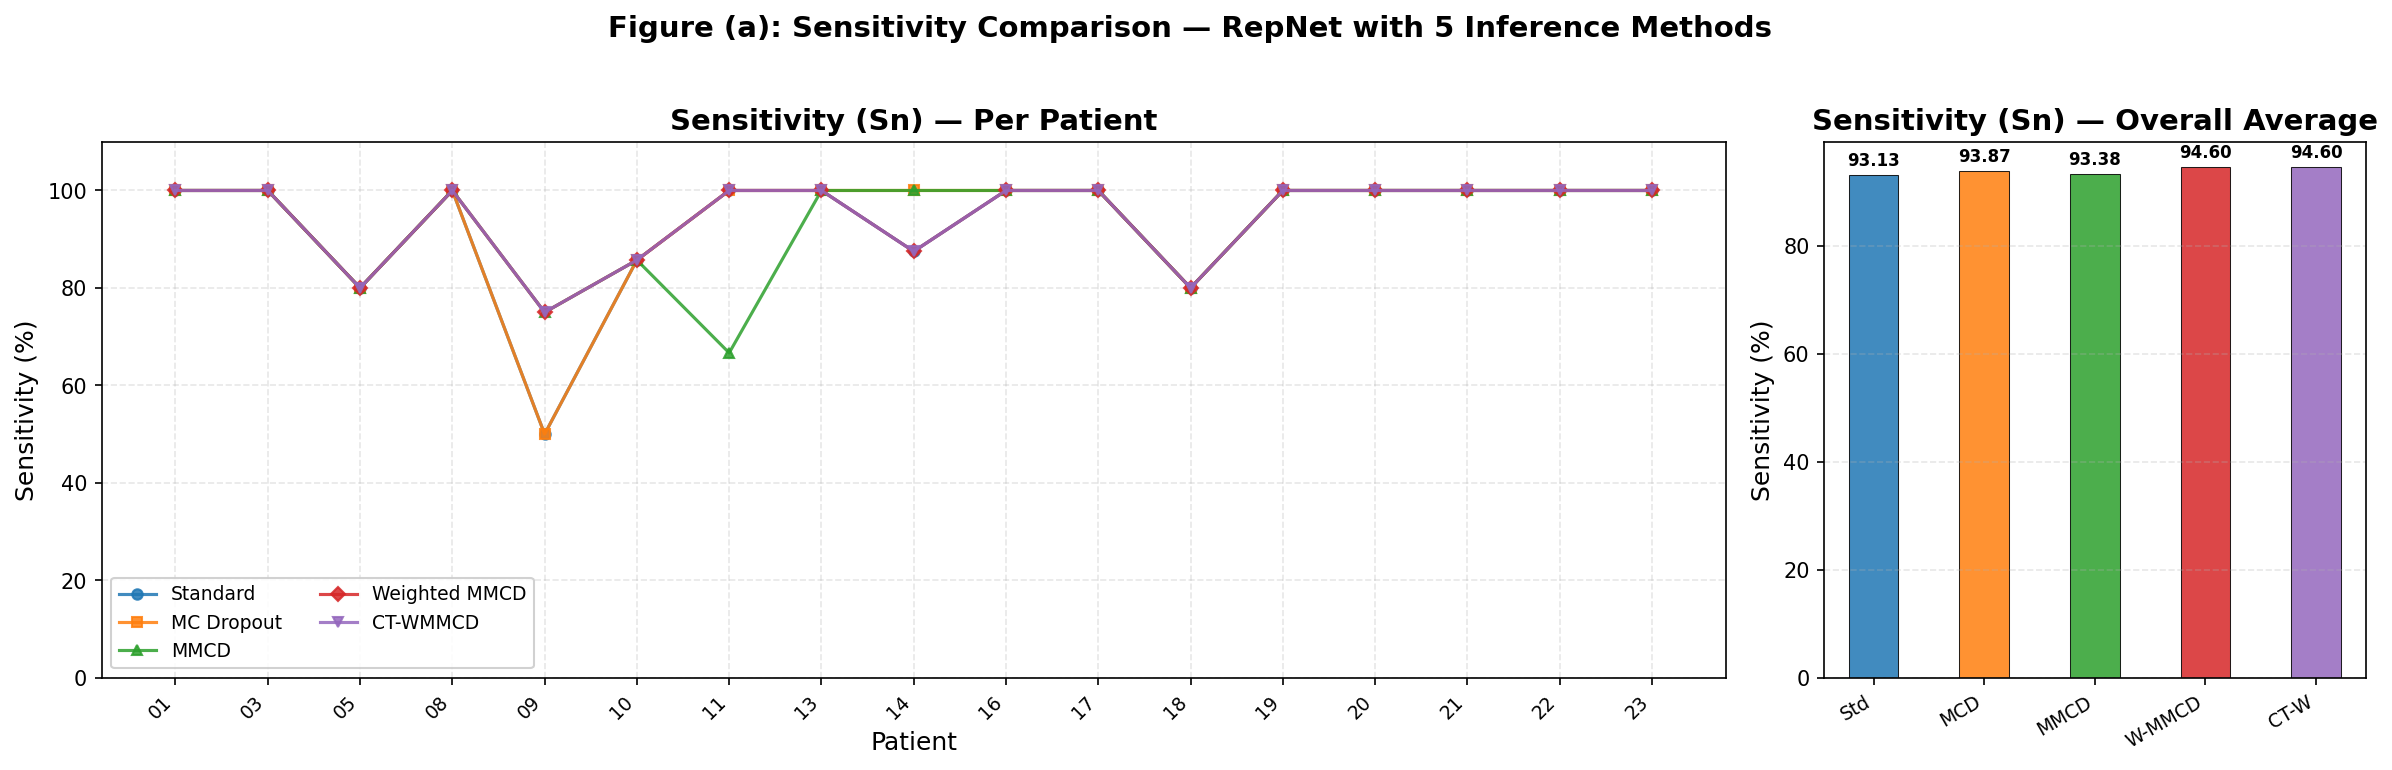

✅ Saved: /home/dst/Desktop/CHB/results/figures/fpr_comparison.png


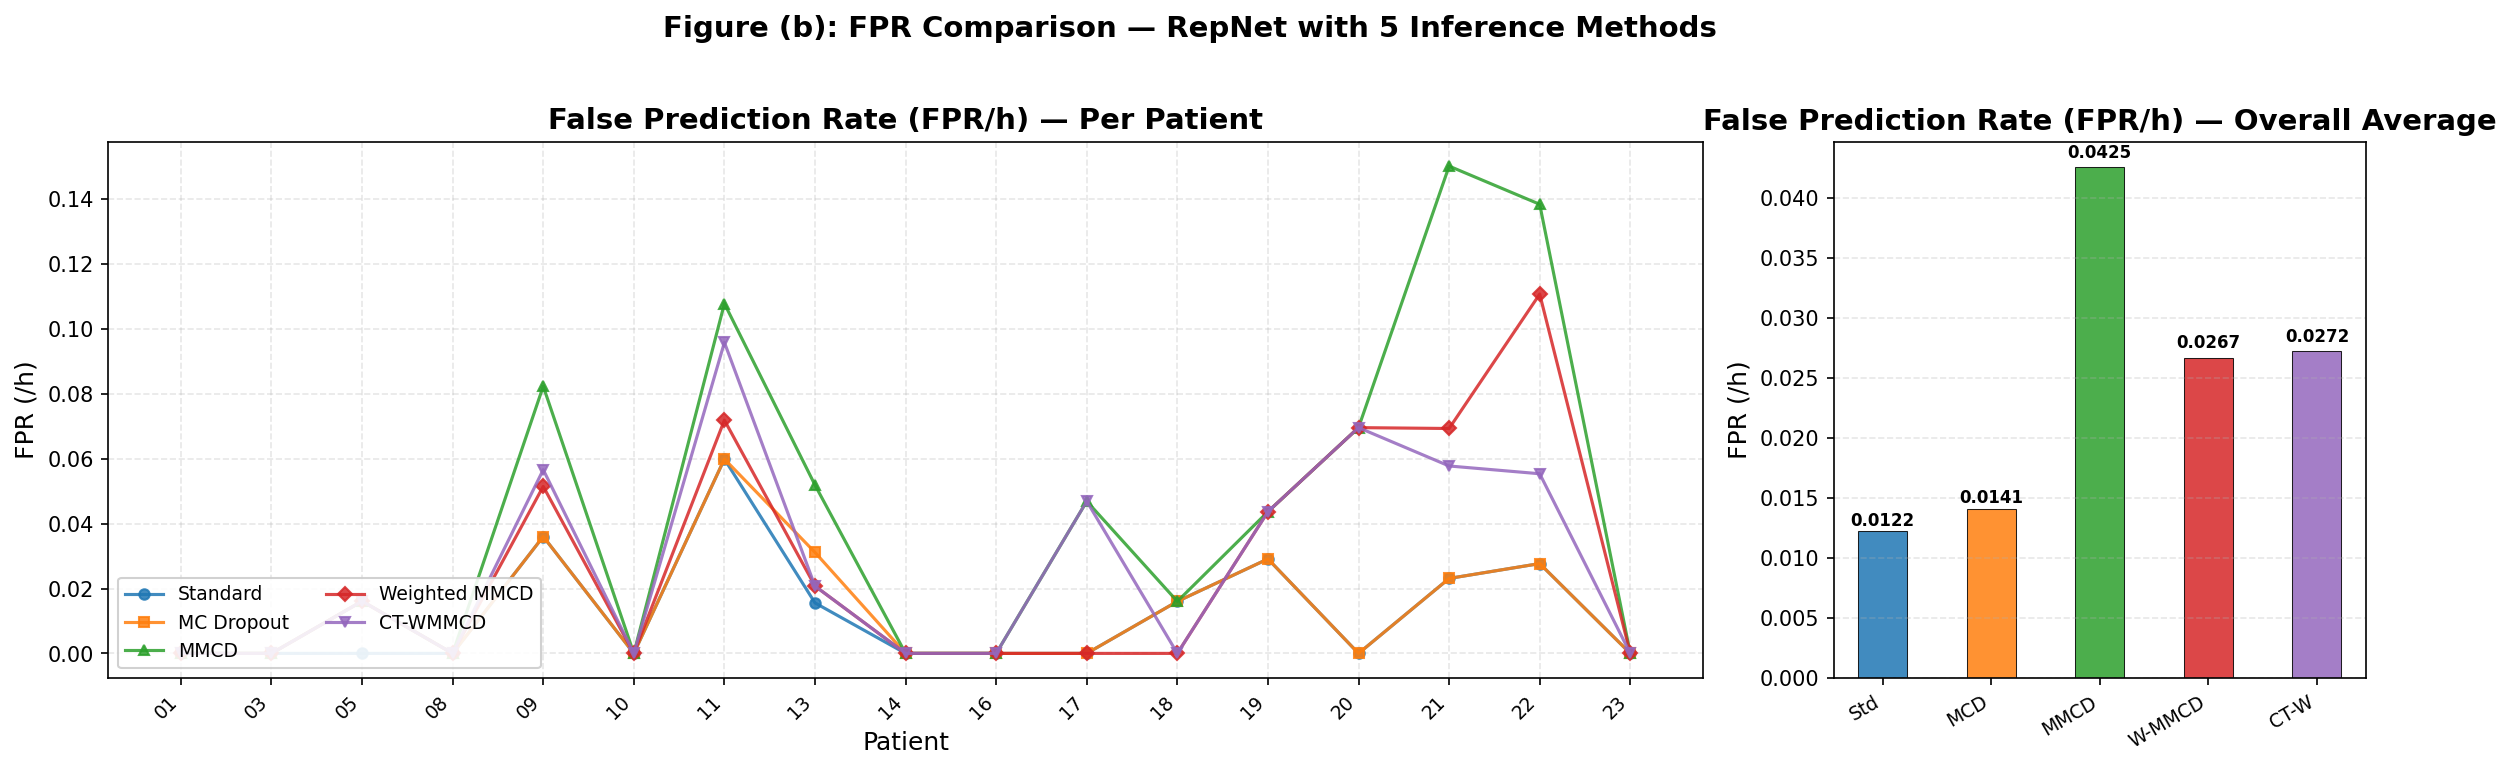

✅ Saved: /home/dst/Desktop/CHB/results/figures/auc_comparison.png


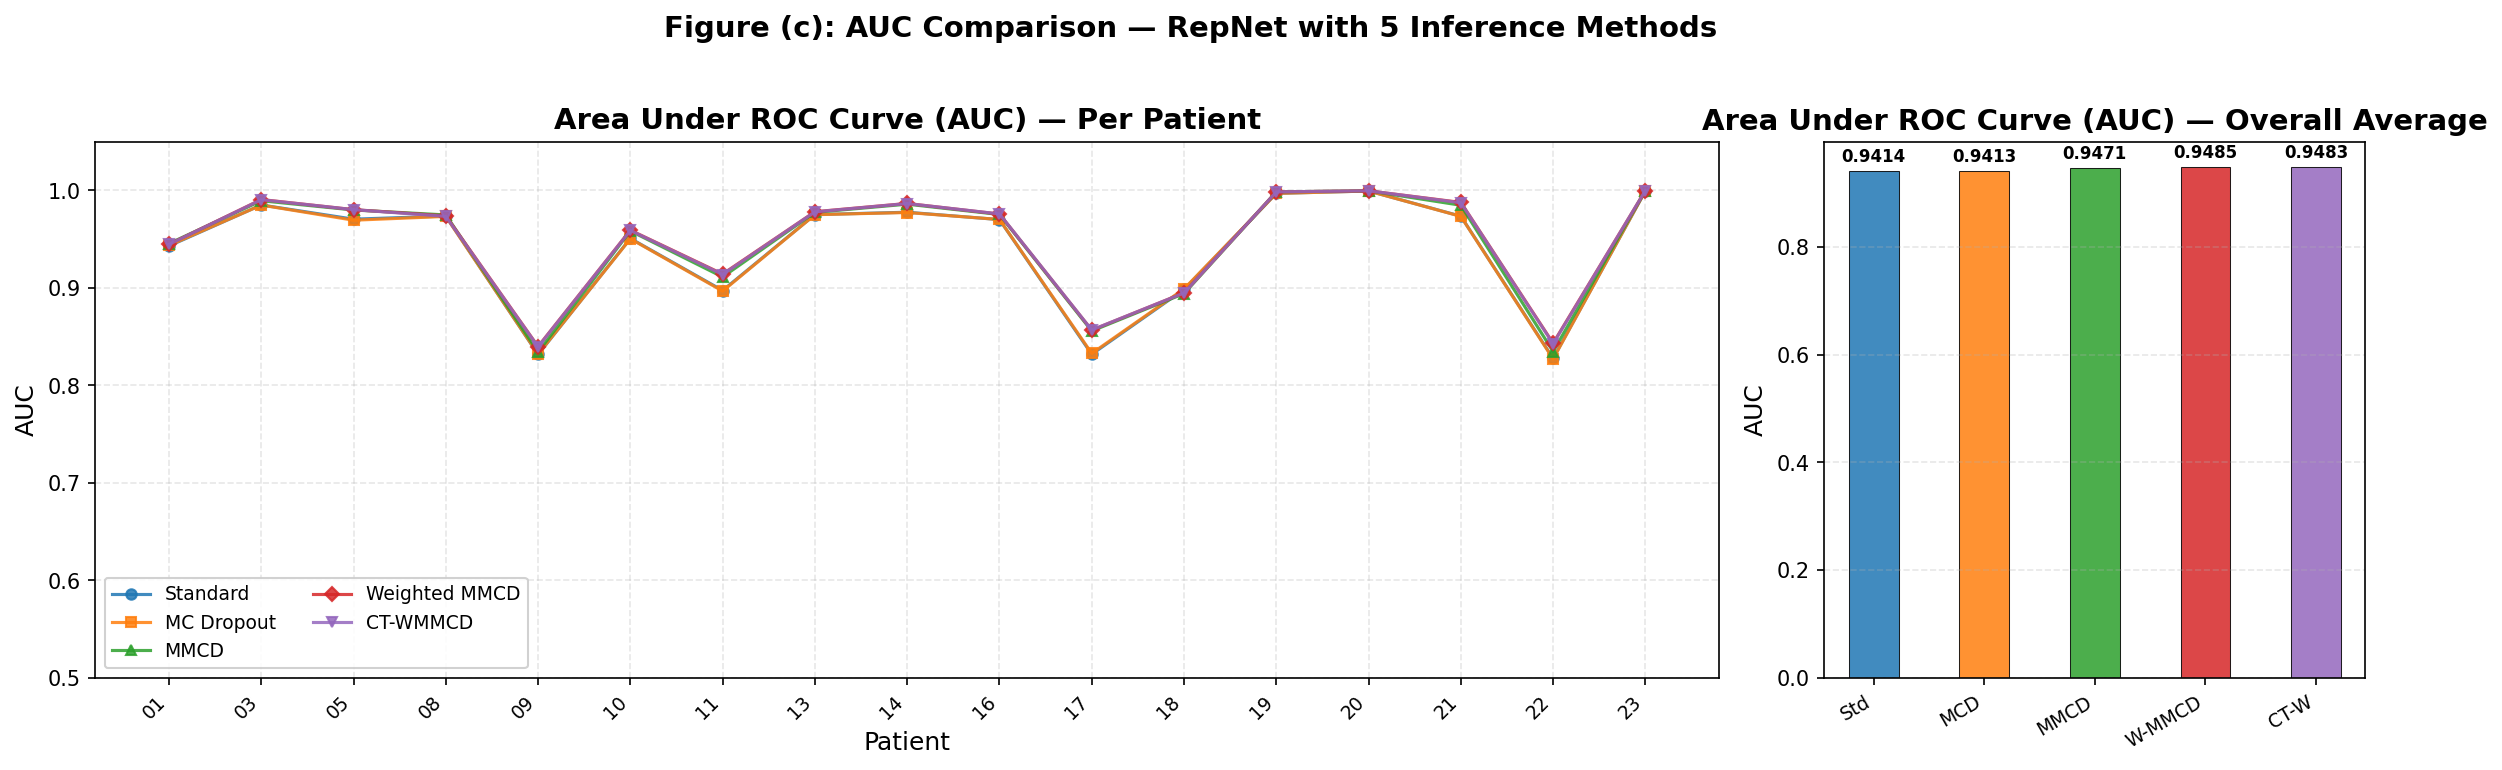

✅ Saved: /home/dst/Desktop/CHB/results/figures/combined_results.png


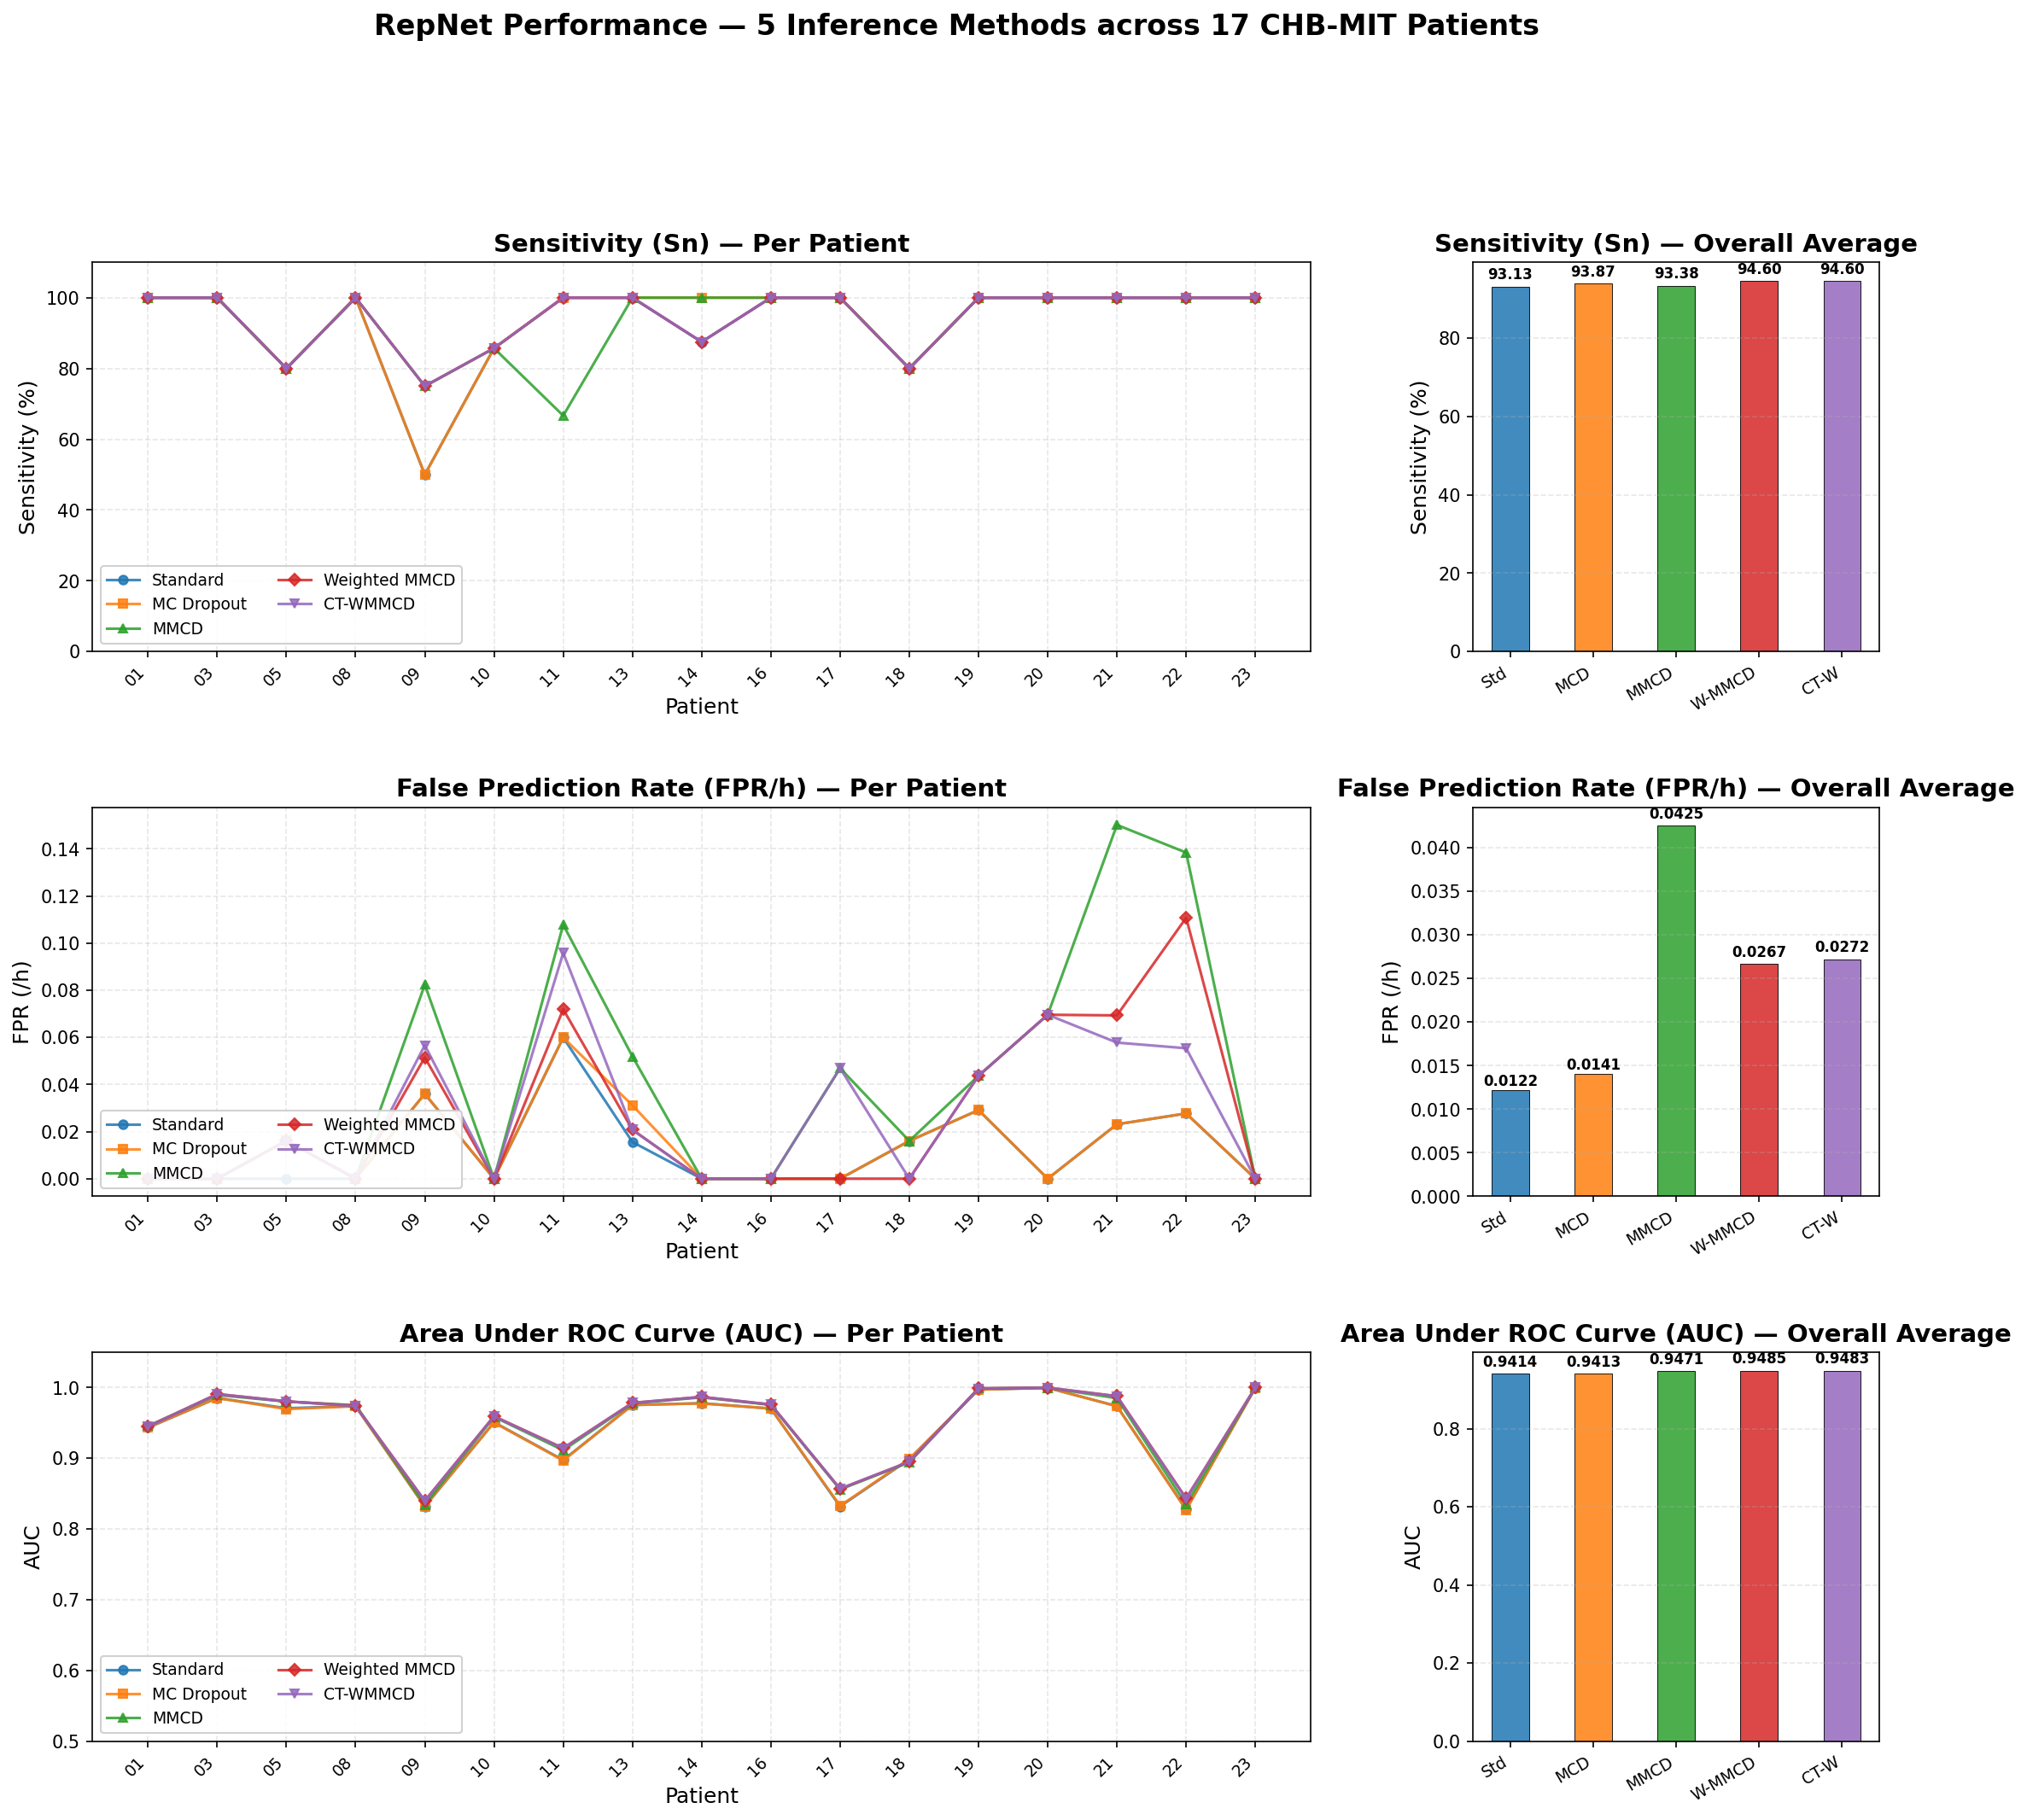

✅ Saved: /home/dst/Desktop/CHB/results/figures/paper_comparison.png


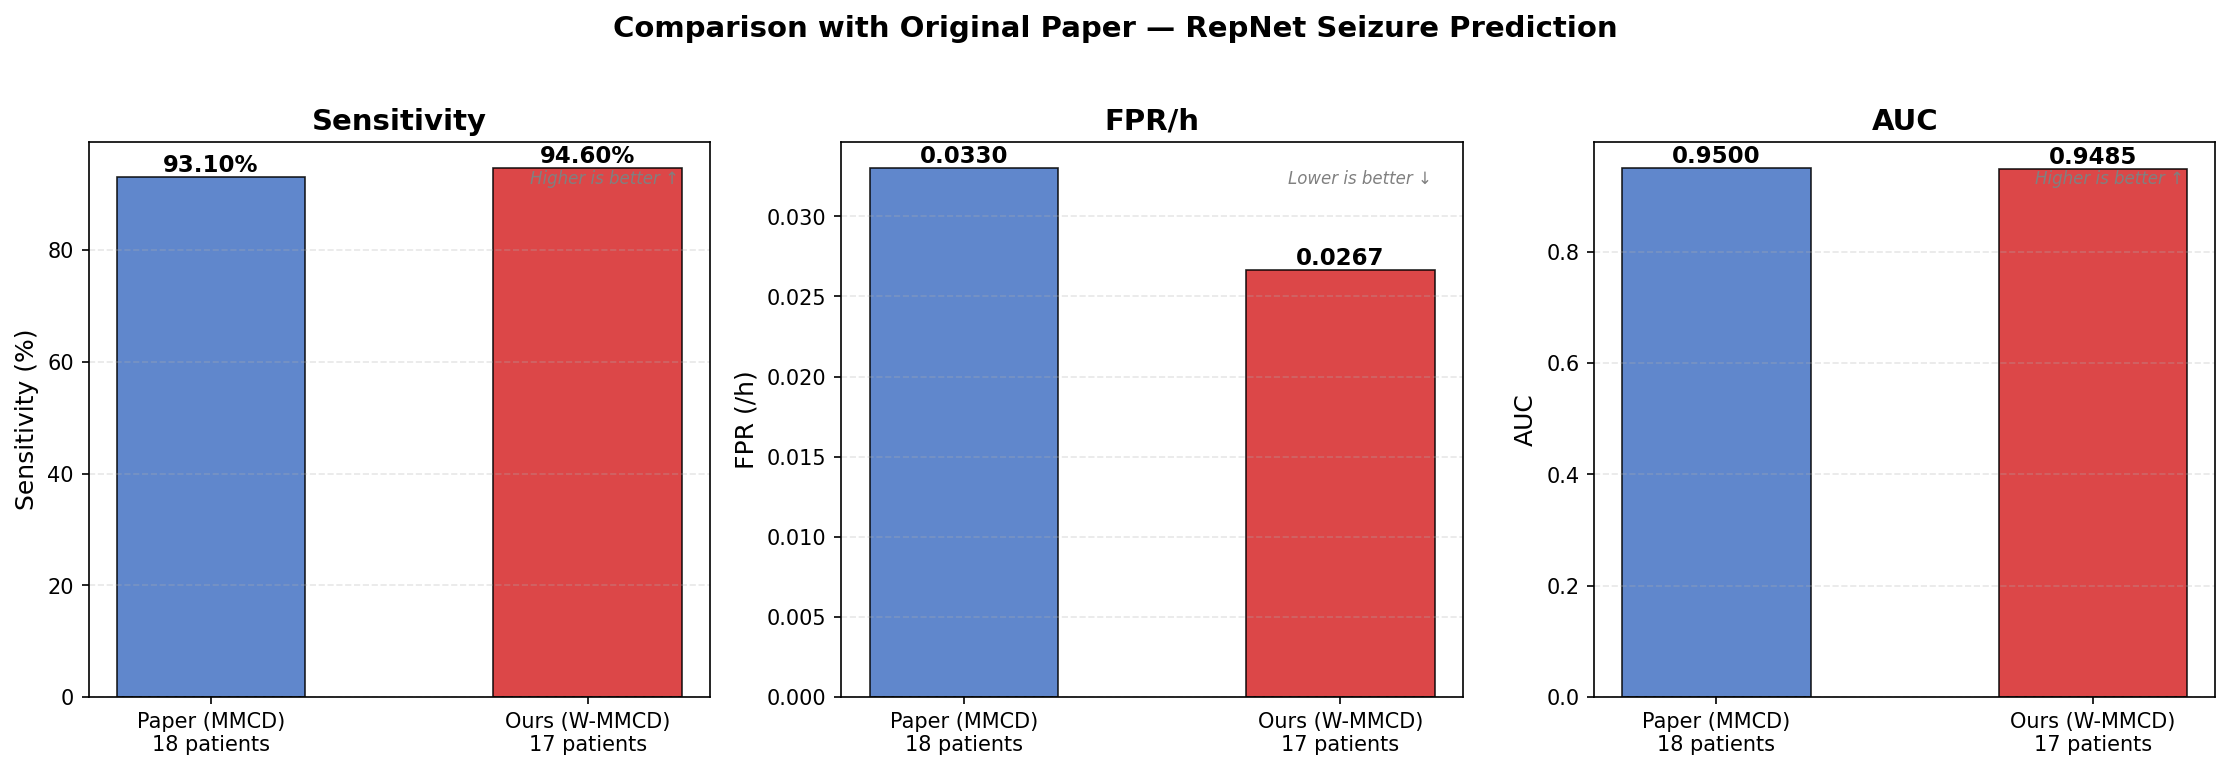


ALL FIGURES GENERATED SUCCESSFULLY!
Saved to: /home/dst/Desktop/CHB/results/figures


In [18]:
# ============================================================
# CELL: PLOT RESULTS — Paper-style figures (Sn, FPR, AUC)
# ============================================================
# Run this AFTER Cell 15 (evaluation) so that `all_results` is available
# 
# Produces 3 figures (saved as PNG):
#   1. Sensitivity — per-patient line chart + overall bar chart
#   2. FPR/h       — per-patient line chart + overall bar chart
#   3. AUC         — per-patient line chart + overall bar chart
# ============================================================

import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# ── Method config ──
method_names = ['Standard', 'MC Dropout', 'MMCD', 'Weighted MMCD', 'CT-WMMCD']
method_colors = {
    'Standard':      '#1f77b4',   # blue
    'MC Dropout':    '#ff7f0e',   # orange
    'MMCD':          '#2ca02c',   # green
    'Weighted MMCD': '#d62728',   # red
    'CT-WMMCD':      '#9467bd',   # purple
}
method_markers = {
    'Standard':      'o',
    'MC Dropout':    's',
    'MMCD':          '^',
    'Weighted MMCD': 'D',
    'CT-WMMCD':      'v',
}

# ── Extract data from all_results ──
patients = sorted(all_results.keys())
n_patients = len(patients)

data = {method: {'sens': [], 'fpr': [], 'auc': []} for method in method_names}
for p in patients:
    agg = all_results[p]['aggregated']
    for method in method_names:
        if method in agg:
            data[method]['sens'].append(agg[method]['sensitivity'] * 100)
            data[method]['fpr'].append(agg[method]['fpr_per_hour'])
            data[method]['auc'].append(agg[method]['auc'])
        else:
            data[method]['sens'].append(np.nan)
            data[method]['fpr'].append(np.nan)
            data[method]['auc'].append(np.nan)

# ── Averages ──
avg = {method: {
    'sens': np.nanmean(data[method]['sens']),
    'fpr':  np.nanmean(data[method]['fpr']),
    'auc':  np.nanmean(data[method]['auc']),
} for method in method_names}

# ── Patient labels (short) ──
patient_labels = [p.replace('chb', '') for p in patients]

# ============================================================
# HELPER: Draw one row (line chart + bar chart)
# ============================================================
def plot_metric_row(fig, axes, metric_key, ylabel, title, y_range=None, invert=False):
    """
    axes[0] = per-patient line chart
    axes[1] = overall bar chart
    """
    ax_line = axes[0]
    ax_bar  = axes[1]
    x = np.arange(n_patients)

    # ── Line chart ──
    for method in method_names:
        vals = data[method][metric_key]
        ax_line.plot(x, vals,
                     color=method_colors[method],
                     marker=method_markers[method],
                     markersize=5,
                     linewidth=1.5,
                     label=method,
                     alpha=0.85)

    ax_line.set_xticks(x)
    ax_line.set_xticklabels(patient_labels, rotation=45, ha='right')
    ax_line.set_xlabel('Patient')
    ax_line.set_ylabel(ylabel)
    ax_line.set_title(f'{title} — Per Patient')
    ax_line.legend(loc='lower left', framealpha=0.9, ncol=2)
    ax_line.grid(True, alpha=0.3, linestyle='--')
    if y_range:
        ax_line.set_ylim(y_range)

    # ── Bar chart ──
    bar_width = 0.15
    x_bar = np.arange(len(method_names))
    bars = []
    for i, method in enumerate(method_names):
        val = avg[method][metric_key]
        bar = ax_bar.bar(i, val,
                         width=bar_width * 3,
                         color=method_colors[method],
                         edgecolor='black',
                         linewidth=0.5,
                         alpha=0.85)
        bars.append(bar)
        # Value label on top
        if metric_key == 'fpr':
            label_text = f'{val:.4f}'
        elif metric_key == 'sens':
            label_text = f'{val:.2f}'
        else:
            label_text = f'{val:.4f}'
        ax_bar.text(i, val + (ax_bar.get_ylim()[1] - ax_bar.get_ylim()[0]) * 0.01,
                    label_text,
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax_bar.set_xticks(x_bar)
    ax_bar.set_xticklabels(['Std', 'MCD', 'MMCD', 'W-MMCD', 'CT-W'],
                           rotation=30, ha='right', fontsize=9)
    ax_bar.set_ylabel(ylabel)
    ax_bar.set_title(f'{title} — Overall Average')
    ax_bar.grid(True, alpha=0.3, linestyle='--', axis='y')


# ============================================================
# FIGURE 1: SENSITIVITY (Sn)
# ============================================================
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [3, 1]})
plot_metric_row(fig1, axes1, 'sens', 'Sensitivity (%)', 'Sensitivity (Sn)', y_range=(0, 110))
fig1.suptitle('Figure (a): Sensitivity Comparison — RepNet with 5 Inference Methods',
              fontsize=14, fontweight='bold', y=1.02)
fig1.tight_layout()
fig1_path = os.path.join(RESULTS_DIR, 'figures', 'sensitivity_comparison.png')
fig1.savefig(fig1_path, bbox_inches='tight')
print(f"✅ Saved: {fig1_path}")
plt.show()

# ============================================================
# FIGURE 2: FPR/h
# ============================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [3, 1]})
plot_metric_row(fig2, axes2, 'fpr', 'FPR (/h)', 'False Prediction Rate (FPR/h)')
fig2.suptitle('Figure (b): FPR Comparison — RepNet with 5 Inference Methods',
              fontsize=14, fontweight='bold', y=1.02)
fig2.tight_layout()
fig2_path = os.path.join(RESULTS_DIR, 'figures', 'fpr_comparison.png')
fig2.savefig(fig2_path, bbox_inches='tight')
print(f"✅ Saved: {fig2_path}")
plt.show()

# ============================================================
# FIGURE 3: AUC
# ============================================================
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [3, 1]})
plot_metric_row(fig3, axes3, 'auc', 'AUC', 'Area Under ROC Curve (AUC)', y_range=(0.5, 1.05))
fig3.suptitle('Figure (c): AUC Comparison — RepNet with 5 Inference Methods',
              fontsize=14, fontweight='bold', y=1.02)
fig3.tight_layout()
fig3_path = os.path.join(RESULTS_DIR, 'figures', 'auc_comparison.png')
fig3.savefig(fig3_path, bbox_inches='tight')
print(f"✅ Saved: {fig3_path}")
plt.show()

# ============================================================
# FIGURE 4: COMBINED — all 3 metrics in one figure (like paper)
# ============================================================
fig4, axes4 = plt.subplots(3, 2, figsize=(18, 15), 
                            gridspec_kw={'width_ratios': [3, 1], 'hspace': 0.4})

# Row 1: Sensitivity
plot_metric_row(fig4, axes4[0], 'sens', 'Sensitivity (%)', 'Sensitivity (Sn)', y_range=(0, 110))

# Row 2: FPR
plot_metric_row(fig4, axes4[1], 'fpr', 'FPR (/h)', 'False Prediction Rate (FPR/h)')

# Row 3: AUC
plot_metric_row(fig4, axes4[2], 'auc', 'AUC', 'Area Under ROC Curve (AUC)', y_range=(0.5, 1.05))

fig4.suptitle('RepNet Performance — 5 Inference Methods across 17 CHB-MIT Patients',
              fontsize=16, fontweight='bold', y=1.01)
fig4.tight_layout()
fig4_path = os.path.join(RESULTS_DIR, 'figures', 'combined_results.png')
fig4.savefig(fig4_path, bbox_inches='tight')
print(f"✅ Saved: {fig4_path}")
plt.show()

# ============================================================
# FIGURE 5: COMPARISON WITH PAPER (bar chart)
# ============================================================
fig5, axes5 = plt.subplots(1, 3, figsize=(15, 5))

# Paper's reported values (CNN-MMCD on CHB-MIT, 18 patients)
paper_vals = {'sens': 93.1, 'fpr': 0.033, 'auc': 0.950}
our_best = {
    'sens': avg['Weighted MMCD']['sens'],
    'fpr':  avg['Weighted MMCD']['fpr'],
    'auc':  avg['Weighted MMCD']['auc'],
}

metrics = ['sens', 'fpr', 'auc']
metric_labels = ['Sensitivity (%)', 'FPR (/h)', 'AUC']
metric_titles = ['Sensitivity', 'FPR/h', 'AUC']

for idx, (key, ylabel, title) in enumerate(zip(metrics, metric_labels, metric_titles)):
    ax = axes5[idx]
    x_pos = [0, 1]
    vals = [paper_vals[key], our_best[key]]
    colors = ['#4472C4', '#d62728']
    labels = [f'Paper (MMCD)\n18 patients', f'Ours (W-MMCD)\n17 patients']

    bars = ax.bar(x_pos, vals, color=colors, edgecolor='black',
                  linewidth=0.8, width=0.5, alpha=0.85)

    for bar, val in zip(bars, vals):
        if key == 'fpr':
            text = f'{val:.4f}'
        elif key == 'sens':
            text = f'{val:.2f}%'
        else:
            text = f'{val:.4f}'
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                text, ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')

    # For FPR, lower is better — add arrow
    if key == 'fpr':
        ax.annotate('Lower is better ↓', xy=(0.95, 0.95), xycoords='axes fraction',
                    ha='right', va='top', fontsize=8, fontstyle='italic', color='gray')
    else:
        ax.annotate('Higher is better ↑', xy=(0.95, 0.95), xycoords='axes fraction',
                    ha='right', va='top', fontsize=8, fontstyle='italic', color='gray')

fig5.suptitle('Comparison with Original Paper — RepNet Seizure Prediction',
              fontsize=14, fontweight='bold', y=1.02)
fig5.tight_layout()
fig5_path = os.path.join(RESULTS_DIR, 'figures', 'paper_comparison.png')
fig5.savefig(fig5_path, bbox_inches='tight')
print(f"✅ Saved: {fig5_path}")
plt.show()

print("\n" + "=" * 60)
print("ALL FIGURES GENERATED SUCCESSFULLY!")
print(f"Saved to: {os.path.join(RESULTS_DIR, 'figures')}")
print("=" * 60)

✅ Saved: /home/dst/Desktop/CHB/results/figures/repnet_wmmcd_results.png


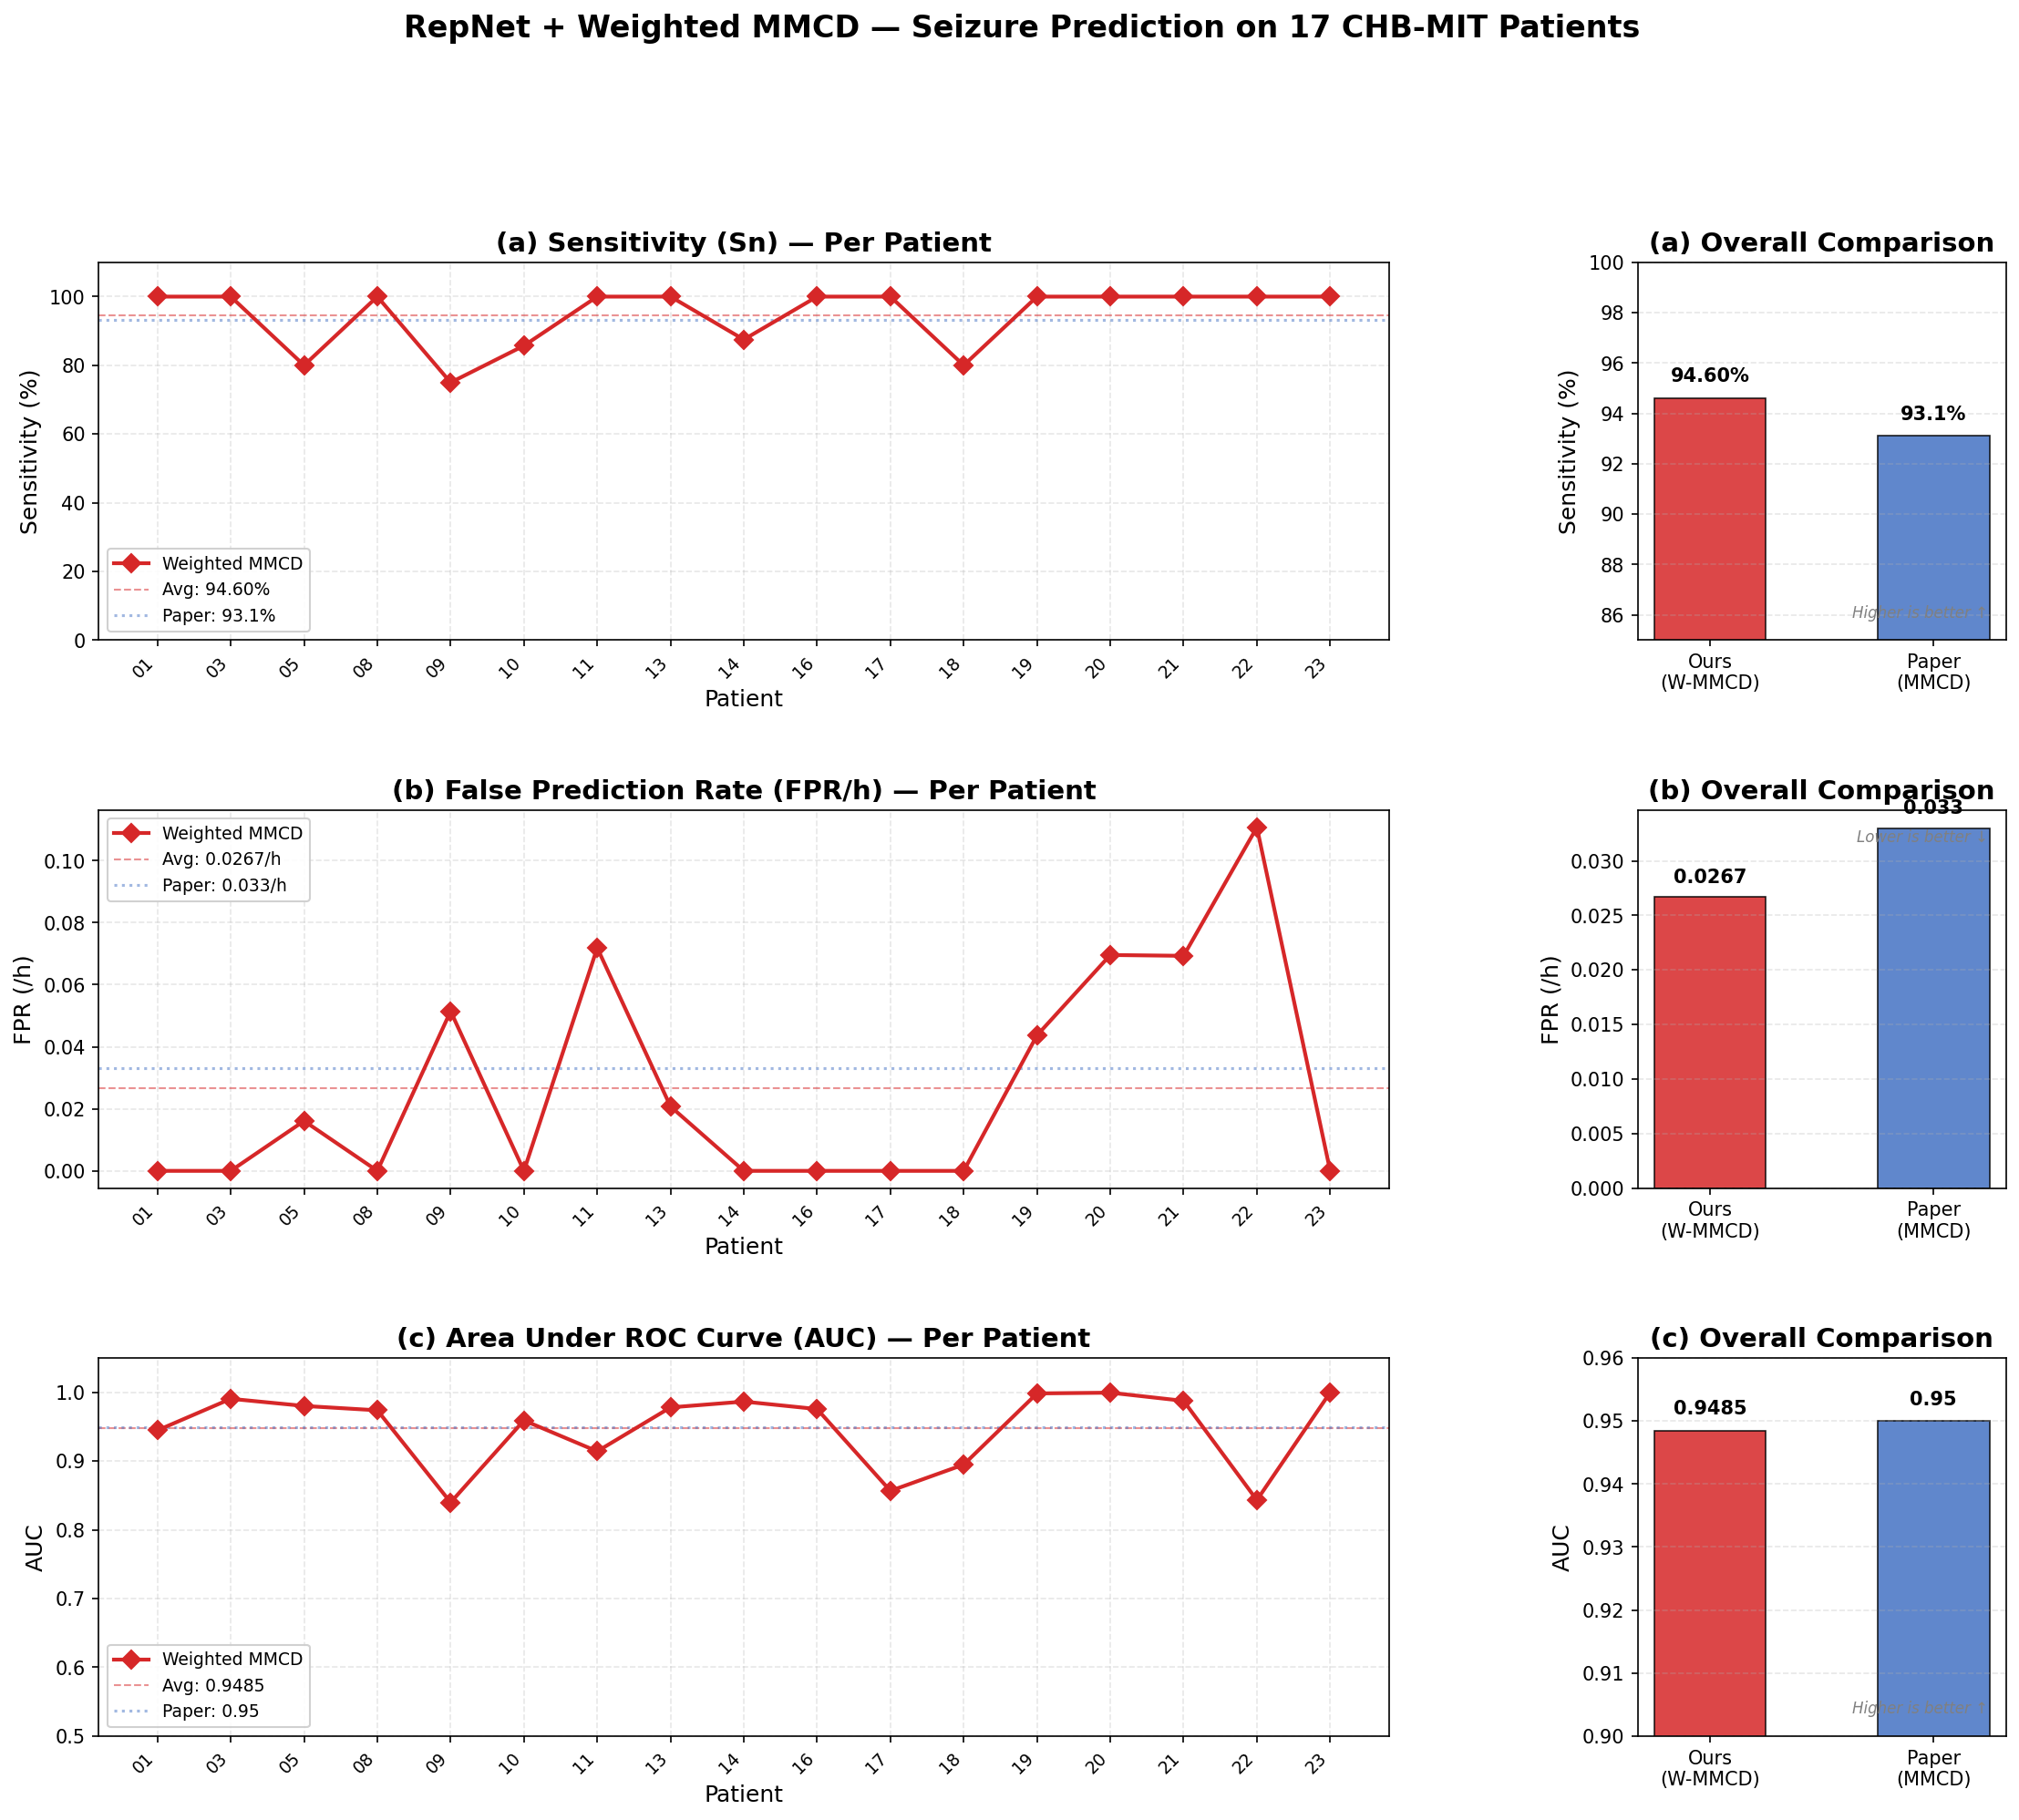


FIGURE GENERATED SUCCESSFULLY!
Saved to: /home/dst/Desktop/CHB/results/figures/repnet_wmmcd_results.png


In [19]:
# ============================================================
# CELL: PLOT RESULTS — RepNet Weighted MMCD Only
# ============================================================
# Run this AFTER Cell 15 (evaluation) so that `all_results` is available
# ============================================================

import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# ── Extract Weighted MMCD data ──
patients = sorted(all_results.keys())
n_patients = len(patients)
patient_labels = [p.replace('chb', '') for p in patients]

sens_vals = []
fpr_vals = []
auc_vals = []

for p in patients:
    m = all_results[p]['aggregated']['Weighted MMCD']
    sens_vals.append(m['sensitivity'] * 100)
    fpr_vals.append(m['fpr_per_hour'])
    auc_vals.append(m['auc'])

avg_sens = np.mean(sens_vals)
avg_fpr = np.mean(fpr_vals)
avg_auc = np.mean(auc_vals)

# Paper values
paper_sens = 93.1
paper_fpr = 0.033
paper_auc = 0.950

x = np.arange(n_patients)

# ============================================================
# COMBINED FIGURE: 3 rows × 2 cols (line chart + bar chart)
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(18, 14),
                         gridspec_kw={'width_ratios': [3.5, 1], 'hspace': 0.45, 'wspace': 0.3})

# ────────────────────────────────────────
# ROW 1: SENSITIVITY (Sn)
# ────────────────────────────────────────
ax1_line, ax1_bar = axes[0]

ax1_line.plot(x, sens_vals, color='#d62728', marker='D', markersize=7,
              linewidth=2, label='Weighted MMCD', zorder=3)
ax1_line.axhline(y=avg_sens, color='#d62728', linestyle='--', alpha=0.5, linewidth=1,
                 label=f'Avg: {avg_sens:.2f}%')
ax1_line.axhline(y=paper_sens, color='#4472C4', linestyle=':', alpha=0.5, linewidth=1.5,
                 label=f'Paper: {paper_sens}%')
ax1_line.set_xticks(x)
ax1_line.set_xticklabels(patient_labels, rotation=45, ha='right')
ax1_line.set_xlabel('Patient')
ax1_line.set_ylabel('Sensitivity (%)')
ax1_line.set_title('(a) Sensitivity (Sn) — Per Patient')
ax1_line.set_ylim(0, 110)
ax1_line.legend(loc='lower left', framealpha=0.9)
ax1_line.grid(True, alpha=0.3, linestyle='--')

# Bar: Ours vs Paper
bars1 = ax1_bar.bar([0, 1], [avg_sens, paper_sens],
                    color=['#d62728', '#4472C4'], edgecolor='black',
                    linewidth=0.8, width=0.5, alpha=0.85)
ax1_bar.text(0, avg_sens + 0.5, f'{avg_sens:.2f}%', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax1_bar.text(1, paper_sens + 0.5, f'{paper_sens}%', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax1_bar.set_xticks([0, 1])
ax1_bar.set_xticklabels(['Ours\n(W-MMCD)', 'Paper\n(MMCD)'], fontsize=10)
ax1_bar.set_ylabel('Sensitivity (%)')
ax1_bar.set_title('(a) Overall Comparison')
ax1_bar.set_ylim(85, 100)
ax1_bar.grid(True, alpha=0.3, linestyle='--', axis='y')
ax1_bar.annotate('Higher is better ↑', xy=(0.95, 0.05), xycoords='axes fraction',
                 ha='right', va='bottom', fontsize=8, fontstyle='italic', color='gray')

# ────────────────────────────────────────
# ROW 2: FPR/h
# ────────────────────────────────────────
ax2_line, ax2_bar = axes[1]

ax2_line.plot(x, fpr_vals, color='#d62728', marker='D', markersize=7,
              linewidth=2, label='Weighted MMCD', zorder=3)
ax2_line.axhline(y=avg_fpr, color='#d62728', linestyle='--', alpha=0.5, linewidth=1,
                 label=f'Avg: {avg_fpr:.4f}/h')
ax2_line.axhline(y=paper_fpr, color='#4472C4', linestyle=':', alpha=0.5, linewidth=1.5,
                 label=f'Paper: {paper_fpr}/h')
ax2_line.set_xticks(x)
ax2_line.set_xticklabels(patient_labels, rotation=45, ha='right')
ax2_line.set_xlabel('Patient')
ax2_line.set_ylabel('FPR (/h)')
ax2_line.set_title('(b) False Prediction Rate (FPR/h) — Per Patient')
ax2_line.legend(loc='upper left', framealpha=0.9)
ax2_line.grid(True, alpha=0.3, linestyle='--')

# Bar: Ours vs Paper
bars2 = ax2_bar.bar([0, 1], [avg_fpr, paper_fpr],
                    color=['#d62728', '#4472C4'], edgecolor='black',
                    linewidth=0.8, width=0.5, alpha=0.85)
ax2_bar.text(0, avg_fpr + 0.001, f'{avg_fpr:.4f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax2_bar.text(1, paper_fpr + 0.001, f'{paper_fpr}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax2_bar.set_xticks([0, 1])
ax2_bar.set_xticklabels(['Ours\n(W-MMCD)', 'Paper\n(MMCD)'], fontsize=10)
ax2_bar.set_ylabel('FPR (/h)')
ax2_bar.set_title('(b) Overall Comparison')
ax2_bar.grid(True, alpha=0.3, linestyle='--', axis='y')
ax2_bar.annotate('Lower is better ↓', xy=(0.95, 0.95), xycoords='axes fraction',
                 ha='right', va='top', fontsize=8, fontstyle='italic', color='gray')

# ────────────────────────────────────────
# ROW 3: AUC
# ────────────────────────────────────────
ax3_line, ax3_bar = axes[2]

ax3_line.plot(x, auc_vals, color='#d62728', marker='D', markersize=7,
              linewidth=2, label='Weighted MMCD', zorder=3)
ax3_line.axhline(y=avg_auc, color='#d62728', linestyle='--', alpha=0.5, linewidth=1,
                 label=f'Avg: {avg_auc:.4f}')
ax3_line.axhline(y=paper_auc, color='#4472C4', linestyle=':', alpha=0.5, linewidth=1.5,
                 label=f'Paper: {paper_auc}')
ax3_line.set_xticks(x)
ax3_line.set_xticklabels(patient_labels, rotation=45, ha='right')
ax3_line.set_xlabel('Patient')
ax3_line.set_ylabel('AUC')
ax3_line.set_title('(c) Area Under ROC Curve (AUC) — Per Patient')
ax3_line.set_ylim(0.5, 1.05)
ax3_line.legend(loc='lower left', framealpha=0.9)
ax3_line.grid(True, alpha=0.3, linestyle='--')

# Bar: Ours vs Paper
bars3 = ax3_bar.bar([0, 1], [avg_auc, paper_auc],
                    color=['#d62728', '#4472C4'], edgecolor='black',
                    linewidth=0.8, width=0.5, alpha=0.85)
ax3_bar.text(0, avg_auc + 0.002, f'{avg_auc:.4f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax3_bar.text(1, paper_auc + 0.002, f'{paper_auc}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax3_bar.set_xticks([0, 1])
ax3_bar.set_xticklabels(['Ours\n(W-MMCD)', 'Paper\n(MMCD)'], fontsize=10)
ax3_bar.set_ylabel('AUC')
ax3_bar.set_title('(c) Overall Comparison')
ax3_bar.set_ylim(0.9, 0.96)
ax3_bar.grid(True, alpha=0.3, linestyle='--', axis='y')
ax3_bar.annotate('Higher is better ↑', xy=(0.95, 0.05), xycoords='axes fraction',
                 ha='right', va='bottom', fontsize=8, fontstyle='italic', color='gray')

fig.suptitle('RepNet + Weighted MMCD — Seizure Prediction on 17 CHB-MIT Patients',
             fontsize=16, fontweight='bold', y=1.01)

fig_path = os.path.join(RESULTS_DIR, 'figures', 'repnet_wmmcd_results.png')
fig.savefig(fig_path, bbox_inches='tight')
print(f"✅ Saved: {fig_path}")
plt.show()

print("\n" + "=" * 60)
print("FIGURE GENERATED SUCCESSFULLY!")
print(f"Saved to: {fig_path}")
print("=" * 60)

In [ ]:
(base) dst@research-gem:~/Downloads$ sudo apt install ./rustdesk-1.4.6-x86_64.deb
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'rustdesk' instead of './rustdesk-1.4.6-x86_64.deb'
The following additional packages will be installed:
  libxdo3
The following NEW packages will be installed:
  libxdo3 rustdesk
0 upgraded, 2 newly installed, 0 to remove and 327 not upgraded.
Need to get 22.2 kB/23.2 MB of archives.
After this operation, 84.0 kB of additional disk space will be used.
Do you want to continue? [Y/n] y
Get:1 /home/dst/Downloads/rustdesk-1.4.6-x86_64.deb rustdesk amd64 1.4.6 [23.1 MB]
Get:2 http://in.archive.ubuntu.com/ubuntu noble/universe amd64 libxdo3 amd64 1:3.20160805.1-5build1 [22.2 kB]
Fetched 22.2 kB in 1s (34.0 kB/s)  
Selecting previously unselected package libxdo3:amd64.
(Reading database ... 269888 files and directories currently installed.)
Preparing to unpack .../libxdo3_1%3a3.20160805.1-5build1_amd64.deb ...
Unpacking libxdo3:amd64 (1:3.20160805.1-5build1) ...
Selecting previously unselected package rustdesk.
Preparing to unpack .../rustdesk-1.4.6-x86_64.deb ...
Failed to stop rustdesk.service: Unit rustdesk.service not loaded.
Unpacking rustdesk (1.4.6) ...
Setting up libxdo3:amd64 (1:3.20160805.1-5build1) ...
Setting up rustdesk (1.4.6) ...
Created symlink /etc/systemd/system/multi-user.target.wants/rustdesk.service → /usr/lib/systemd/system/rustdesk.service.
Processing triggers for hicolor-icon-theme (0.17-2) ...
Processing triggers for gnome-menus (3.36.0-1.1ubuntu3) ...
Processing triggers for libc-bin (2.39-0ubuntu8.7) ...
Processing triggers for desktop-file-utils (0.27-2build1) ...
N: Download is performed unsandboxed as root as file '/home/dst/Downloads/rustdesk-1.4.6-x86_64.deb' couldn't be accessed by user '_apt'. - pkgAcquire::Run (13: Permission denied)


All 23 dependencies found. Running uncertainty analysis...

Running uncertainty analysis on 17 patients

UNCERTAINTY QUANTIFICATION

--- chb01 ---
  Standard         ECE=0.018  Brier=0.009  NLL=0.052  ErrDetAUC=nan
  MC Dropout       ECE=0.018  Brier=0.009  NLL=0.052  ErrDetAUC=nan
  MMCD             ECE=0.019  Brier=0.009  NLL=0.051  ErrDetAUC=nan
  Weighted MMCD    ECE=0.018  Brier=0.009  NLL=0.051  ErrDetAUC=nan
  CT-WMMCD         ECE=0.018  Brier=0.009  NLL=0.051  ErrDetAUC=nan

--- chb03 ---
  Standard         ECE=0.018  Brier=0.019  NLL=0.066  ErrDetAUC=0.976
  MC Dropout       ECE=0.018  Brier=0.019  NLL=0.066  ErrDetAUC=0.976
  MMCD             ECE=0.019  Brier=0.018  NLL=0.062  ErrDetAUC=0.982
  Weighted MMCD    ECE=0.019  Brier=0.018  NLL=0.063  ErrDetAUC=0.984
  CT-WMMCD         ECE=0.019  Brier=0.018  NLL=0.063  ErrDetAUC=0.984

--- chb05 ---
  Standard         ECE=0.034  Brier=0.033  NLL=0.156  ErrDetAUC=0.948
  MC Dropout       ECE=0.034  Brier=0.033  NLL=0.155  ErrDetAUC

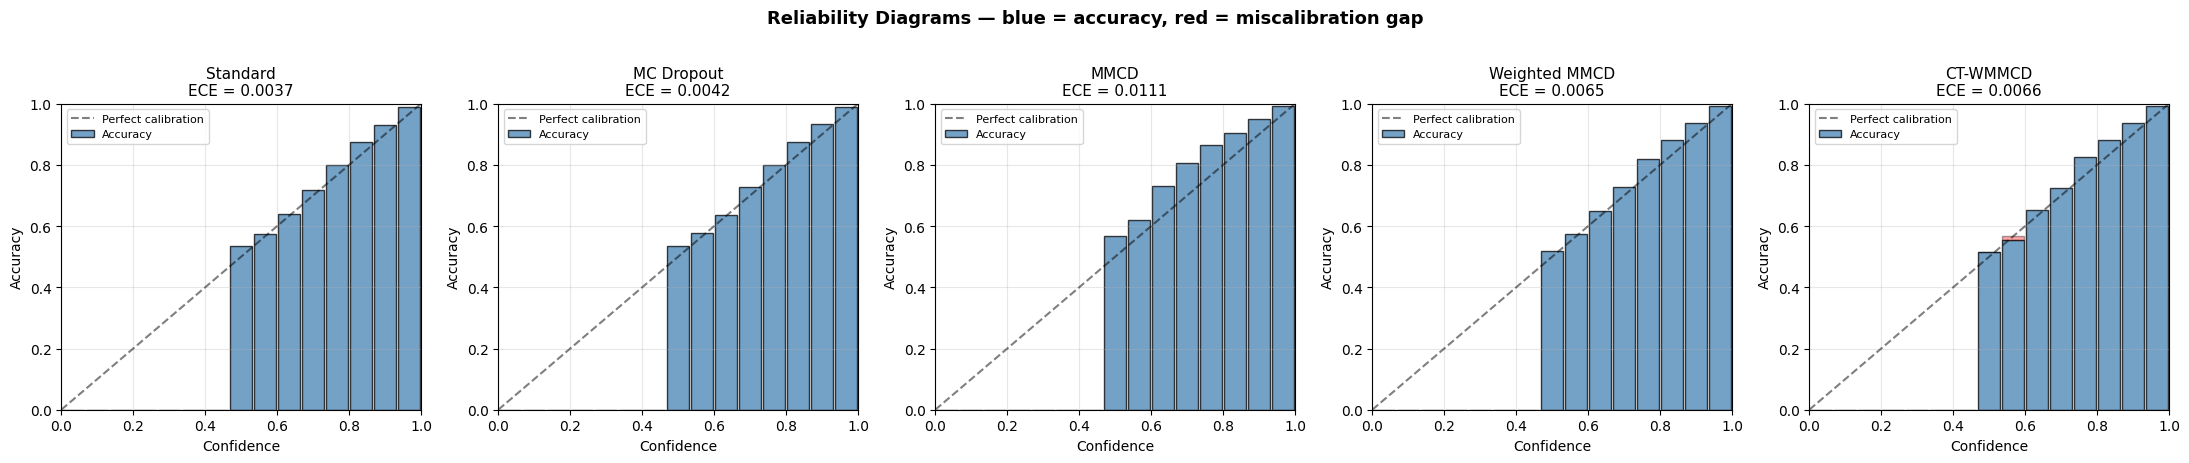

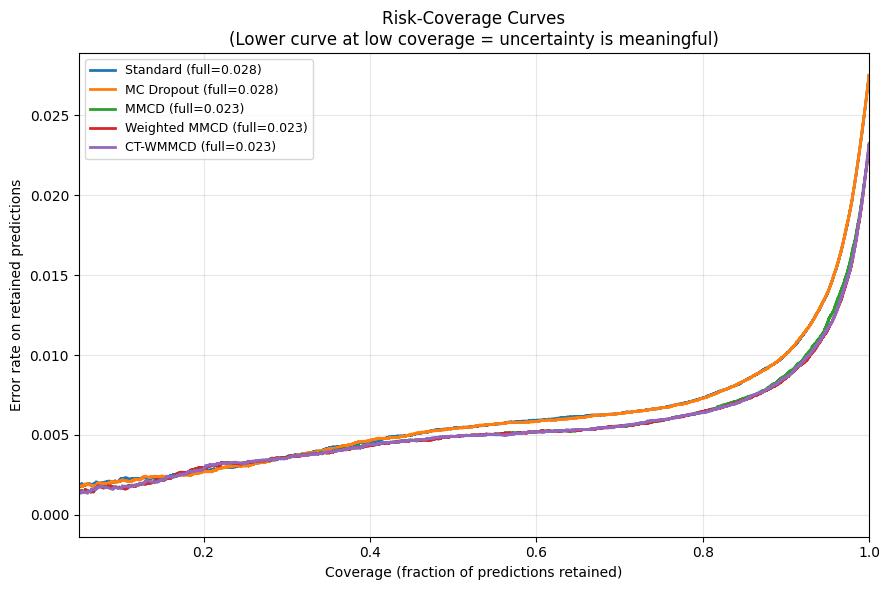

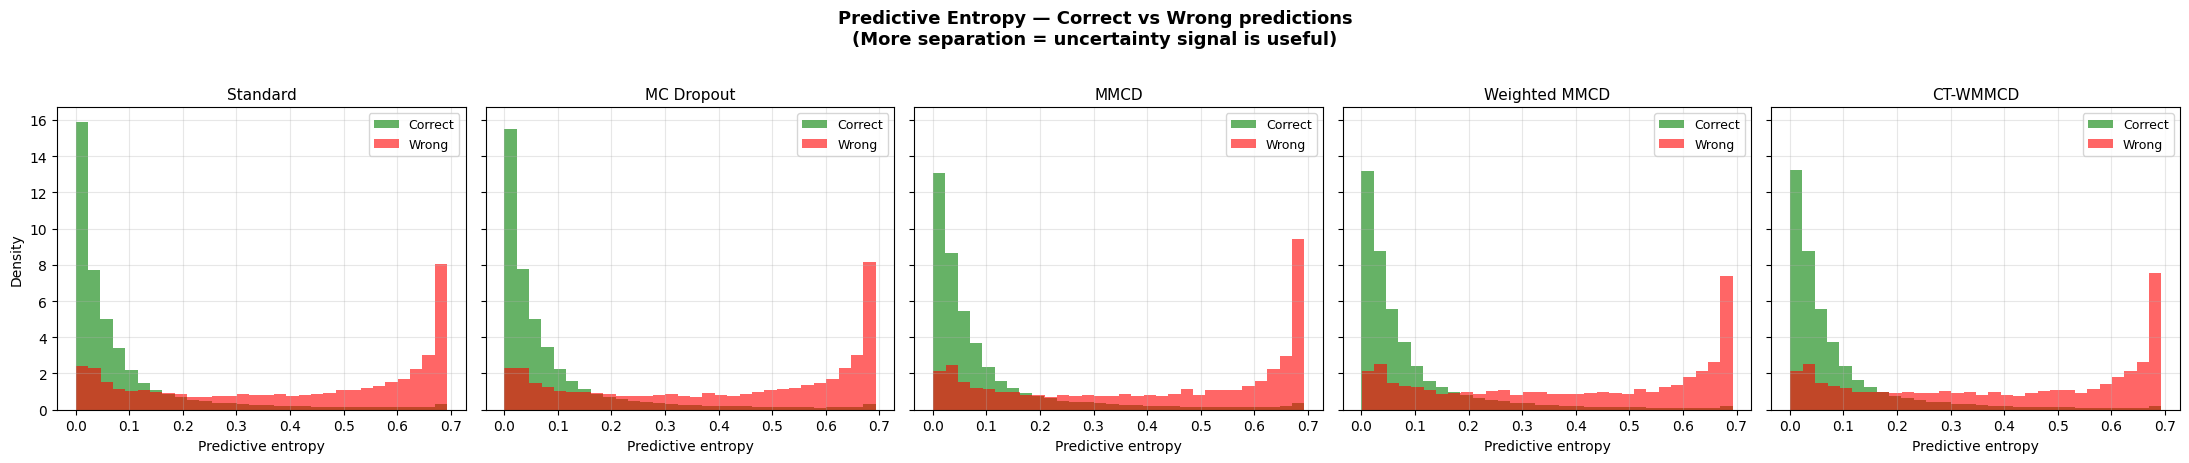

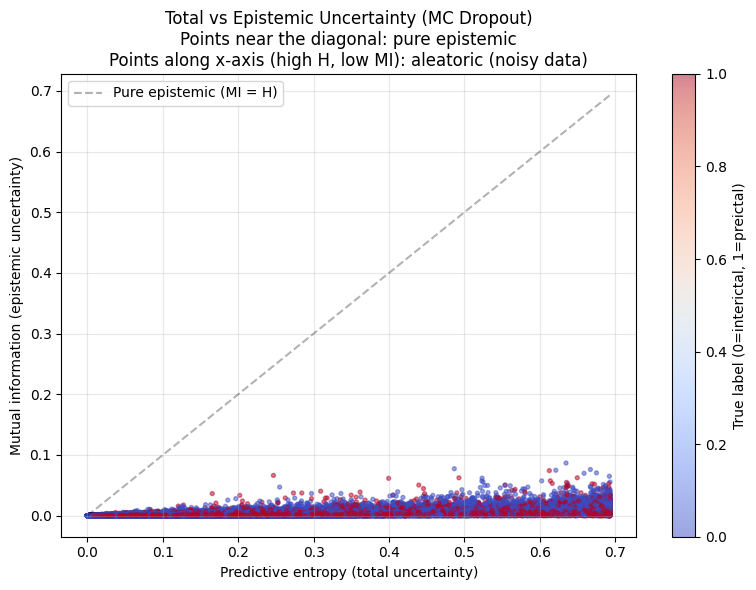


UNCERTAINTY ANALYSIS COMPLETE
Metrics saved to:  /home/dst/Desktop/CHB/results/uncertainty_metrics.json
                   /home/dst/Desktop/CHB/results/uncertainty_overall.json
Figures saved to:  /home/dst/Desktop/CHB/results/figures/


In [26]:
# ============================================================
# CELL 11 (NEW): UNCERTAINTY QUANTIFICATION & CALIBRATION ANALYSIS
# ============================================================
# Adds rigorous uncertainty analysis to strengthen the "uncertainty-aware
# seizure prediction" framing.
#
# What this cell does:
#   1. Re-runs inference on every fold, this time KEEPING the full
#      T-pass MCD output so we can compute mutual information.
#   2. Computes per-fold uncertainty metrics:
#        - Predictive entropy (total uncertainty)
#        - Mutual information / BALD (epistemic uncertainty)
#        - Brier score
#        - Negative log-likelihood
#        - Expected Calibration Error (ECE) at 15 bins
#        - Maximum Calibration Error (MCE)
#        - Error-detection AUC (does entropy predict mistakes?)
#        - Mean entropy on correct vs wrong predictions
#   3. Aggregates per patient and across all patients.
#   4. Plots:
#        - Reliability diagrams for each method
#        - Risk-coverage curves
#        - Entropy distributions split by correctness
#
# Drop this in AFTER Cell 10 (full evaluation) so that the checkpoints
# exist and `usable_patients` is in memory.
# ============================================================

# ----- Defensive imports (in case the kernel was restarted) -----
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score

# ----- Dependency check -----
# These must come from earlier cells in the notebook (Cells 1, 3, 4, 5).
# If anything is missing, this gives a clear message instead of a NameError
# deep inside the loop.

_REQUIRED_OBJECTS = [
    # Constants from Cell 1
    'DEVICE', 'BATCH_SIZE', 'NUM_WORKERS', 'PIN_MEMORY',
    'N_CHANNELS', 'WINDOW_SIZE', 'NUM_CLASSES', 'DROPOUT_RATE',
    'MCD_T', 'MMCD_D', 'CT_WMMCD_TAU', 'CT_WMMCD_LAMBDA',
    'RESULTS_DIR', 'MODELS_DIR', 'USE_PAPER_SUBSET', 'PAPER_EXCLUDED',
    # Functions / classes from Cells 3, 4, 5
    'RepNet',
    'standard_inference', 'mmcd_inference',
    'weighted_mmcd_inference', 'ct_wmmcd_inference',
    'build_loso_fold', 'load_patient_data',
]

_missing = [name for name in _REQUIRED_OBJECTS if name not in globals()]
if _missing:
    raise RuntimeError(
        "This cell depends on objects defined in earlier cells of your "
        "notebook. The following are missing:\n  - "
        + "\n  - ".join(_missing)
        + "\n\nFix: in your notebook, run Cells 1, 3, 4, and 5 first "
        "(they define imports, constants, RepNet, the inference functions, "
        "and build_loso_fold / load_patient_data). You do NOT need to "
        "re-train — your existing checkpoints on disk are fine. Then "
        "re-run this cell."
    )

print(f"All {len(_REQUIRED_OBJECTS)} dependencies found. Running uncertainty "
      "analysis...\n")


# ============================================================
# MODIFIED MCD INFERENCE — returns all T passes, not just the mean
# ============================================================

@torch.no_grad()
def mc_dropout_inference_full(model, loader, device, T=5):
    """Like mc_dropout_inference, but returns ALL T forward passes.

    Needed for mutual information (epistemic uncertainty).

    Returns:
        all_passes : np.ndarray, shape (T, n_samples, n_classes)
        labels     : np.ndarray, shape (n_samples,)
    """
    model.eval()
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
            m.train()

    all_passes = []
    all_labels = None

    for t in range(T):
        probs_t, labels_t = [], []
        for bx, by in loader:
            bx = bx.to(device, non_blocking=True)
            p = F.softmax(model(bx), dim=1)
            probs_t.append(p.cpu().numpy())
            if t == 0:
                labels_t.append(by.numpy())
        all_passes.append(np.concatenate(probs_t))
        if t == 0:
            all_labels = np.concatenate(labels_t)

    return np.stack(all_passes), all_labels


# ============================================================
# CORE UNCERTAINTY METRICS
# ============================================================

def predictive_entropy(probs, eps=1e-12):
    """Total predictive uncertainty per sample.

    H[p] = -sum_c p_c * log(p_c)

    High entropy = model is torn between classes (could be aleatoric
    OR epistemic — mutual information separates them).
    """
    return -np.sum(probs * np.log(probs + eps), axis=1)


def mutual_information(all_passes, eps=1e-12):
    """Epistemic (model) uncertainty — BALD score.

    I[y, w | x] = H[ mean_t(p_t) ]  -  mean_t( H[p_t] )

    Interpretation:
      - High MI: the T dropout samples disagree → model itself is uncertain
        (could be reduced with more training data).
      - High entropy but low MI: model agrees with itself, but the data
        is genuinely ambiguous (aleatoric — irreducible noise).

    Args:
        all_passes: (T, n_samples, n_classes) from mc_dropout_inference_full
    Returns:
        mi: (n_samples,) — should be >= 0 in theory
    """
    mean_probs = all_passes.mean(axis=0)
    H_of_mean = -np.sum(mean_probs * np.log(mean_probs + eps), axis=1)
    H_per_pass = -np.sum(all_passes * np.log(all_passes + eps), axis=2)
    mean_of_H = H_per_pass.mean(axis=0)
    return np.clip(H_of_mean - mean_of_H, 0.0, None)


def brier_score(probs_pos, labels):
    """Brier score: mean squared error between predicted prob and label.

    BS = mean((p - y)^2)

    Lower = better. Combines calibration + sharpness.
    Random predictor on balanced data: 0.25.
    """
    return float(np.mean((probs_pos - labels) ** 2))


def negative_log_likelihood(probs_pos, labels, eps=1e-12):
    """NLL: -log of probability assigned to the correct class.

    Lower = better. Heavily punishes confident wrong predictions
    (which is what we want to detect for clinical safety).
    """
    p_correct = np.where(labels == 1, probs_pos, 1.0 - probs_pos)
    return float(-np.mean(np.log(p_correct + eps)))


def expected_calibration_error(probs_pos, labels, n_bins=15):
    """ECE: weighted gap between confidence and accuracy across bins.

    Bins predictions by confidence = max(p, 1-p).
    For each bin: gap = |mean_confidence - accuracy|.
    Weighted average across bins by bin population.

    A perfectly calibrated model: ECE = 0.
    Modern uncalibrated DNNs: ECE ≈ 0.05–0.20.

    Returns:
        ece       : scalar
        bin_data  : list of dicts (mean_conf, accuracy, count) for plotting
    """
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    n = len(probs_pos)
    confidences = np.maximum(probs_pos, 1.0 - probs_pos)
    predictions = (probs_pos >= 0.5).astype(int)
    correctness = (predictions == labels).astype(float)

    ece = 0.0
    bin_data = []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        if i == n_bins - 1:
            mask = (confidences >= lo) & (confidences <= hi)
        else:
            mask = (confidences >= lo) & (confidences < hi)
        n_in_bin = int(mask.sum())

        if n_in_bin == 0:
            bin_data.append({'lo': lo, 'hi': hi,
                             'mean_conf': 0.0, 'accuracy': 0.0, 'count': 0})
            continue

        mean_conf = float(confidences[mask].mean())
        accuracy = float(correctness[mask].mean())
        ece += (n_in_bin / n) * abs(mean_conf - accuracy)
        bin_data.append({'lo': lo, 'hi': hi,
                         'mean_conf': mean_conf, 'accuracy': accuracy,
                         'count': n_in_bin})

    return float(ece), bin_data


def maximum_calibration_error(bin_data):
    """MCE: largest gap between confidence and accuracy across populated bins."""
    gaps = [abs(b['mean_conf'] - b['accuracy'])
            for b in bin_data if b['count'] > 0]
    return float(max(gaps)) if gaps else 0.0


def uncertainty_vs_correctness(probs_pos, labels, uncertainty):
    """Does uncertainty actually flag wrong predictions?

    Returns:
        mean_unc_correct : average uncertainty on correct predictions
        mean_unc_wrong   : average uncertainty on wrong predictions
        error_detection_auc : AUC for using uncertainty to predict 'was wrong'
                              (> 0.5 means uncertainty correlates with errors)
    """
    predictions = (probs_pos >= 0.5).astype(int)
    correct = predictions == labels
    u_correct = uncertainty[correct]
    u_wrong = uncertainty[~correct]

    error_labels = (~correct).astype(int)
    if len(np.unique(error_labels)) > 1:
        sep_auc = float(roc_auc_score(error_labels, uncertainty))
    else:
        sep_auc = float('nan')

    return {
        'mean_unc_correct': float(u_correct.mean()) if len(u_correct) else 0.0,
        'mean_unc_wrong': float(u_wrong.mean()) if len(u_wrong) else 0.0,
        'error_detection_auc': sep_auc,
    }


# ============================================================
# PER-FOLD UNCERTAINTY EVALUATION
# ============================================================

def evaluate_uncertainty_fold(ckpt_path, fold_data, T=MCD_T):
    """Compute uncertainty metrics for one fold across all 5 methods.

    Also returns raw arrays (probs_pos, labels, entropy, MI) so we can
    aggregate across folds for reliability diagrams and risk-coverage curves.
    """
    model = RepNet(n_channels=N_CHANNELS, n_samples=WINDOW_SIZE,
                   num_classes=NUM_CLASSES,
                   dropout_rate=DROPOUT_RATE).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE,
                                      weights_only=True))

    X_test = torch.from_numpy(fold_data['X_test']).float()
    y_test = torch.from_numpy(fold_data['y_test']).long()
    test_loader = DataLoader(
        TensorDataset(X_test, y_test),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )

    segment_boundaries = fold_data.get('segment_boundaries', None)

    # 1) Standard inference
    probs_std, labels = standard_inference(model, test_loader, DEVICE)

    # 2) MCD with all T passes (needed for mutual information)
    all_passes, _ = mc_dropout_inference_full(model, test_loader, DEVICE, T=T)
    probs_mcd = all_passes.mean(axis=0)
    mi_mcd = mutual_information(all_passes)

    # 3) MMCD variants
    probs_mmcd = mmcd_inference(probs_std, D=MMCD_D,
                                 segment_boundaries=segment_boundaries)
    probs_wmmcd = weighted_mmcd_inference(probs_std, D=MMCD_D,
                                           segment_boundaries=segment_boundaries)
    probs_ctwmmcd = ct_wmmcd_inference(
        probs_std, D=MMCD_D, tau=CT_WMMCD_TAU, lam=CT_WMMCD_LAMBDA,
        segment_boundaries=segment_boundaries)

    methods = {
        'Standard': probs_std,
        'MC Dropout': probs_mcd,
        'MMCD': probs_mmcd,
        'Weighted MMCD': probs_wmmcd,
        'CT-WMMCD': probs_ctwmmcd,
    }

    results = {}
    raw_arrays = {}

    for name, probs in methods.items():
        probs_pos = probs[:, 1]
        ent = predictive_entropy(probs)

        ece, bin_data = expected_calibration_error(probs_pos, labels)
        mce = maximum_calibration_error(bin_data)
        bs = brier_score(probs_pos, labels)
        nll = negative_log_likelihood(probs_pos, labels)
        uvc = uncertainty_vs_correctness(probs_pos, labels, ent)

        results[name] = {
            'mean_entropy': float(ent.mean()),
            'mean_entropy_correct': uvc['mean_unc_correct'],
            'mean_entropy_wrong': uvc['mean_unc_wrong'],
            'error_detection_auc': uvc['error_detection_auc'],
            'brier_score': bs,
            'nll': nll,
            'ece': ece,
            'mce': mce,
        }
        if name == 'MC Dropout':
            results[name]['mean_mutual_information'] = float(mi_mcd.mean())

        raw_arrays[name] = {
            'probs_pos': probs_pos,
            'labels': labels,
            'entropy': ent,
        }

    raw_arrays['MC Dropout']['mutual_information'] = mi_mcd

    del model, X_test, y_test, test_loader
    torch.cuda.empty_cache()
    return results, raw_arrays


# ============================================================
# RUN UNCERTAINTY EVALUATION ACROSS ALL PATIENTS
# ============================================================

def run_uncertainty_evaluation(patient_list):
    """Loop through all folds, collect uncertainty metrics + raw arrays."""
    print("=" * 70)
    print("UNCERTAINTY QUANTIFICATION")
    print("=" * 70)

    per_patient_metrics = {}
    # Pool raw arrays across all folds for global reliability diagrams
    pooled = {m: {'probs_pos': [], 'labels': [], 'entropy': []}
              for m in ['Standard', 'MC Dropout', 'MMCD',
                        'Weighted MMCD', 'CT-WMMCD']}
    pooled['MC Dropout']['mutual_information'] = []

    for patient_id in patient_list:
        print(f"\n--- {patient_id} ---")
        try:
            preictal_dict, interictal_dict, _ = load_patient_data(patient_id)
        except Exception as e:
            print(f"  load failed: {e}")
            continue
        if len(preictal_dict) < 2:
            continue

        fold_metric_list = []
        for sz_key in sorted(preictal_dict.keys()):
            ckpt = os.path.join(MODELS_DIR, 'checkpoints', patient_id,
                                 f'repnet_{sz_key}.pth')
            if not os.path.exists(ckpt):
                continue

            fold_data = build_loso_fold(preictal_dict, interictal_dict, sz_key)
            if fold_data is None:
                continue

            metrics, raws = evaluate_uncertainty_fold(ckpt, fold_data)
            fold_metric_list.append(metrics)

            for m, arr_dict in raws.items():
                pooled[m]['probs_pos'].append(arr_dict['probs_pos'])
                pooled[m]['labels'].append(arr_dict['labels'])
                pooled[m]['entropy'].append(arr_dict['entropy'])
                if m == 'MC Dropout':
                    pooled[m]['mutual_information'].append(
                        arr_dict['mutual_information'])

            del fold_data
            torch.cuda.empty_cache()

        # Average across folds
        if not fold_metric_list:
            continue
        method_names = list(fold_metric_list[0].keys())
        agg = {}
        for m in method_names:
            keys = fold_metric_list[0][m].keys()
            agg[m] = {k: float(np.mean([f[m][k] for f in fold_metric_list
                                         if k in f[m]])) for k in keys}
        per_patient_metrics[patient_id] = agg

        # Print compact summary for this patient
        for m in method_names:
            r = agg[m]
            print(f"  {m:<16} ECE={r['ece']:.3f}  Brier={r['brier_score']:.3f}  "
                  f"NLL={r['nll']:.3f}  ErrDetAUC={r['error_detection_auc']:.3f}")

    # Concatenate pooled arrays for global plots
    for m in pooled:
        for k in list(pooled[m].keys()):
            if pooled[m][k]:
                pooled[m][k] = np.concatenate(pooled[m][k])
            else:
                pooled[m][k] = np.array([])

    # Save per-patient metrics
    out_path = os.path.join(RESULTS_DIR, 'uncertainty_metrics.json')
    with open(out_path, 'w') as f:
        json.dump(per_patient_metrics, f, indent=2)
    print(f"\nPer-patient uncertainty metrics saved to {out_path}")

    return per_patient_metrics, pooled


# ============================================================
# OVERALL UNCERTAINTY SUMMARY TABLE
# ============================================================

def print_uncertainty_summary(per_patient_metrics):
    """Average uncertainty metrics across all patients."""
    print("\n" + "=" * 95)
    print("OVERALL UNCERTAINTY SUMMARY (averaged across patients)")
    print("=" * 95)
    print(f"{'Method':<16}{'ECE':<10}{'MCE':<10}{'Brier':<10}"
          f"{'NLL':<10}{'ErrDetAUC':<12}{'EntCorrect':<12}{'EntWrong':<12}")
    print("-" * 95)

    method_names = ['Standard', 'MC Dropout', 'MMCD',
                    'Weighted MMCD', 'CT-WMMCD']
    overall = {}
    for m in method_names:
        ece = np.mean([p[m]['ece'] for p in per_patient_metrics.values()
                       if m in p])
        mce = np.mean([p[m]['mce'] for p in per_patient_metrics.values()
                       if m in p])
        bs = np.mean([p[m]['brier_score'] for p in per_patient_metrics.values()
                      if m in p])
        nll = np.mean([p[m]['nll'] for p in per_patient_metrics.values()
                       if m in p])
        eda = np.mean([p[m]['error_detection_auc']
                       for p in per_patient_metrics.values() if m in p])
        ec = np.mean([p[m]['mean_entropy_correct']
                      for p in per_patient_metrics.values() if m in p])
        ew = np.mean([p[m]['mean_entropy_wrong']
                      for p in per_patient_metrics.values() if m in p])
        print(f"{m:<16}{ece:<10.4f}{mce:<10.4f}{bs:<10.4f}"
              f"{nll:<10.4f}{eda:<12.4f}{ec:<12.4f}{ew:<12.4f}")
        overall[m] = {'ece': ece, 'mce': mce, 'brier': bs, 'nll': nll,
                      'err_det_auc': eda, 'entropy_correct': ec,
                      'entropy_wrong': ew}
    print("=" * 95)
    return overall


# ============================================================
# PLOT 1: RELIABILITY DIAGRAMS (one per method, all on one figure)
# ============================================================

def plot_reliability_diagrams(pooled, n_bins=15, save_path=None):
    """Reliability diagrams for all 5 methods side by side."""
    method_names = ['Standard', 'MC Dropout', 'MMCD',
                    'Weighted MMCD', 'CT-WMMCD']
    fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

    for ax, m in zip(axes, method_names):
        probs_pos = pooled[m]['probs_pos']
        labels = pooled[m]['labels']
        ece, bin_data = expected_calibration_error(probs_pos, labels, n_bins)

        bin_centers = np.array([(b['lo'] + b['hi']) / 2 for b in bin_data])
        accuracies = np.array([b['accuracy'] for b in bin_data])
        confidences = np.array([b['mean_conf'] for b in bin_data])
        counts = np.array([b['count'] for b in bin_data])

        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
        bar_width = 1.0 / n_bins * 0.9
        # Accuracy bars
        ax.bar(bin_centers, accuracies, width=bar_width,
               color='steelblue', edgecolor='black', alpha=0.75,
               label='Accuracy')
        # Gap (confidence - accuracy) overlay
        gap = confidences - accuracies
        for c, a, g, n in zip(bin_centers, accuracies, gap, counts):
            if n > 0 and g > 0:
                ax.bar(c, g, bottom=a, width=bar_width,
                       color='red', alpha=0.35, edgecolor='black')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel('Confidence')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'{m}\nECE = {ece:.4f}', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left', fontsize=8)

    fig.suptitle('Reliability Diagrams — blue = accuracy, red = miscalibration gap',
                 fontsize=13, fontweight='bold', y=1.02)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# ============================================================
# PLOT 2: RISK-COVERAGE CURVES
# ============================================================

def plot_risk_coverage(pooled, save_path=None):
    """Risk-coverage curves for all methods using predictive entropy."""
    method_names = ['Standard', 'MC Dropout', 'MMCD',
                    'Weighted MMCD', 'CT-WMMCD']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    fig, ax = plt.subplots(figsize=(9, 6))
    for m, color in zip(method_names, colors):
        probs_pos = pooled[m]['probs_pos']
        labels = pooled[m]['labels']
        ent = pooled[m]['entropy']

        predictions = (probs_pos >= 0.5).astype(int)
        errors = (predictions != labels).astype(int)
        order = np.argsort(ent)  # most confident first
        sorted_errors = errors[order]
        n = len(errors)
        coverages = np.arange(1, n + 1) / n
        cumulative_errors = np.cumsum(sorted_errors) / np.arange(1, n + 1)

        ax.plot(coverages, cumulative_errors, color=color, linewidth=2,
                label=f'{m} (full={sorted_errors.mean():.3f})')

    ax.set_xlabel('Coverage (fraction of predictions retained)')
    ax.set_ylabel('Error rate on retained predictions')
    ax.set_title('Risk-Coverage Curves\n'
                 '(Lower curve at low coverage = uncertainty is meaningful)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)
    ax.set_xlim(0.05, 1.0)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# ============================================================
# PLOT 3: ENTROPY DISTRIBUTION — CORRECT vs WRONG
# ============================================================

def plot_entropy_correct_vs_wrong(pooled, save_path=None):
    """Histogram of predictive entropy split by correctness."""
    method_names = ['Standard', 'MC Dropout', 'MMCD',
                    'Weighted MMCD', 'CT-WMMCD']
    fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), sharey=True)

    for ax, m in zip(axes, method_names):
        probs_pos = pooled[m]['probs_pos']
        labels = pooled[m]['labels']
        ent = pooled[m]['entropy']
        predictions = (probs_pos >= 0.5).astype(int)
        correct = predictions == labels

        ax.hist(ent[correct], bins=30, alpha=0.6, label='Correct',
                color='green', density=True)
        ax.hist(ent[~correct], bins=30, alpha=0.6, label='Wrong',
                color='red', density=True)
        ax.set_xlabel('Predictive entropy')
        ax.set_title(m, fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
    axes[0].set_ylabel('Density')

    fig.suptitle('Predictive Entropy — Correct vs Wrong predictions\n'
                 '(More separation = uncertainty signal is useful)',
                 fontsize=13, fontweight='bold', y=1.02)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# ============================================================
# PLOT 4: ALEATORIC vs EPISTEMIC (MCD only)
# ============================================================

def plot_aleatoric_vs_epistemic(pooled, save_path=None):
    """Scatter of total entropy vs mutual information (MCD only).

    Reveals which test predictions are uncertain because of data noise
    (aleatoric) vs because of model itself (epistemic).
    """
    ent = pooled['MC Dropout']['entropy']
    mi = pooled['MC Dropout']['mutual_information']
    labels = pooled['MC Dropout']['labels']

    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(ent, mi, c=labels, cmap='coolwarm', s=8, alpha=0.5)
    ax.set_xlabel('Predictive entropy (total uncertainty)')
    ax.set_ylabel('Mutual information (epistemic uncertainty)')
    ax.set_title('Total vs Epistemic Uncertainty (MC Dropout)\n'
                 'Points near the diagonal: pure epistemic\n'
                 'Points along x-axis (high H, low MI): aleatoric (noisy data)')
    ax.plot([0, ent.max()], [0, ent.max()], 'k--', alpha=0.3,
            label='Pure epistemic (MI = H)')
    plt.colorbar(sc, ax=ax, label='True label (0=interictal, 1=preictal)')
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# ============================================================
# RUN EVERYTHING
# ============================================================

with open(os.path.join(RESULTS_DIR, 'usable_patients.json'), 'r') as f:
    usable_patients = json.load(f)['patients']

# Match Cell 10's filtering
if USE_PAPER_SUBSET:
    usable_patients = [p for p in usable_patients if p not in PAPER_EXCLUDED]
for skip in ['chb02']:
    if skip in usable_patients:
        usable_patients.remove(skip)

print(f"Running uncertainty analysis on {len(usable_patients)} patients\n")

per_patient_unc, pooled = run_uncertainty_evaluation(usable_patients)
overall_unc = print_uncertainty_summary(per_patient_unc)

# Save overall summary
with open(os.path.join(RESULTS_DIR, 'uncertainty_overall.json'), 'w') as f:
    json.dump(overall_unc, f, indent=2)

# Plots
fig_dir = os.path.join(RESULTS_DIR, 'figures')
plot_reliability_diagrams(
    pooled, save_path=os.path.join(fig_dir, 'reliability_diagrams.png'))
plot_risk_coverage(
    pooled, save_path=os.path.join(fig_dir, 'risk_coverage.png'))
plot_entropy_correct_vs_wrong(
    pooled, save_path=os.path.join(fig_dir, 'entropy_correct_vs_wrong.png'))
plot_aleatoric_vs_epistemic(
    pooled, save_path=os.path.join(fig_dir, 'aleatoric_vs_epistemic.png'))

print("\n" + "=" * 70)
print("UNCERTAINTY ANALYSIS COMPLETE")
print(f"Metrics saved to:  {RESULTS_DIR}/uncertainty_metrics.json")
print(f"                   {RESULTS_DIR}/uncertainty_overall.json")
print(f"Figures saved to:  {fig_dir}/")
print("=" * 70)